<a href="https://colab.research.google.com/github/Tapiwanashe6/mobile-network-traffic-forecasting/blob/main/formative_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparative Analysis of Sequential Models for Mobile Network Traffic Forecasting

## 1. Study Overview

### Research Question

**How do different sequential models compare for one-step-ahead mobile network traffic forecasting, and how does their performance vary across geographical areas with different traffic characteristics?**

This study investigates short-term Internet-traffic forecasting using the Telecom Italia Milan dataset at its original **10-minute temporal resolution**. The analysis compares three complementary forecasting approaches:

1. **Fourier-seasonal ARIMA** — a statistical approach combining low-order ARIMA dynamics with Fourier terms representing daily seasonality.
2. **Long Short-Term Memory (LSTM)** — a recurrent neural network for learning nonlinear sequential dependencies.
3. **Transformer** — an attention-based neural architecture for learning relationships across a historical traffic window.

A **persistence forecast** is included as a baseline to determine whether each model improves on simply using the most recent observed traffic value.

### Experimental Principle

All approaches are evaluated using the same geographical areas, chronological data partitions, 10-minute resolution, one-step-ahead horizon, and evaluation metrics. Model architectures and hyperparameters are selected using the training and validation periods only. The held-out test targets are not used for model fitting or hyperparameter selection and are evaluated only after the final configurations are frozen.

An explicit seasonal SARIMA model with a 144-step daily seasonal period was initially investigated. Because the full seasonal state-space formulation exceeded the available runtime memory at the original resolution, the statistical approach was adapted to use Fourier terms for daily seasonality with a low-order ARIMA component. This preserves the original forecasting task rather than changing the data frequency.

In [ ]:
# ============================================================
# 1. EXPERIMENT SETUP AND REPRODUCIBILITY
# ============================================================

import os
import gc
import time
import random
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore")

print("Python version:", platform.python_version())
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Random seed:", SEED)

print("\nEnvironment:")
print(platform.platform())

Python version: 3.13.15
Pandas version: 2.2.3
NumPy version: 2.1.3
Random seed: 42

Environment:
Linux-6.6.122+-x86_64-with-glibc2.39


## 2. Dataset Acquisition and Initial Inspection

The experiments use the Telecom Italia mobile telecommunications dataset for Milan. The available data are distributed across daily tab-separated text files containing geographical grid identifiers, timestamps, country codes, and telecommunications activity measures.

Because a single daily file contains several million raw records, loading all files simultaneously with default Pandas data types would be unnecessarily memory intensive. A staged processing strategy is therefore used: the workflow first identifies the available daily files and inspects their raw structure, then measures the memory cost of one representative file before introducing an optimized loading and aggregation procedure.

The forecasting target is **Internet activity**. Multiple raw records may correspond to the same geographical square and timestamp because activity is reported by country code. These records are therefore aggregated later to obtain one Internet-traffic value per geographical square and 10-minute timestamp.

This staged inspection provides empirical justification for the memory-management decisions used throughout the analysis.

In [ ]:
# ============================================================
# 2. DATASET ACQUISITION
# ============================================================

import kagglehub
from pathlib import Path

dataset_path = kagglehub.dataset_download(
    "arsenekabasinga/milan-telecom-traffic-2013"
)

DATASET_PATH = Path(dataset_path)

print("Dataset location:")
print(DATASET_PATH)

# Find all TXT files recursively
data_files = sorted(DATASET_PATH.rglob("*.txt"))

print("\nNumber of TXT files:", len(data_files))

print("\nFirst 5 files:")
for file in data_files[:5]:
    print(file.name)

print("\nLast 5 files:")
for file in data_files[-5:]:
    print(file.name)

Using Colab cache for faster access to the 'milan-telecom-traffic-2013' dataset.
Dataset location:
/kaggle/input/milan-telecom-traffic-2013

Number of TXT files: 62

First 5 files:
sms-call-internet-mi-2013-11-01.txt
sms-call-internet-mi-2013-11-02.txt
sms-call-internet-mi-2013-11-03.txt
sms-call-internet-mi-2013-11-04.txt
sms-call-internet-mi-2013-11-05.txt

Last 5 files:
sms-call-internet-mi-2013-12-28.txt
sms-call-internet-mi-2013-12-29.txt
sms-call-internet-mi-2013-12-30.txt
sms-call-internet-mi-2013-12-31.txt
sms-call-internet-mi-2014-01-01.txt


In [ ]:
# ============================================================
# 2.1 INSPECT RAW FILE STRUCTURE
# ============================================================

sample_file = data_files[0]

print("Sample file:", sample_file.name)
print("\nFirst 5 raw rows:\n")

with open(sample_file, "r") as f:
    for _ in range(5):
        print(f.readline().strip())

Sample file: sms-call-internet-mi-2013-11-01.txt

First 5 raw rows:

1	1383260400000	0	0.08136262351125882
1	1383260400000	39	0.14186425470242922	0.1567870050390246	0.16093793691701822	0.052274848528573205	11.028366381681026
1	1383261000000	0	0.13658782275823106			0.02730046487718618
1	1383261000000	33					0.026137424264286602
1	1383261000000	39	0.27845207746066025	0.11992572014174135	0.1887771729145041	0.13363747203983203	11.100963451409388


### 2.2 Baseline Memory and Loading Cost

Before applying memory optimizations, one complete daily file is loaded using Pandas' default numeric data types. Its loading time, dimensions, inferred data types, missing values, and memory consumption are measured.

This baseline provides a quantitative reference for evaluating the effectiveness of the optimized loading strategy developed in the next stage.

In [ ]:
# ============================================================
# 2.2 UNOPTIMIZED BASELINE LOAD
# ============================================================

column_names = [
    "square_id",
    "timestamp",
    "country_code",
    "sms_in",
    "sms_out",
    "call_in",
    "call_out",
    "internet"
]

start_time = time.perf_counter()

df_baseline = pd.read_csv(
    sample_file,
    sep="\t",
    names=column_names
)

baseline_load_time = time.perf_counter() - start_time

baseline_memory_mb = (
    df_baseline.memory_usage(deep=True).sum()
    / 1024**2
)

print("UNOPTIMIZED DAILY FILE")
print("=" * 50)

print(f"File: {sample_file.name}")
print(f"Shape: {df_baseline.shape}")
print(f"Load time: {baseline_load_time:.2f} seconds")
print(f"Memory usage: {baseline_memory_mb:.2f} MB")

print("\nData types:")
print(df_baseline.dtypes)

print("\nMissing values:")
print(df_baseline.isna().sum())

print("\nFirst 5 rows:")
display(df_baseline.head())

UNOPTIMIZED DAILY FILE
File: sms-call-internet-mi-2013-11-01.txt
Shape: (4842625, 8)
Load time: 4.90 seconds
Memory usage: 295.57 MB

Data types:
square_id         int64
timestamp         int64
country_code      int64
sms_in          float64
sms_out         float64
call_in         float64
call_out        float64
internet        float64
dtype: object

Missing values:
square_id             0
timestamp             0
country_code          0
sms_in          1981177
sms_out         3210070
call_in         3329423
call_out        2611016
internet        2488626
dtype: int64

First 5 rows:


,square_id,timestamp,country_code,sms_in,sms_out,call_in,call_out,internet
0,1,1383260400000,0,0.081363,NaN,NaN,NaN,NaN
1,1,1383260400000,39,0.141864,0.156787,0.160938,0.052275,11.028366
2,1,1383261000000,0,0.136588,NaN,NaN,0.027300,NaN
3,1,1383261000000,33,NaN,NaN,NaN,NaN,0.026137
4,1,1383261000000,39,0.278452,0.119926,0.188777,0.133637,11.100963


### 2.3 Memory Optimization

The forecasting target is **Internet activity**, so SMS and call variables are not required for the forecasting experiments. Only `square_id`, `timestamp`, `country_code`, and `internet` are loaded from each raw file.

Memory usage is further reduced by assigning narrower numeric data types based on the observed ranges of the variables. `square_id` and `country_code` are stored as 16-bit integers, `internet` as a 32-bit floating-point value, while the millisecond Unix timestamp remains a 64-bit integer.

The country-code dimension is retained during loading because multiple country-level records can correspond to the same geographical square and timestamp. These records are subsequently aggregated by summing Internet activity across country codes, producing the geographical time series required for forecasting.

This optimization reduces memory consumption before the complete collection of daily files is processed while preserving the information required for the forecasting task.

In [ ]:
# ============================================================
# 2.3 OPTIMIZED DAILY LOAD
# ============================================================

required_columns = [
    "square_id",
    "timestamp",
    "country_code",
    "internet"
]

optimized_dtypes = {
    "square_id": "int16",
    "timestamp": "int64",
    "country_code": "int16",
    "internet": "float32"
}

start_time = time.perf_counter()

df_optimized = pd.read_csv(
    sample_file,
    sep="\t",
    names=column_names,
    usecols=required_columns,
    dtype=optimized_dtypes
)

optimized_load_time = time.perf_counter() - start_time

optimized_memory_mb = (
    df_optimized.memory_usage(deep=True).sum()
    / 1024**2
)

memory_reduction = (
    (baseline_memory_mb - optimized_memory_mb)
    / baseline_memory_mb
) * 100

print("OPTIMIZED DAILY FILE")
print("=" * 50)

print(f"Shape: {df_optimized.shape}")
print(f"Load time: {optimized_load_time:.2f} seconds")
print(f"Memory usage: {optimized_memory_mb:.2f} MB")
print(f"Memory reduction: {memory_reduction:.2f}%")

print("\nData types:")
print(df_optimized.dtypes)

print("\nValue ranges:")
print(
    df_optimized[
        ["square_id", "country_code", "internet"]
    ].agg(["min", "max"])
)

OPTIMIZED DAILY FILE
Shape: (4842625, 4)
Load time: 3.24 seconds
Memory usage: 73.89 MB
Memory reduction: 75.00%

Data types:
square_id         int16
timestamp         int64
country_code      int16
internet        float32
dtype: object

Value ranges:
     square_id  country_code     internet
min          1             0     0.000002
max      10000         31723  4995.604980


### 2.4 Aggregation to Geographical Time Series

The raw dataset may contain several country-code records for the same geographical square and 10-minute timestamp. Since the research question concerns traffic forecasting at the geographical-area level rather than country-code-specific activity, Internet activity is summed across country codes for each `(square_id, timestamp)` pair.

The aggregation uses `sum(min_count=1)`, ensuring that a group containing only missing Internet measurements remains missing rather than being incorrectly represented as zero traffic.

After aggregation, each row represents one geographical grid square at one 10-minute timestamp. Duplicate square/timestamp pairs and remaining missing values are checked explicitly before processing the complete dataset.

In [ ]:
# ============================================================
# 2.4 AGGREGATE COUNTRY-LEVEL INTERNET ACTIVITY
# ============================================================

start_time = time.perf_counter()

df_daily = (
    df_optimized
    .groupby(
        ["square_id", "timestamp"],
        as_index=False
    )["internet"]
    .sum(min_count=1)
)

aggregation_time = (
    time.perf_counter() - start_time
)

aggregated_memory_mb = (
    df_daily.memory_usage(deep=True).sum()
    / 1024**2
)

total_memory_reduction = (
    (baseline_memory_mb - aggregated_memory_mb)
    / baseline_memory_mb
) * 100

print("AGGREGATED DAILY DATA")
print("=" * 50)

print(f"Shape: {df_daily.shape}")
print(
    f"Aggregation time: "
    f"{aggregation_time:.2f} seconds"
)
print(
    f"Memory usage: "
    f"{aggregated_memory_mb:.2f} MB"
)
print(
    f"Reduction from baseline: "
    f"{total_memory_reduction:.2f}%"
)

print(
    "\nDuplicate square/timestamp pairs:",
    df_daily.duplicated(
        ["square_id", "timestamp"]
    ).sum()
)

print(
    "Missing aggregated Internet values:",
    df_daily["internet"].isna().sum()
)

display(df_daily.head())

AGGREGATED DAILY DATA
Shape: (1439982, 3)
Aggregation time: 0.50 seconds
Memory usage: 19.23 MB
Reduction from baseline: 93.50%

Duplicate square/timestamp pairs: 0
Missing aggregated Internet values: 36


,square_id,timestamp,internet
0,1,1383260400000,11.028366
1,1,1383261000000,11.127101
2,1,1383261600000,10.892771
3,1,1383262200000,8.622424
4,1,1383262800000,8.009928


### 2.5 Missing-Value Investigation

Aggregation produced a small number of missing Internet observations. These values are retained initially rather than automatically replaced with zero because a missing measurement does not necessarily represent zero network activity.

Before selecting an imputation strategy, the temporal distribution of missing observations is examined to determine whether they occur as isolated gaps or consecutive missing periods.

In [ ]:
# ============================================================
# 2.5 INVESTIGATE MISSING AGGREGATED VALUES
# ============================================================

missing_daily = df_daily[df_daily["internet"].isna()].copy()

# Convert timestamps for interpretation
missing_daily["datetime_utc"] = pd.to_datetime(
    missing_daily["timestamp"],
    unit="ms",
    utc=True
)

print("Number of missing aggregated observations:")
print(len(missing_daily))

print("\nNumber of affected geographical areas:")
print(missing_daily["square_id"].nunique())

print("\nMissing observations per affected area:")
print(
    missing_daily["square_id"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\nMissing observations:")
display(
    missing_daily[
        ["square_id", "datetime_utc", "internet"]
    ].sort_values(
        ["square_id", "datetime_utc"]
    )
)

Number of missing aggregated observations:
36

Number of affected geographical areas:
3

Missing observations per affected area:
square_id
5239    34
7623     1
7722     1
Name: count, dtype: int64

Missing observations:


,square_id,datetime_utc,internet
754273,5239,2013-10-31 23:10:00+00:00,NaN
754276,5239,2013-10-31 23:40:00+00:00,NaN
754279,5239,2013-11-01 00:10:00+00:00,NaN
754282,5239,2013-11-01 00:40:00+00:00,NaN
754297,5239,2013-11-01 04:10:00+00:00,NaN
754306,5239,2013-11-01 06:10:00+00:00,NaN
754309,5239,2013-11-01 06:40:00+00:00,NaN
754312,5239,2013-11-01 07:10:00+00:00,NaN
754315,5239,2013-11-01 07:40:00+00:00,NaN
754318,5239,2013-11-01 08:10:00+00:00,NaN


### 2.6 Memory-Efficient Processing of the Complete Dataset

Loading all raw daily files simultaneously would require several gigabytes of memory. Therefore, the complete dataset is processed incrementally.

For each daily file:

1. Only `square_id`, `timestamp`, and `internet` are loaded.
2. Memory-efficient numeric data types are used.
3. Country-level Internet records are aggregated immediately to one observation per geographical square and timestamp.
4. The larger raw daily DataFrame is deleted before processing the next file.
5. The smaller aggregated daily results are concatenated only after all files have been processed.

This approach keeps peak memory usage substantially below that of loading the complete raw dataset at once.

In [ ]:
# ============================================================
# 2.6 MEMORY-EFFICIENT FULL DATASET PROCESSING
# ============================================================

daily_frames = []

full_start_time = time.perf_counter()

for i, file in enumerate(data_files, start=1):

    # Load only variables needed for Internet forecasting
    daily_raw = pd.read_csv(
        file,
        sep="\t",
        names=column_names,
        usecols=["square_id", "timestamp", "internet"],
        dtype={
            "square_id": "int16",
            "timestamp": "int64",
            "internet": "float32"
        }
    )

    # Aggregate country-level records
    daily_aggregated = (
        daily_raw
        .groupby(
            ["square_id", "timestamp"],
            as_index=False
        )["internet"]
        .sum(min_count=1)
    )

    daily_frames.append(daily_aggregated)

    # Remove the much larger raw dataframe
    del daily_raw
    gc.collect()

    if i == 1 or i % 10 == 0 or i == len(data_files):
        print(
            f"Processed {i:>2}/{len(data_files)} files "
            f"({file.name})"
        )

# Combine already-aggregated daily files
df_full = pd.concat(
    daily_frames,
    ignore_index=True
)

del daily_frames
gc.collect()

# Defensive aggregation in case file boundaries overlap
df_full = (
    df_full
    .groupby(
        ["square_id", "timestamp"],
        as_index=False
    )["internet"]
    .sum(min_count=1)
)

full_processing_time = (
    time.perf_counter() - full_start_time
)

full_memory_mb = (
    df_full.memory_usage(deep=True).sum()
    / 1024**2
)

print("\n" + "=" * 55)
print("COMPLETE AGGREGATED DATASET")
print("=" * 55)

print(f"Shape: {df_full.shape}")
print(
    f"Processing time: "
    f"{full_processing_time:.2f} seconds"
)
print(
    f"Memory usage: "
    f"{full_memory_mb:.2f} MB"
)

print(
    "Unique geographical areas:",
    df_full["square_id"].nunique()
)

print(
    "Unique timestamps:",
    df_full["timestamp"].nunique()
)

print(
    "Duplicate square/timestamp pairs:",
    df_full.duplicated(
        ["square_id", "timestamp"]
    ).sum()
)

print(
    "Missing Internet observations:",
    df_full["internet"].isna().sum()
)

print("\nData types:")
print(df_full.dtypes)

Processed  1/62 files (sms-call-internet-mi-2013-11-01.txt)
Processed 10/62 files (sms-call-internet-mi-2013-11-10.txt)
Processed 20/62 files (sms-call-internet-mi-2013-11-20.txt)
Processed 30/62 files (sms-call-internet-mi-2013-11-30.txt)
Processed 40/62 files (sms-call-internet-mi-2013-12-10.txt)
Processed 50/62 files (sms-call-internet-mi-2013-12-20.txt)
Processed 60/62 files (sms-call-internet-mi-2013-12-30.txt)
Processed 62/62 files (sms-call-internet-mi-2014-01-01.txt)

COMPLETE AGGREGATED DATASET
Shape: (89245318, 3)
Processing time: 340.64 seconds
Memory usage: 1191.55 MB
Unique geographical areas: 10000
Unique timestamps: 8928
Duplicate square/timestamp pairs: 0
Missing Internet observations: 117845

Data types:
square_id      int16
timestamp      int64
internet     float32
dtype: object


### 2.7 Temporal Validation

The raw timestamps are stored as Unix timestamps in milliseconds. They are first interpreted in UTC and then converted to the `Europe/Rome` timezone so that temporal patterns such as morning, afternoon, and evening network activity correspond to local Milan time.

The temporal coverage and spacing between observations are examined before missing-value treatment or time-series modeling. This verifies the effective sampling frequency and identifies any irregularities in the temporal grid.

In [ ]:
# ============================================================
# 2.7 TIMESTAMP AND TEMPORAL COVERAGE VALIDATION
# ============================================================

df_full["datetime"] = (
    pd.to_datetime(
        df_full["timestamp"],
        unit="ms",
        utc=True
    )
    .dt.tz_convert("Europe/Rome")
)

unique_times = (
    df_full["datetime"]
    .drop_duplicates()
    .sort_values()
)

time_differences = (
    unique_times
    .diff()
    .dropna()
)

print("TEMPORAL VALIDATION")
print("=" * 55)

print("First local timestamp:")
print(unique_times.iloc[0])

print("\nLast local timestamp:")
print(unique_times.iloc[-1])

print("\nNumber of unique timestamps:")
print(len(unique_times))

print("\nMost common time intervals:")
print(
    time_differences
    .value_counts()
    .head(10)
)

print("\nMinimum interval:")
print(time_differences.min())

print("\nMaximum interval:")
print(time_differences.max())

TEMPORAL VALIDATION
First local timestamp:
2013-11-01 00:00:00+01:00

Last local timestamp:
2014-01-01 23:50:00+01:00

Number of unique timestamps:
8928

Most common time intervals:
datetime
0 days 00:10:00    8927
Name: count, dtype: int64

Minimum interval:
0 days 00:10:00

Maximum interval:
0 days 00:10:00


### 2.8 Spatial-Temporal Coverage

Although the global timestamp sequence is continuous at 10-minute intervals, this does not guarantee that every geographical area contains an observation at every expected timestamp.

Coverage is therefore evaluated separately for each geographical square. The number of recorded timestamps is compared with the 8,928 timestamps expected over the complete observation period.

This distinguishes two forms of missingness:

1. an existing square–timestamp observation whose Internet value is missing; and
2. an expected square–timestamp observation that is entirely absent from the dataset.

In [ ]:
# ============================================================
# 2.8 CHECK TEMPORAL COVERAGE OF EACH GEOGRAPHICAL AREA
# ============================================================

expected_observations = len(unique_times)

coverage_by_area = (
    df_full
    .groupby("square_id")
    .agg(
        recorded_observations=("timestamp", "size"),
        missing_internet=("internet", lambda x: x.isna().sum())
    )
)

coverage_by_area["absent_timestamps"] = (
    expected_observations
    - coverage_by_area["recorded_observations"]
)

coverage_by_area["total_unavailable"] = (
    coverage_by_area["absent_timestamps"]
    + coverage_by_area["missing_internet"]
)

coverage_by_area["coverage_percent"] = (
    coverage_by_area["recorded_observations"]
    / expected_observations
    * 100
)

print("SPATIAL-TEMPORAL COVERAGE")
print("=" * 55)

print("Expected observations per area:")
print(expected_observations)

print("\nAreas with complete timestamp coverage:")
print(
    (coverage_by_area["absent_timestamps"] == 0).sum()
)

print("\nAreas with at least one absent timestamp:")
print(
    (coverage_by_area["absent_timestamps"] > 0).sum()
)

print("\nTotal completely absent square/timestamp observations:")
print(
    coverage_by_area["absent_timestamps"].sum()
)

print("\nAreas containing NaN Internet values:")
print(
    (coverage_by_area["missing_internet"] > 0).sum()
)

print("\nTotal existing rows with NaN Internet:")
print(
    coverage_by_area["missing_internet"].sum()
)

print("\nCoverage summary:")
display(
    coverage_by_area[
        [
            "recorded_observations",
            "absent_timestamps",
            "missing_internet",
            "total_unavailable",
            "coverage_percent"
        ]
    ].describe()
)

print("\n10 areas with the most unavailable observations:")
display(
    coverage_by_area
    .sort_values(
        "total_unavailable",
        ascending=False
    )
    .head(10)
)

SPATIAL-TEMPORAL COVERAGE
Expected observations per area:
8928

Areas with complete timestamp coverage:
9906

Areas with at least one absent timestamp:
94

Total completely absent square/timestamp observations:
34682

Areas containing NaN Internet values:
87

Total existing rows with NaN Internet:
117845

Coverage summary:


,recorded_observations,absent_timestamps,missing_internet,total_unavailable,coverage_percent
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,8924.531800,3.468200,11.784500,15.252700,99.961154
std,90.843811,90.843811,183.384655,237.993102,1.017516
min,2883.000000,0.000000,0.000000,0.000000,32.291667
25%,8928.000000,0.000000,0.000000,0.000000,100.000000
50%,8928.000000,0.000000,0.000000,0.000000,100.000000
75%,8928.000000,0.000000,0.000000,0.000000,100.000000
max,8928.000000,6045.000000,4197.000000,8186.000000,100.000000



10 areas with the most unavailable observations:


,recorded_observations,missing_internet,absent_timestamps,total_unavailable,coverage_percent
square_id,,,,,
5239,2883,2141,6045,8186,32.291667
5339,3752,410,5176,5586,42.025090
4574,8176,4032,752,4784,91.577061
5340,7755,3371,1173,4544,86.861559
5439,6861,2477,2067,4544,76.848118
5440,6861,2477,2067,4544,76.848118
4471,8277,3754,651,4405,92.708333
4472,8720,4197,208,4405,97.670251
4570,8563,3989,365,4354,95.911738


### 2.9 Missingness Severity and Area Eligibility

The coverage analysis shows that missingness is not uniformly distributed across Milan. Most geographical areas have complete or nearly complete records, while a small number contain substantial gaps.

Large gaps should not be reconstructed automatically through interpolation because doing so could introduce artificial temporal patterns into the forecasting experiment.

Missingness is therefore quantified at the geographical-area level before selecting the areas used for forecasting. Areas with complete observations can be prioritized for the main comparative experiment, while highly incomplete areas are retained as evidence of data-quality limitations rather than artificially reconstructed.

In [ ]:
# ============================================================
# 2.9 QUANTIFY MISSINGNESS SEVERITY BY AREA
# ============================================================

coverage_by_area["available_internet"] = (
    expected_observations
    - coverage_by_area["total_unavailable"]
)

coverage_by_area["usable_percent"] = (
    coverage_by_area["available_internet"]
    / expected_observations
    * 100
)

thresholds = [100, 99.9, 99, 95, 90, 75, 50]

print("AREA USABILITY")
print("=" * 55)

for threshold in thresholds:
    count = (
        coverage_by_area["usable_percent"]
        >= threshold
    ).sum()

    print(
        f"Areas with >= {threshold}% usable data: "
        f"{count}"
    )

print("\nAreas with completely observed Internet series:")
print(
    (coverage_by_area["total_unavailable"] == 0)
    .sum()
)

print("\nAreas with any unavailable Internet observation:")
print(
    (coverage_by_area["total_unavailable"] > 0)
    .sum()
)

print("\nOverall unavailable observations:")
total_possible = (
    len(coverage_by_area)
    * expected_observations
)

total_unavailable = (
    coverage_by_area["total_unavailable"].sum()
)

print(f"Possible area-time observations: {total_possible:,}")
print(f"Unavailable observations: {total_unavailable:,}")

print(
    f"Overall unavailable percentage: "
    f"{total_unavailable / total_possible * 100:.4f}%"
)

AREA USABILITY
Areas with >= 100% usable data: 9902
Areas with >= 99.9% usable data: 9914
Areas with >= 99% usable data: 9935
Areas with >= 95% usable data: 9944
Areas with >= 90% usable data: 9955
Areas with >= 75% usable data: 9972
Areas with >= 50% usable data: 9994

Areas with completely observed Internet series:
9902

Areas with any unavailable Internet observation:
98

Overall unavailable observations:
Possible area-time observations: 89,280,000
Unavailable observations: 152,527
Overall unavailable percentage: 0.1708%


## 3. Exploratory Data Analysis

### 3.1 Spatial Variation in Internet Traffic

Mobile network activity may vary substantially across geographical areas because different parts of a city can represent different residential, commercial, transport, or high-activity zones.

To characterize this spatial heterogeneity, descriptive traffic statistics are calculated independently for all 10,000 geographical squares.

The analysis considers both traffic magnitude and variability. These characteristics will later provide an evidence-based basis for selecting contrasting geographical areas for the forecasting experiments rather than selecting locations arbitrarily.

In [ ]:
# ============================================================
# 3.1 TRAFFIC CHARACTERISTICS BY GEOGRAPHICAL AREA
# ============================================================

traffic_by_area = (
    df_full
    .groupby("square_id")["internet"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        total="sum"
    )
)

traffic_by_area["cv"] = (
    traffic_by_area["std"]
    / traffic_by_area["mean"]
)

print("TRAFFIC CHARACTERISTICS ACROSS MILAN")
print("=" * 60)

print("\nSummary across the 10,000 geographical areas:")
display(
    traffic_by_area[
        ["mean", "median", "std", "max", "total", "cv"]
    ].describe()
)

print("\n10 areas with highest total Internet traffic:")
display(
    traffic_by_area
    .sort_values("total", ascending=False)
    .head(10)
)

print("\n10 areas with highest average Internet traffic:")
display(
    traffic_by_area
    .sort_values("mean", ascending=False)
    .head(10)
)

TRAFFIC CHARACTERISTICS ACROSS MILAN

Summary across the 10,000 geographical areas:


,mean,median,std,max,total,cv
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000
mean,62.245468,56.854488,30.753147,280.458130,5.552894e+05,0.474858
std,99.967758,89.785957,61.780605,424.548157,8.925966e+05,0.226070
min,0.206824,0.036037,0.111981,1.150366,2.136265e+02,0.194835
25%,13.278105,12.028482,5.504689,67.898903,1.181020e+05,0.334551
50%,31.156716,27.912495,13.447599,142.201057,2.778711e+05,0.394980
75%,64.809929,59.234943,28.857200,312.527542,5.778956e+05,0.541451
max,1426.978027,975.846069,1381.649170,8044.070312,1.274006e+07,3.476846



10 areas with highest total Internet traffic:


,count,mean,median,std,min,max,total,cv
square_id,,,,,,,,
5161,8928,1426.978027,859.450500,1381.649170,55.795033,8044.070312,12740060.0,0.968234
5059,8928,1251.215698,901.207275,961.472168,108.986801,4666.120605,11170854.0,0.768430
5259,8928,1174.482544,653.836975,1102.825073,72.541618,4442.096191,10485780.0,0.938988
5061,8928,1073.514160,808.525330,786.607910,129.525986,5919.133789,9584334.0,0.732741
5258,8928,975.295715,641.751038,819.110168,88.378189,3840.058350,8707440.0,0.839858
5159,8928,974.896179,559.026855,892.781189,65.398376,5905.818359,8703873.0,0.915771
6064,8928,971.700623,746.550659,674.959961,166.149399,3469.492676,8675343.0,0.694617
4855,8928,951.057800,874.648926,501.567963,186.911011,2885.790039,8491044.0,0.527379
4856,8928,921.842712,905.401245,459.438873,153.964249,2377.791504,8230212.0,0.498392



10 areas with highest average Internet traffic:


,count,mean,median,std,min,max,total,cv
square_id,,,,,,,,
5161,8928,1426.978027,859.450500,1381.649170,55.795033,8044.070312,12740060.0,0.968234
5059,8928,1251.215698,901.207275,961.472168,108.986801,4666.120605,11170854.0,0.768430
5259,8928,1174.482544,653.836975,1102.825073,72.541618,4442.096191,10485780.0,0.938988
5061,8928,1073.514160,808.525330,786.607910,129.525986,5919.133789,9584334.0,0.732741
5258,8928,975.295715,641.751038,819.110168,88.378189,3840.058350,8707440.0,0.839858
5159,8928,974.896179,559.026855,892.781189,65.398376,5905.818359,8703873.0,0.915771
6064,8928,971.700623,746.550659,674.959961,166.149399,3469.492676,8675343.0,0.694617
4855,8928,951.057800,874.648926,501.567963,186.911011,2885.790039,8491044.0,0.527379
4856,8928,921.842712,905.401245,459.438873,153.964249,2377.791504,8230212.0,0.498392


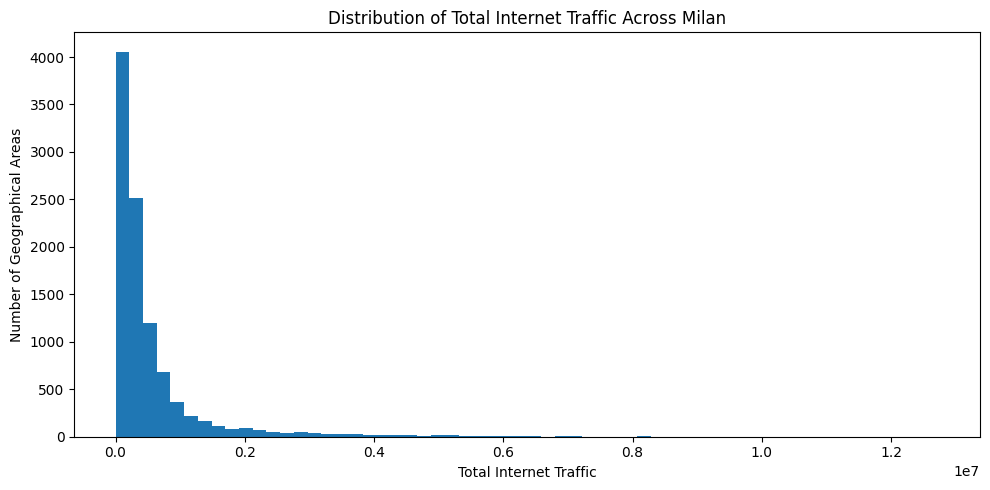

In [ ]:
# Distribution of total Internet traffic across geographical areas

plt.figure(figsize=(10, 5))

plt.hist(
    traffic_by_area["total"],
    bins=60
)

plt.xlabel("Total Internet Traffic")
plt.ylabel("Number of Geographical Areas")
plt.title(
    "Distribution of Total Internet Traffic Across Milan"
)

plt.tight_layout()
plt.show()

**Interpretation.** The distribution of total Internet traffic is strongly right-skewed. Most geographical areas exhibit relatively low cumulative Internet activity, whereas a small number of areas account for substantially larger traffic volumes. This demonstrates considerable spatial heterogeneity in mobile Internet usage across Milan and suggests that forecasting difficulty and model behaviour may vary across geographical areas with different traffic characteristics.

### 3.2 Temporal Patterns in Internet Activity

The forecasting problem also depends on temporal structure. City-wide Internet activity is therefore examined by time of day and day of week.

For each 10-minute timestamp, the mean Internet activity across geographical areas is calculated. The resulting series is then summarized by local Milan time. This provides evidence of recurring intraday and weekly patterns that may later inform sequence length and seasonal parameters used by the forecasting models.

In [ ]:
# ============================================================
# 3.2 CITY-WIDE TEMPORAL PROFILE
# ============================================================

city_temporal = (
    df_full
    .groupby("datetime", as_index=False)["internet"]
    .mean()
    .sort_values("datetime")
)

city_temporal["hour"] = (
    city_temporal["datetime"].dt.hour
)

city_temporal["minute"] = (
    city_temporal["datetime"].dt.minute
)

city_temporal["time_of_day"] = (
    city_temporal["datetime"].dt.strftime("%H:%M")
)

city_temporal["day_of_week"] = (
    city_temporal["datetime"].dt.day_name()
)

print("CITY-WIDE TEMPORAL SERIES")
print("=" * 55)

print("Observations:", len(city_temporal))

print(
    "\nMean Internet activity:",
    round(city_temporal["internet"].mean(), 2)
)

print(
    "Minimum city-wide mean:",
    round(city_temporal["internet"].min(), 2)
)

print(
    "Maximum city-wide mean:",
    round(city_temporal["internet"].max(), 2)
)

display(city_temporal.head())

CITY-WIDE TEMPORAL SERIES
Observations: 8928

Mean Internet activity: 62.29
Minimum city-wide mean: 20.91
Maximum city-wide mean: 123.67


,datetime,internet,hour,minute,time_of_day,day_of_week
0,2013-11-01 00:00:00+01:00,64.238831,0,0,00:00,Friday
1,2013-11-01 00:10:00+01:00,63.006813,0,10,00:10,Friday
2,2013-11-01 00:20:00+01:00,61.993320,0,20,00:20,Friday
3,2013-11-01 00:30:00+01:00,59.096306,0,30,00:30,Friday
4,2013-11-01 00:40:00+01:00,57.718777,0,40,00:40,Friday


Highest average traffic: 81.65 at 14:00
Lowest average traffic: 30.36 at 05:20


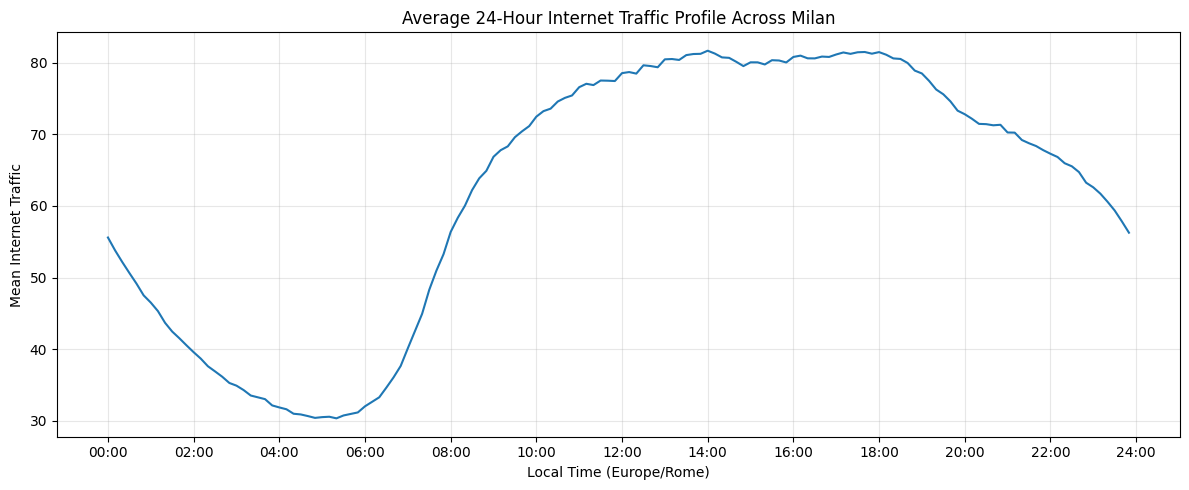

In [ ]:
# ============================================================
# 3.2.1 AVERAGE DAILY TRAFFIC PROFILE
# ============================================================

daily_profile = (
    city_temporal
    .groupby(
        ["hour", "minute"],
        as_index=False
    )["internet"]
    .mean()
)

daily_profile["minutes_after_midnight"] = (
    daily_profile["hour"] * 60
    + daily_profile["minute"]
)

peak_row = daily_profile.loc[
    daily_profile["internet"].idxmax()
]

lowest_row = daily_profile.loc[
    daily_profile["internet"].idxmin()
]

print(
    f"Highest average traffic: "
    f"{peak_row['internet']:.2f} at "
    f"{int(peak_row['hour']):02d}:"
    f"{int(peak_row['minute']):02d}"
)

print(
    f"Lowest average traffic: "
    f"{lowest_row['internet']:.2f} at "
    f"{int(lowest_row['hour']):02d}:"
    f"{int(lowest_row['minute']):02d}"
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_profile["minutes_after_midnight"],
    daily_profile["internet"]
)

plt.xticks(
    range(0, 1441, 120),
    [
        f"{h:02d}:00"
        for h in range(0, 25, 2)
    ]
)

plt.xlabel("Local Time (Europe/Rome)")
plt.ylabel("Mean Internet Traffic")
plt.title(
    "Average 24-Hour Internet Traffic Profile Across Milan"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,mean_internet
day_of_week,
Monday,64.364876
Tuesday,64.916824
Wednesday,63.863781
Thursday,66.681671
Friday,64.810539
Saturday,57.261654
Sunday,54.593918


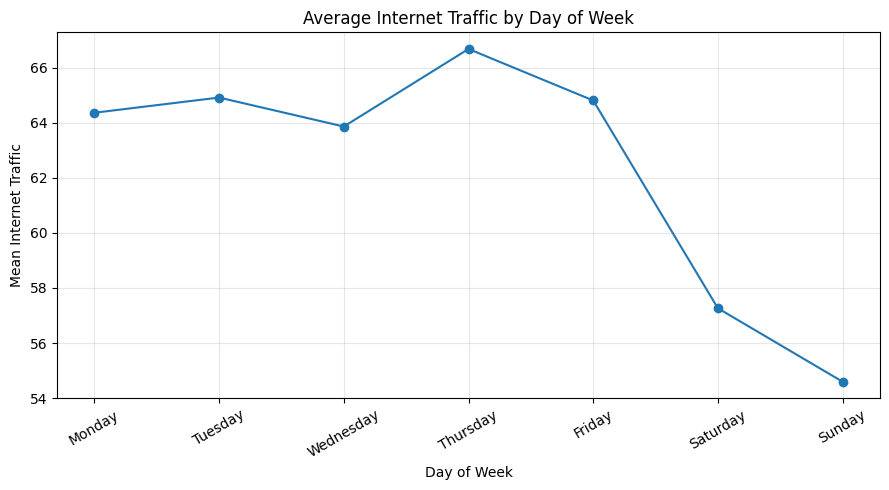

In [ ]:
# ============================================================
# 3.2.2 DAY-OF-WEEK PROFILE
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_profile = (
    city_temporal
    .groupby("day_of_week")["internet"]
    .mean()
    .reindex(day_order)
)

display(
    weekly_profile
    .rename("mean_internet")
    .to_frame()
)

plt.figure(figsize=(9, 5))

plt.plot(
    weekly_profile.index,
    weekly_profile.values,
    marker="o"
)

plt.xlabel("Day of Week")
plt.ylabel("Mean Internet Traffic")
plt.title(
    "Average Internet Traffic by Day of Week"
)

plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation.** Internet activity exhibits a pronounced intraday pattern. Traffic declines during the night and reaches its lowest level in the early morning, before increasing rapidly from approximately 06:00 onward. Activity remains comparatively high throughout the daytime and early evening before declining again at night. This recurring 24-hour structure suggests strong daily seasonality in the network traffic.

A weekly effect is also visible. Mean Internet activity is relatively similar from Monday to Friday but decreases substantially during the weekend, with Sunday exhibiting the lowest average traffic. These patterns indicate that mobile Internet traffic contains both short-term temporal dependence and recurring calendar-related structure. At the original 10-minute sampling frequency, one day corresponds to 144 observations and one week corresponds to 1,008 observations. These periods will therefore be investigated explicitly during subsequent time-series analysis.

### 3.3 Temporal Dependence and Seasonality

The descriptive temporal profiles suggest recurring daily and weekly patterns. To quantify temporal dependence, autocorrelation is examined at lags corresponding to several forecasting-relevant intervals.

Because observations occur every 10 minutes, important candidate lags include one hour (6 observations), six hours (36), twelve hours (72), one day (144), two days (288), and one week (1,008).

Strong autocorrelation at these lags would provide quantitative evidence that previous traffic observations contain information relevant to future traffic.

In [ ]:
# ============================================================
# 3.3 AUTOCORRELATION AT MEANINGFUL TEMPORAL LAGS
# ============================================================

from statsmodels.tsa.stattools import acf

city_series = (
    city_temporal
    .set_index("datetime")["internet"]
    .astype("float64")
)

lag_definitions = {
    "10 minutes": 1,
    "30 minutes": 3,
    "1 hour": 6,
    "6 hours": 36,
    "12 hours": 72,
    "1 day": 144,
    "2 days": 288,
    "1 week": 1008
}

acf_values = acf(
    city_series,
    nlags=1008,
    fft=True,
    missing="drop"
)

lag_results = []

for label, lag in lag_definitions.items():
    lag_results.append({
        "interval": label,
        "lag": lag,
        "autocorrelation": acf_values[lag]
    })

lag_results = pd.DataFrame(lag_results)

print("AUTOCORRELATION AT SELECTED LAGS")
print("=" * 55)

display(lag_results)

AUTOCORRELATION AT SELECTED LAGS


,interval,lag,autocorrelation
0,10 minutes,1,0.997081
1,30 minutes,3,0.987846
2,1 hour,6,0.957577
3,6 hours,36,0.180318
4,12 hours,72,-0.392546
5,1 day,144,0.919732
6,2 days,288,0.838048
7,1 week,1008,0.801566


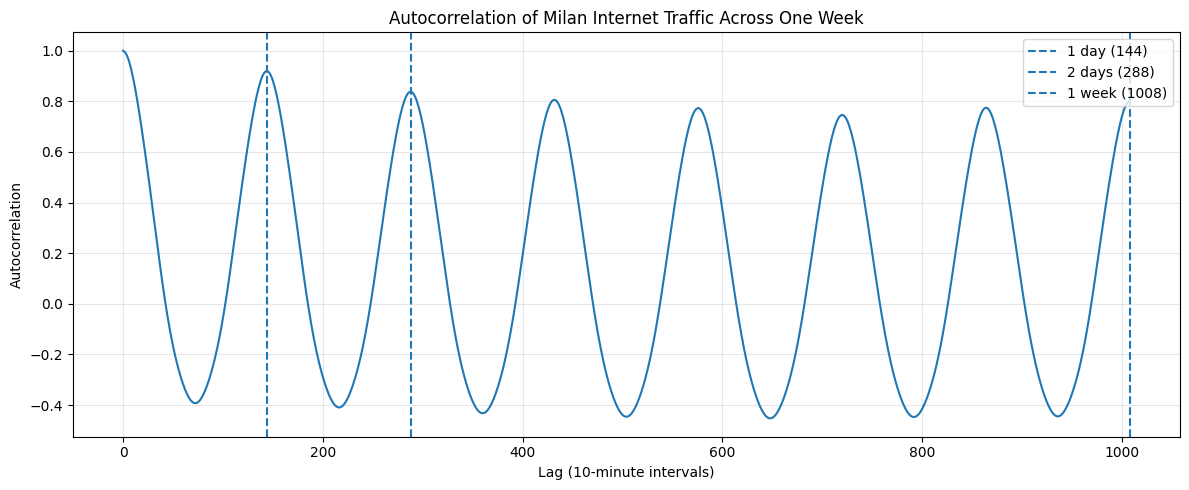

In [ ]:
# ============================================================
# ACF ACROSS ONE WEEK
# ============================================================

lags = np.arange(len(acf_values))

plt.figure(figsize=(12, 5))

plt.plot(
    lags,
    acf_values
)

plt.axvline(
    144,
    linestyle="--",
    label="1 day (144)"
)

plt.axvline(
    288,
    linestyle="--",
    label="2 days (288)"
)

plt.axvline(
    1008,
    linestyle="--",
    label="1 week (1008)"
)

plt.xlabel("Lag (10-minute intervals)")
plt.ylabel("Autocorrelation")
plt.title(
    "Autocorrelation of Milan Internet Traffic Across One Week"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation.** Internet traffic exhibits strong temporal dependence. Autocorrelation is extremely high at short forecasting horizons, with correlations of approximately 0.997 at 10 minutes and 0.958 at one hour. This indicates that recent observations contain substantial information about near-future traffic.

The autocorrelation does not simply decay monotonically. Instead, a strong oscillating pattern appears, with repeated positive peaks approximately every 144 observations. Since 144 ten-minute observations correspond to 24 hours, this provides quantitative evidence of pronounced daily seasonality. The one-day autocorrelation is approximately 0.920, while the two-day autocorrelation remains high at approximately 0.838.

The correlation at the one-week lag (1,008 observations) is also substantial at approximately 0.802, supporting the weekday/weekend differences observed previously. Together, these results indicate that the traffic series contains both strong short-term persistence and recurring seasonal structure. These characteristics are relevant to the later design of SARIMA seasonal terms and the historical input windows considered for the neural forecasting models.

### 3.4 Stationarity Analysis

Stationarity is particularly relevant to ARIMA-family forecasting models because changing levels or persistent trends can affect the suitability of a model fitted directly to the observed series.

Two complementary statistical tests are applied:

- **Augmented Dickey-Fuller (ADF):** the null hypothesis is that the series contains a unit root and is non-stationary.
- **KPSS:** the null hypothesis is that the series is stationary around a constant level.

Using both tests provides complementary evidence because their null hypotheses are reversed. The results are interpreted together rather than treating either test as definitive in isolation.

In [ ]:
# ============================================================
# 3.4 STATIONARITY TESTS
# ============================================================

from statsmodels.tsa.stattools import adfuller, kpss

stationarity_series = (
    city_series
    .dropna()
    .astype("float64")
)

# ----------------------------
# Augmented Dickey-Fuller
# ----------------------------

adf_result = adfuller(
    stationarity_series,
    autolag="AIC"
)

print("AUGMENTED DICKEY-FULLER TEST")
print("=" * 55)

print(f"ADF statistic: {adf_result[0]:.6f}")
print(f"p-value: {adf_result[1]:.6f}")
print(f"Number of lags used: {adf_result[2]}")
print(f"Number of observations: {adf_result[3]}")

print("\nCritical values:")

for key, value in adf_result[4].items():
    print(f"  {key}: {value:.6f}")


# ----------------------------
# KPSS
# ----------------------------

kpss_result = kpss(
    stationarity_series,
    regression="c",
    nlags="auto"
)

print("\nKPSS TEST")
print("=" * 55)

print(f"KPSS statistic: {kpss_result[0]:.6f}")
print(f"p-value: {kpss_result[1]:.6f}")
print(f"Number of lags used: {kpss_result[2]}")

print("\nCritical values:")

for key, value in kpss_result[3].items():
    print(f"  {key}: {value:.6f}")

AUGMENTED DICKEY-FULLER TEST
ADF statistic: -11.697149
p-value: 0.000000
Number of lags used: 37
Number of observations: 8890

Critical values:
  1%: -3.431086
  5%: -2.861865
  10%: -2.566943

KPSS TEST
KPSS statistic: 3.230697
p-value: 0.010000
Number of lags used: 56

Critical values:
  10%: 0.347000
  5%: 0.463000
  2.5%: 0.574000
  1%: 0.739000


/tmp/ipykernel_20770/2325926247.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(


**Interpretation.** The ADF and KPSS tests provide conflicting evidence about stationarity. The Augmented Dickey-Fuller test strongly rejects the null hypothesis of a unit root (ADF = -11.697, p < 0.001), providing evidence against unit-root non-stationarity. In contrast, the KPSS statistic is 3.231, substantially above the 1% critical value of 0.739, and its p-value is below 0.01. The KPSS test therefore rejects the null hypothesis of level stationarity.

Rather than treating either result in isolation, the disagreement suggests that the traffic series contains more complex temporal structure than can be summarized by a simple stationary/non-stationary classification. The previously observed strong daily and weekly cycles are particularly relevant. Consequently, differencing decisions for SARIMA will not be based solely on one stationarity test; seasonal structure and the behaviour of transformed series will also be examined.

### 3.5 Effect of Differencing

Because the stationarity tests provide conflicting evidence, differencing is investigated empirically rather than assumed to be necessary.

Two transformations are considered:

- **First differencing**, which measures changes between consecutive 10-minute observations.
- **Daily seasonal differencing**, which measures changes relative to the same time one day earlier (144 observations).

The resulting series are examined to determine whether these transformations reduce persistent temporal structure and to inform the differencing parameters considered later during SARIMA experimentation.

In [ ]:
# ============================================================
# 3.5 COMPARE DIFFERENCING STRATEGIES
# ============================================================

original = city_series.dropna()

first_diff = (
    original
    .diff(1)
    .dropna()
)

daily_diff = (
    original
    .diff(144)
    .dropna()
)

comparison = pd.DataFrame({
    "Original": original.describe(),
    "First difference": first_diff.describe(),
    "Daily seasonal difference": daily_diff.describe()
})

display(comparison)

,Original,First difference,Daily seasonal difference
count,8928.000000,8927.000000,8784.000000
mean,62.286415,-0.003131,-0.330744
std,22.328585,1.683539,8.152597
min,20.909292,-61.965462,-57.273621
25%,41.401246,-0.834929,-2.854226
50%,64.283993,-0.116520,-0.367460
75%,81.180321,0.661669,1.338625
max,123.668961,52.370262,51.786049


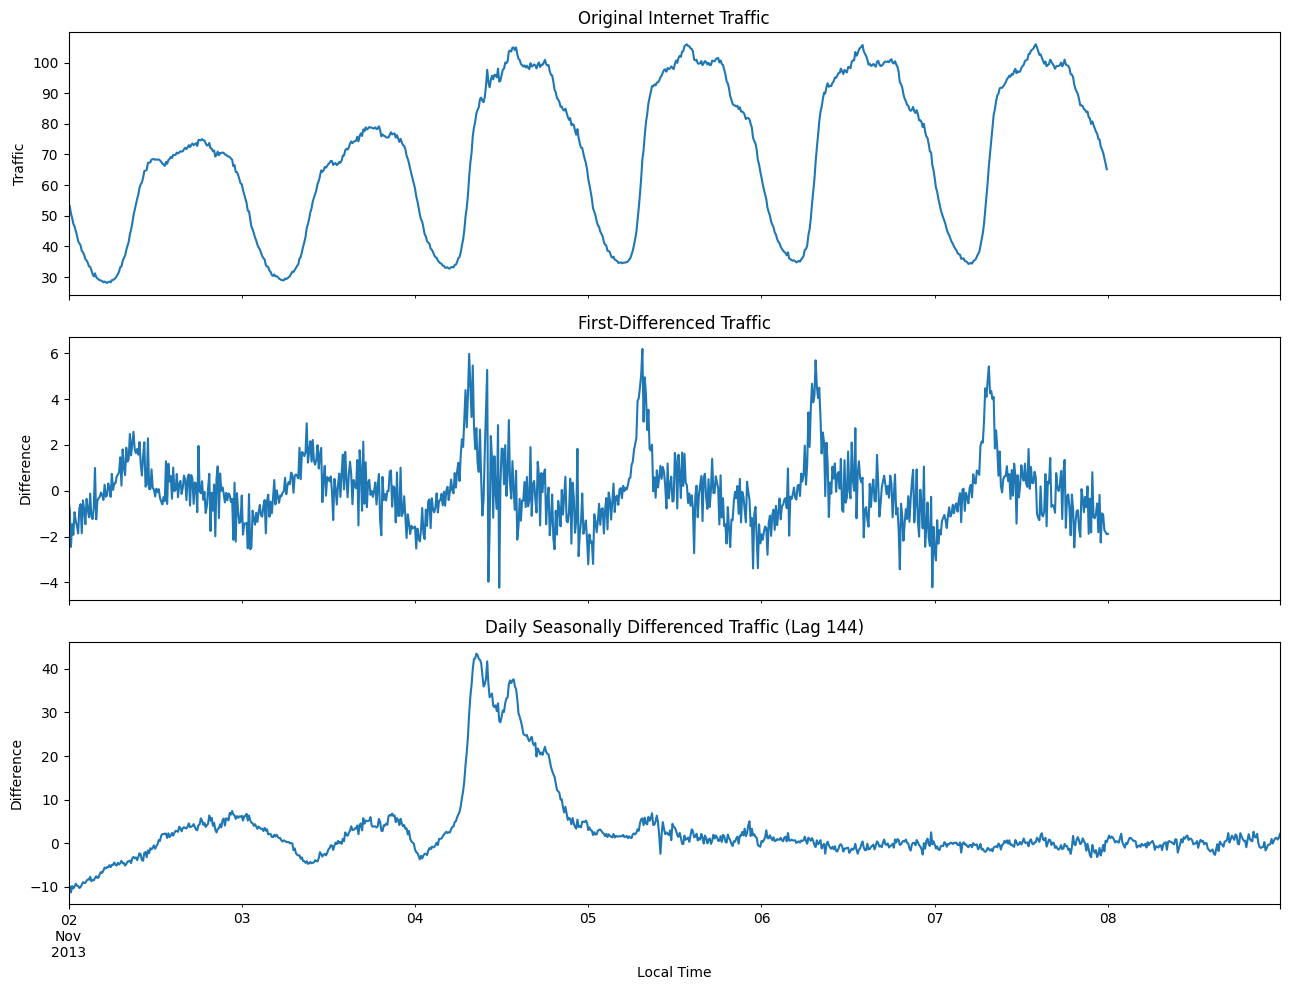

In [ ]:
# ============================================================
# VISUAL EFFECT OF DIFFERENCING
# ============================================================

window = 7 * 144

fig, axes = plt.subplots(
    3, 1,
    figsize=(13, 10),
    sharex=True
)

original.iloc[:window].plot(
    ax=axes[0]
)
axes[0].set_title("Original Internet Traffic")
axes[0].set_ylabel("Traffic")

first_diff.iloc[:window].plot(
    ax=axes[1]
)
axes[1].set_title("First-Differenced Traffic")
axes[1].set_ylabel("Difference")

daily_diff.iloc[:window].plot(
    ax=axes[2]
)
axes[2].set_title(
    "Daily Seasonally Differenced Traffic (Lag 144)"
)
axes[2].set_ylabel("Difference")
axes[2].set_xlabel("Local Time")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# AUTOCORRELATION AFTER DIFFERENCING
# ============================================================

def selected_acf(series, name):

    values = acf(
        series,
        nlags=1008,
        fft=True
    )

    return {
        "Series": name,
        "Lag 1": values[1],
        "Lag 6 (1 hour)": values[6],
        "Lag 144 (1 day)": values[144],
        "Lag 288 (2 days)": values[288],
        "Lag 1008 (1 week)": values[1008]
    }


acf_comparison = pd.DataFrame([
    selected_acf(
        original,
        "Original"
    ),
    selected_acf(
        first_diff,
        "First difference"
    ),
    selected_acf(
        daily_diff,
        "Daily seasonal difference"
    )
])

display(acf_comparison)

,Series,Lag 1,Lag 6 (1 hour),Lag 144 (1 day),Lag 288 (2 days),Lag 1008 (1 week)
0,Original,0.997081,0.957577,0.919732,0.838048,0.801566
1,First difference,0.115561,0.420995,0.408836,0.369494,0.399689
2,Daily seasonal difference,0.974478,0.925090,0.018923,-0.367096,0.776598


**Interpretation.** The differencing experiments show that ordinary and seasonal differencing remove different forms of temporal dependence. First differencing substantially reduces immediate persistence: lag-1 autocorrelation decreases from 0.997 in the original series to approximately 0.116. However, daily autocorrelation remains moderately strong at approximately 0.409, indicating that ordinary differencing alone does not eliminate the recurring daily structure.

Daily seasonal differencing has a different effect. Autocorrelation at the 144-step daily lag decreases dramatically from approximately 0.920 to 0.019, demonstrating that lag-144 differencing removes much of the repeated daily seasonal pattern. However, strong short-term dependence remains, with lag-1 autocorrelation of approximately 0.974. Weekly dependence also remains substantial (approximately 0.777 at lag 1,008), indicating that daily seasonal differencing does not account for all longer-term calendar structure.

The seasonally differenced series also contains periods of relatively large deviations, showing that individual days are not identical repetitions of a fixed daily pattern. These results support treating ordinary and seasonal differencing parameters as empirical modeling choices to be evaluated during SARIMA experimentation rather than fixing them solely from theoretical assumptions.

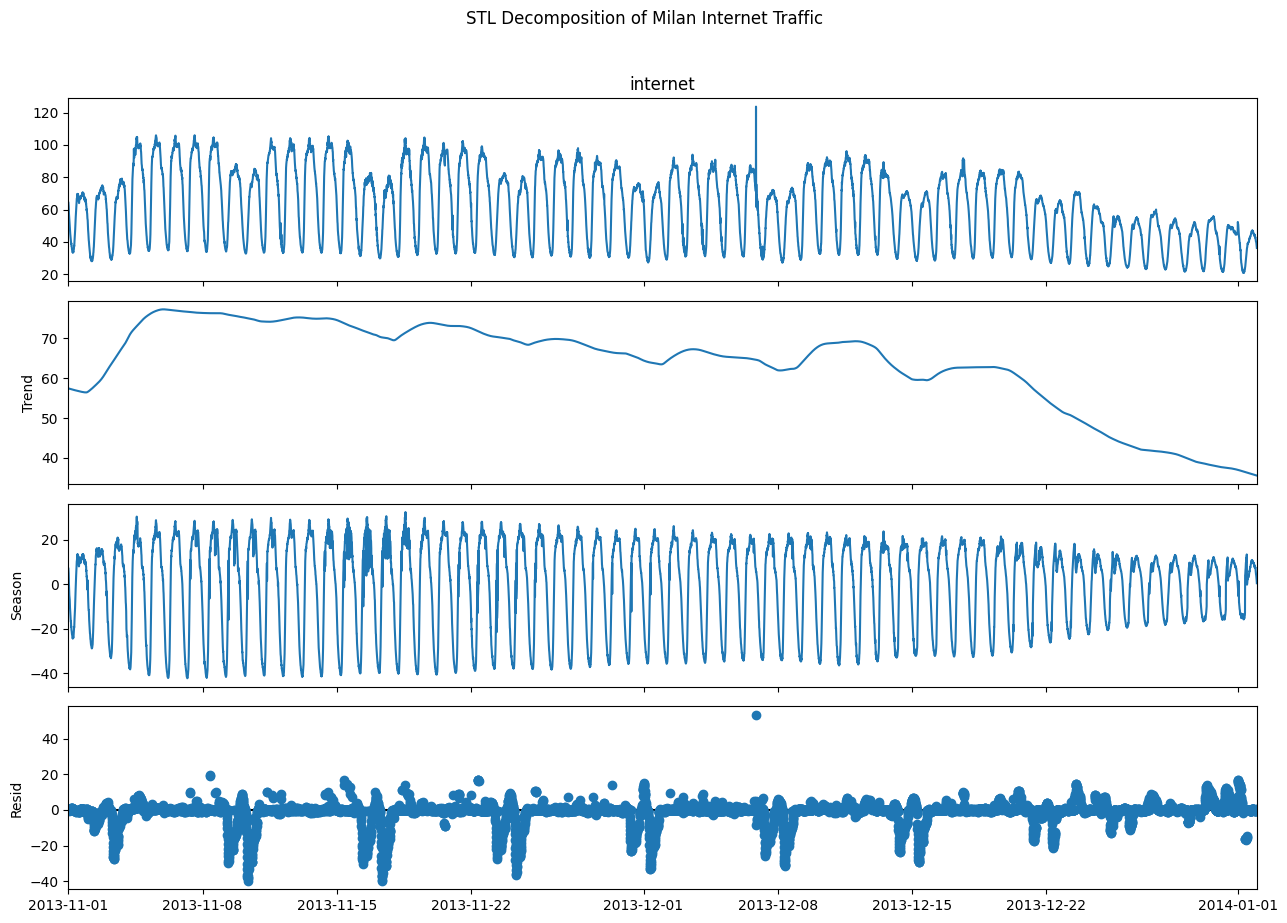

In [ ]:
# ============================================================
# 3.6 STL SEASONAL DECOMPOSITION
# ============================================================

from statsmodels.tsa.seasonal import STL

stl = STL(
    city_series,
    period=144,
    robust=True
)

stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(13, 9)

fig.suptitle(
    "STL Decomposition of Milan Internet Traffic",
    y=1.02
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# DECOMPOSITION COMPONENT SUMMARY
# ============================================================

decomposition_summary = pd.DataFrame({
    "Observed": city_series,
    "Trend": stl_result.trend,
    "Seasonal": stl_result.seasonal,
    "Residual": stl_result.resid
})

print("STL COMPONENT SUMMARY")
print("=" * 55)

display(
    decomposition_summary.describe()
)

seasonal_strength = max(
    0,
    1 - (
        np.var(stl_result.resid)
        /
        np.var(
            stl_result.resid
            + stl_result.seasonal
        )
    )
)

trend_strength = max(
    0,
    1 - (
        np.var(stl_result.resid)
        /
        np.var(
            stl_result.resid
            + stl_result.trend
        )
    )
)

print(
    f"Estimated seasonal strength: "
    f"{seasonal_strength:.4f}"
)

print(
    f"Estimated trend strength: "
    f"{trend_strength:.4f}"
)

STL COMPONENT SUMMARY


,Observed,Trend,Seasonal,Residual
count,8928.000000,8928.000000,8928.000000,8928.000000
mean,62.286415,63.725098,-0.005655,-1.433027
std,22.328585,11.096262,20.127078,6.490281
min,20.909292,35.550353,-42.223318,-39.900073
25%,41.401246,60.287604,-16.862326,-0.588530
50%,64.283993,66.399469,6.476127,-0.022875
75%,81.180321,71.993246,17.049798,0.504266
max,123.668961,77.314571,32.573331,53.491774


Estimated seasonal strength: 0.8927
Estimated trend strength: 0.7181


**Interpretation.** STL decomposition confirms that the Internet traffic series contains substantial daily seasonal and longer-term components. The estimated seasonal strength is 0.893, indicating that the recurring 24-hour cycle accounts for a large proportion of the systematic variation in the series. This is consistent with the repeated peaks observed in the autocorrelation analysis at multiples of 144 ten-minute observations.

The estimated trend strength is also substantial at 0.718. The trend component changes considerably across the observation period rather than remaining at a constant level, helping to explain why the ADF and KPSS stationarity tests provided conflicting conclusions.

Most residual values are concentrated relatively close to zero, although several large positive and negative deviations remain. These residual spikes indicate periods in which observed traffic differs substantially from the combination of the estimated trend and normal daily seasonal pattern. Consequently, the traffic cannot be represented solely as a fixed repeating daily cycle.

Overall, the decomposition, autocorrelation analysis, and temporal profiles consistently demonstrate strong daily seasonality, longer-term variation, and occasional irregular behaviour. These properties motivate comparing models with different abilities to represent temporal dependencies and nonlinear patterns.

In [ ]:
# ============================================================
# 4.1 CANDIDATE AREAS FOR FORECASTING
# ============================================================

complete_area_ids = coverage_by_area.index[
    coverage_by_area["total_unavailable"] == 0
]

area_candidates = (
    traffic_by_area
    .loc[complete_area_ids]
    .copy()
)

print("AREA SELECTION CANDIDATES")
print("=" * 55)

print(
    "Complete areas available:",
    len(area_candidates)
)

print("\nMean traffic quantiles:")
display(
    area_candidates["mean"]
    .quantile([0, .10, .25, .50, .75, .90, 1])
    .rename("mean_traffic")
    .to_frame()
)

print("\nCoefficient-of-variation quantiles:")
display(
    area_candidates["cv"]
    .quantile([0, .10, .25, .50, .75, .90, 1])
    .rename("cv")
    .to_frame()
)

print(
    "\nCorrelation between mean traffic and CV:",
    round(
        area_candidates["mean"]
        .corr(area_candidates["cv"]),
        4
    )
)

AREA SELECTION CANDIDATES
Complete areas available: 9902

Mean traffic quantiles:


,mean_traffic
0.00,0.302882
0.10,5.746012
0.25,13.329645
0.50,31.437198
0.75,65.060282
0.90,140.314854
1.00,1426.978027



Coefficient-of-variation quantiles:


,cv
0.00,0.194835
0.10,0.301160
0.25,0.334084
0.50,0.394004
0.75,0.536095
0.90,0.745978
1.00,3.476846



Correlation between mean traffic and CV: 0.0615


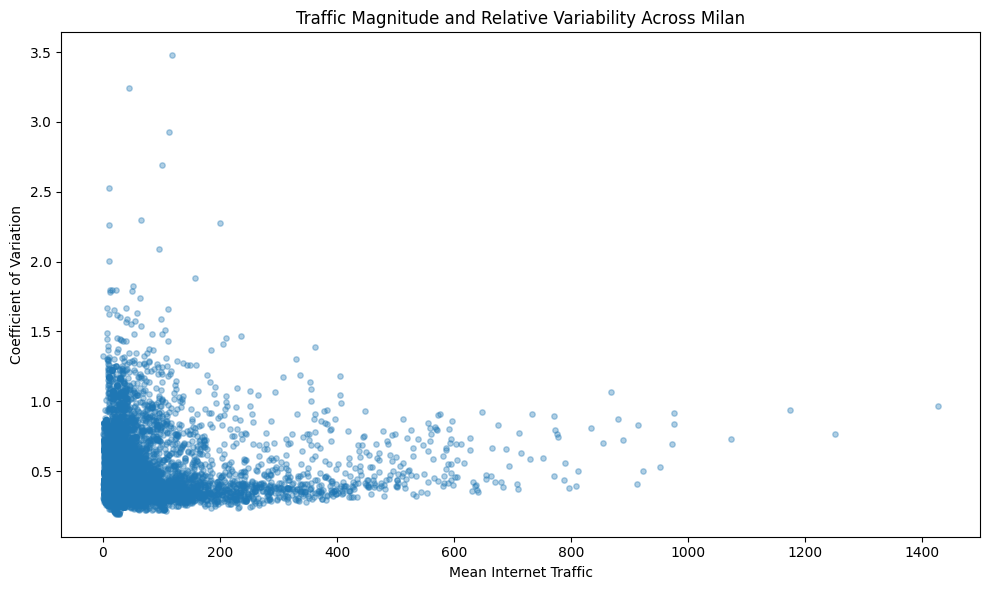

In [ ]:
# ============================================================
# TRAFFIC MAGNITUDE VS RELATIVE VARIABILITY
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    area_candidates["mean"],
    area_candidates["cv"],
    alpha=0.35,
    s=15
)

plt.xlabel("Mean Internet Traffic")
plt.ylabel("Coefficient of Variation")
plt.title(
    "Traffic Magnitude and Relative Variability Across Milan"
)

plt.tight_layout()
plt.show()

### 4.2 Quantitative Selection of Contrasting Areas

Mean traffic magnitude and relative variability exhibit only a weak linear relationship (Pearson correlation = 0.062). Therefore, traffic magnitude alone is insufficient for identifying areas with contrasting temporal characteristics.

To make geographical-area selection reproducible, each complete area's mean traffic and coefficient of variation are converted to percentile ranks. Three target traffic profiles are then defined:

- **Low/stable:** 25th percentile of traffic magnitude and 25th percentile of relative variability.
- **Medium/moderate:** 50th percentile of both characteristics.
- **High/variable:** 90th percentile of both characteristics.

For each profile, the geographical square with the smallest Euclidean distance from the target in percentile-rank space is selected.

This procedure avoids arbitrary visual selection, gives equal importance to traffic magnitude and relative variability despite their different numerical scales, and produces areas representing systematically different traffic conditions.

In [ ]:
# ============================================================
# 4.2 QUANTITATIVE SELECTION OF THREE CONTRASTING AREAS
# ============================================================

selection_data = area_candidates.copy()

# Convert characteristics to percentile ranks
selection_data["mean_percentile"] = (
    selection_data["mean"]
    .rank(pct=True)
)

selection_data["cv_percentile"] = (
    selection_data["cv"]
    .rank(pct=True)
)

# Target profiles in percentile space
targets = {
    "Low / stable": (0.25, 0.25),
    "Medium / moderate": (0.50, 0.50),
    "High / variable": (0.90, 0.90)
}

selected_rows = []

for profile, (target_mean, target_cv) in targets.items():

    distance = np.sqrt(
        (
            selection_data["mean_percentile"]
            - target_mean
        ) ** 2
        +
        (
            selection_data["cv_percentile"]
            - target_cv
        ) ** 2
    )

    square_id = distance.idxmin()

    row = selection_data.loc[square_id]

    selected_rows.append({
        "profile": profile,
        "square_id": square_id,
        "mean": row["mean"],
        "std": row["std"],
        "cv": row["cv"],
        "total": row["total"],
        "mean_percentile": row["mean_percentile"],
        "cv_percentile": row["cv_percentile"],
        "distance_to_target": distance.loc[square_id]
    })

selected_areas = (
    pd.DataFrame(selected_rows)
    .set_index("profile")
)

print("SELECTED FORECASTING AREAS")
print("=" * 65)

display(selected_areas)

SELECTED FORECASTING AREAS


,square_id,mean,std,cv,total,mean_percentile,cv_percentile,distance_to_target
profile,,,,,,,,
Low / stable,2404,13.038675,4.360807,0.334452,1.164093e+05,0.244698,0.251767,0.005589
Medium / moderate,6433,30.938326,12.166885,0.393263,2.762174e+05,0.495152,0.497273,0.005562
High / variable,5243,148.073608,113.554436,0.766878,1.322001e+06,0.905070,0.907291,0.008881


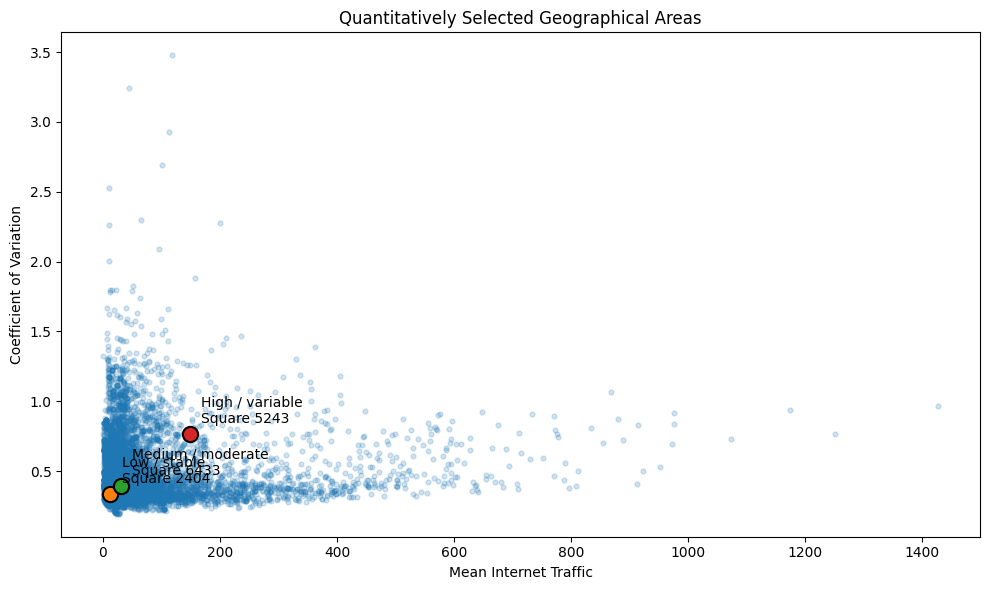

In [ ]:
# ============================================================
# VISUALISE SELECTED AREAS
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    selection_data["mean"],
    selection_data["cv"],
    alpha=0.20,
    s=12,
    label="Candidate areas"
)

for profile, row in selected_areas.iterrows():

    plt.scatter(
        row["mean"],
        row["cv"],
        s=120,
        edgecolor="black",
        linewidth=1.5
    )

    plt.annotate(
        f"{profile}\nSquare {int(row['square_id'])}",
        (row["mean"], row["cv"]),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Mean Internet Traffic")
plt.ylabel("Coefficient of Variation")

plt.title(
    "Quantitatively Selected Geographical Areas"
)

plt.tight_layout()
plt.show()

**Interpretation.** The quantitative selection procedure identified three geographical areas with clearly contrasting traffic characteristics. Square 2404 represents a relatively low-volume and stable traffic profile, with mean Internet activity of 13.04 and a coefficient of variation of 0.334. Square 6433 represents a medium-volume, moderately variable profile, with mean activity of 30.94 and a coefficient of variation of 0.393. Square 5243 represents a substantially higher-volume and more variable profile, with mean activity of 148.07 and a coefficient of variation of 0.767.

The selected areas are close to their predefined targets in percentile-rank space, with distances below 0.01 for all three profiles. This provides a reproducible basis for investigating whether forecasting-model performance changes across areas with different traffic magnitude and relative variability.

In [ ]:
# ============================================================
# 4.3 EXTRACT SELECTED FORECASTING AREAS
# ============================================================

selected_ids = (
    selected_areas["square_id"]
    .astype(int)
    .tolist()
)

profile_map = {
    int(row["square_id"]): profile
    for profile, row in selected_areas.iterrows()
}

df_selected = (
    df_full[
        df_full["square_id"].isin(selected_ids)
    ]
    [["square_id", "datetime", "internet"]]
    .copy()
    .sort_values(["square_id", "datetime"])
    .reset_index(drop=True)
)

df_selected["profile"] = (
    df_selected["square_id"]
    .map(profile_map)
)

print("SELECTED DATASET")
print("=" * 55)

print("Selected square IDs:", selected_ids)
print("Shape:", df_selected.shape)

print("\nObservations per area:")
print(
    df_selected
    .groupby(["profile", "square_id"])
    .size()
)

print("\nMissing values per area:")
print(
    df_selected
    .groupby(["profile", "square_id"])["internet"]
    .apply(lambda x: x.isna().sum())
)

print("\nTime range:")
print(
    df_selected["datetime"].min(),
    "to",
    df_selected["datetime"].max()
)

SELECTED DATASET
Selected square IDs: [2404, 6433, 5243]
Shape: (26784, 4)

Observations per area:
profile            square_id
High / variable    5243         8928
Low / stable       2404         8928
Medium / moderate  6433         8928
dtype: int64

Missing values per area:
profile            square_id
High / variable    5243         0
Low / stable       2404         0
Medium / moderate  6433         0
Name: internet, dtype: int64

Time range:
2013-11-01 00:00:00+01:00 to 2014-01-01 23:50:00+01:00


### 4.3 Selected Area Time-Series Comparison

The selected areas are now examined as individual time series. This verifies that the differences identified through summary statistics correspond to meaningful differences in temporal behaviour.

Because the areas have substantially different traffic magnitudes, separate panels are used rather than plotting all three series on a common vertical scale.

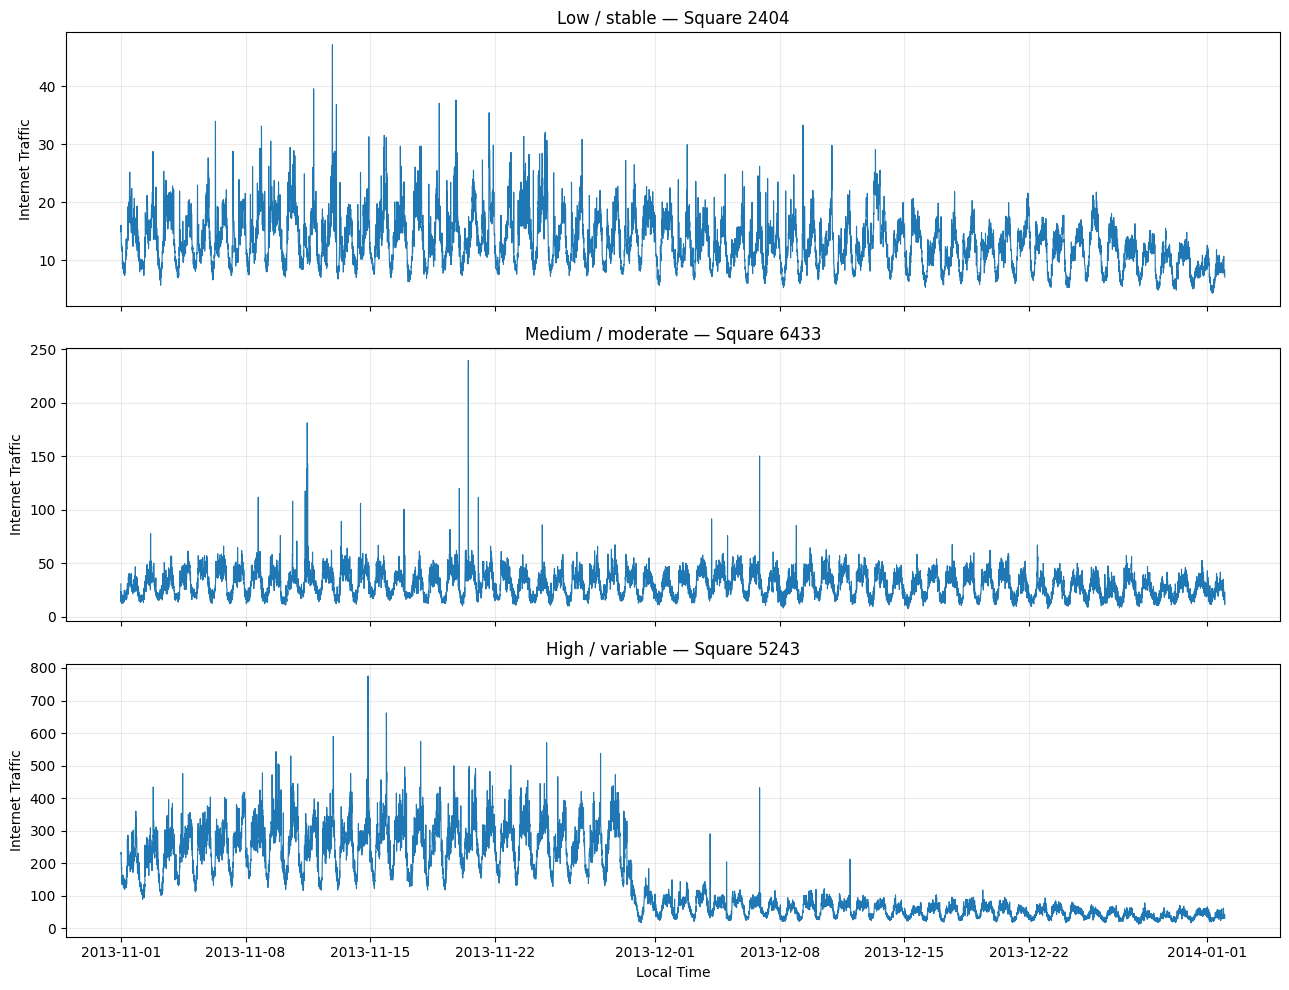

In [ ]:
# ============================================================
# COMPARE SELECTED TIME SERIES
# ============================================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(13, 10),
    sharex=True
)

profile_order = [
    "Low / stable",
    "Medium / moderate",
    "High / variable"
]

for ax, profile in zip(axes, profile_order):

    area_id = int(
        selected_areas.loc[
            profile,
            "square_id"
        ]
    )

    area_data = df_selected[
        df_selected["square_id"] == area_id
    ]

    ax.plot(
        area_data["datetime"],
        area_data["internet"],
        linewidth=0.8
    )

    ax.set_title(
        f"{profile} — Square {area_id}"
    )

    ax.set_ylabel("Internet Traffic")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Local Time")

plt.tight_layout()
plt.show()

**Interpretation.** The selected geographical areas exhibit clearly different temporal characteristics. Square 2404 has relatively low traffic with a regular recurring pattern and occasional short-lived spikes. Square 6433 operates at a higher traffic level and displays larger irregular peaks while retaining a visible recurring temporal cycle.

Square 5243 is substantially more volatile and exhibits a particularly notable change in traffic level around the beginning of December. Activity is considerably higher during November before falling sharply and remaining at a lower level through much of December. This suggests that the high/variable series may contain a structural or regime change in addition to recurring seasonal behaviour.

These differences make the selected areas suitable for investigating whether forecasting models respond differently to stable, moderately variable, and highly variable traffic conditions. The observed regime change in Square 5243 will also be considered when interpreting model errors and failure cases.

In [ ]:
# ============================================================
# RELEASE FULL DATASET FROM MEMORY
# ============================================================

del df_full
gc.collect()

selected_memory_mb = (
    df_selected.memory_usage(deep=True).sum()
    / 1024**2
)

print(
    f"Selected forecasting dataset memory: "
    f"{selected_memory_mb:.2f} MB"
)

Selected forecasting dataset memory: 1.98 MB


## 5. Forecasting Experimental Design

### 5.1 Forecasting Protocol

The forecasting task is defined as **one-step-ahead prediction at the original 10-minute temporal resolution**. At time \(t\), each model predicts Internet traffic at \(t+1\), corresponding to ten minutes into the future.

To ensure a fair comparison, SARIMA, LSTM, and Transformer models will use the same three geographical areas, temporal resolution, forecasting horizon, chronological data partitions, and evaluation metrics.

Each geographical time series is divided chronologically into:

- **70% training data:** used to estimate model parameters.
- **15% validation data:** used for model selection and hyperparameter experimentation.
- **15% test data:** held completely unseen until the final model configuration has been selected.

Random splitting is not used because it would allow future observations to influence training and would violate the temporal ordering of the forecasting problem.

The test set is treated as a final holdout and will not be used to select architectures, sequence lengths, SARIMA orders, learning rates, or other hyperparameters.

In [ ]:
# ============================================================
# 5.1 DEFINE CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLITS
# ============================================================

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

n_per_area = 8928

train_end = int(
    n_per_area * TRAIN_RATIO
)

val_end = int(
    n_per_area * (TRAIN_RATIO + VAL_RATIO)
)

split_summary = []

for profile in profile_order:

    area_id = int(
        selected_areas.loc[
            profile,
            "square_id"
        ]
    )

    area_data = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")
        .reset_index(drop=True)
    )

    train = area_data.iloc[:train_end]
    validation = area_data.iloc[train_end:val_end]
    test = area_data.iloc[val_end:]

    split_summary.append({
        "profile": profile,
        "square_id": area_id,

        "train_n": len(train),
        "train_start": train["datetime"].iloc[0],
        "train_end": train["datetime"].iloc[-1],

        "validation_n": len(validation),
        "validation_start": validation["datetime"].iloc[0],
        "validation_end": validation["datetime"].iloc[-1],

        "test_n": len(test),
        "test_start": test["datetime"].iloc[0],
        "test_end": test["datetime"].iloc[-1]
    })

split_summary = pd.DataFrame(
    split_summary
)

print("FORECASTING DATA SPLITS")
print("=" * 70)

print(f"Total observations per area: {n_per_area}")
print(f"Training boundary: {train_end}")
print(f"Validation boundary: {val_end}")

display(split_summary)

FORECASTING DATA SPLITS
Total observations per area: 8928
Training boundary: 6249
Validation boundary: 7588


,profile,square_id,train_n,train_start,train_end,validation_n,validation_start,validation_end,test_n,test_start,test_end
0,Low / stable,2404,6249,2013-11-01 00:00:00+01:00,2013-12-14 09:20:00+01:00,1339,2013-12-14 09:30:00+01:00,2013-12-23 16:30:00+01:00,1340,2013-12-23 16:40:00+01:00,2014-01-01 23:50:00+01:00
1,Medium / moderate,6433,6249,2013-11-01 00:00:00+01:00,2013-12-14 09:20:00+01:00,1339,2013-12-14 09:30:00+01:00,2013-12-23 16:30:00+01:00,1340,2013-12-23 16:40:00+01:00,2014-01-01 23:50:00+01:00
2,High / variable,5243,6249,2013-11-01 00:00:00+01:00,2013-12-14 09:20:00+01:00,1339,2013-12-14 09:30:00+01:00,2013-12-23 16:30:00+01:00,1340,2013-12-23 16:40:00+01:00,2014-01-01 23:50:00+01:00


### 5.2 Evaluation Metrics and Naive Baseline

Model performance is evaluated using multiple complementary error metrics:

- **MAE (Mean Absolute Error):** measures the average absolute forecasting error in the original traffic units.
- **RMSE (Root Mean Squared Error):** gives greater weight to large forecasting errors and is therefore useful for identifying sensitivity to traffic spikes.
- **sMAPE (Symmetric Mean Absolute Percentage Error):** expresses forecasting error relative to traffic magnitude and facilitates comparison across geographical areas with substantially different traffic scales.

Because mobile Internet traffic exhibits very strong short-term autocorrelation, a **persistence baseline** is also evaluated. For one-step-ahead forecasting, this baseline predicts that the next 10-minute traffic value will equal the most recently observed value.

The baseline provides an important reference point: a complex sequential model should be evaluated not only by its absolute error but also by whether it improves upon a simple forecast based on short-term persistence.

All hyperparameter decisions will be made using validation-set performance. The test set remains untouched until final model configurations have been selected.

In [ ]:
# ============================================================
# 5.2 FORECASTING EVALUATION METRICS
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

def smape(y_true, y_pred):
    """
    Symmetric Mean Absolute Percentage Error.
    Returned as a percentage.
    """

    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    denominator = (
        np.abs(y_true)
        + np.abs(y_pred)
    )

    numerator = (
        2.0
        * np.abs(y_pred - y_true)
    )

    values = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(
            numerator,
            dtype=np.float64
        ),
        where=denominator != 0
    )

    return 100 * np.mean(values)


def evaluate_forecast(
    y_true,
    y_pred
):
    """
    Return the common metrics used throughout
    the forecasting experiment.
    """

    y_true = np.asarray(
        y_true,
        dtype=np.float64
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.float64
    )

    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),

        "sMAPE (%)": smape(
            y_true,
            y_pred
        )
    }

In [ ]:
# ============================================================
# 5.3 PERSISTENCE BASELINE — VALIDATION SET
# ============================================================

baseline_validation_results = []

for profile in profile_order:

    area_id = int(
        selected_areas.loc[
            profile,
            "square_id"
        ]
    )

    area_series = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")["internet"]
        .to_numpy(dtype=np.float64)
    )

    train_values = (
        area_series[:train_end]
    )

    validation_values = (
        area_series[
            train_end:val_end
        ]
    )

    # One-step persistence:
    # first validation prediction = last training value
    persistence_predictions = np.concatenate([
        [train_values[-1]],
        validation_values[:-1]
    ])

    metrics = evaluate_forecast(
        validation_values,
        persistence_predictions
    )

    baseline_validation_results.append({
        "model": "Persistence",
        "profile": profile,
        "square_id": area_id,
        **metrics
    })


baseline_validation_results = pd.DataFrame(
    baseline_validation_results
)

print("PERSISTENCE BASELINE — VALIDATION")
print("=" * 65)

display(
    baseline_validation_results
)

PERSISTENCE BASELINE — VALIDATION


,model,profile,square_id,MAE,RMSE,sMAPE (%)
0,Persistence,Low / stable,2404,1.139573,1.487545,9.562209
1,Persistence,Medium / moderate,6433,5.463317,7.082905,19.424350
2,Persistence,High / variable,5243,8.622653,11.144783,16.634987


In [ ]:
def percentage_improvement(
    baseline_error,
    model_error
):
    return (
        (baseline_error - model_error)
        / baseline_error
        * 100
    )

## 6. Statistical Forecasting: From SARIMA to Fourier-Seasonal ARIMA

### 6.1 Training-Set Time-Series Diagnostics

The statistical forecasting stage begins by examining temporal dependence, differencing requirements, and daily seasonality using only the training portion of each selected geographical area. This avoids using validation or test targets to determine the statistical model structure.

The analysis considers stationarity using ADF and KPSS tests, short-term autocorrelation, daily seasonal autocorrelation at lag 144, and the effect of daily seasonal differencing. These diagnostics provide an evidence-based starting point for low-order ARIMA experiments and for representing the observed 24-hour seasonal cycle.

A full seasonal SARIMA specification is attempted first. When the 144-step seasonal state-space representation proves computationally infeasible at the original 10-minute resolution, the statistical strategy is adapted to Fourier-seasonal ARIMA while retaining the same forecasting horizon and data frequency.

In [ ]:
# ============================================================
# 6.1 TRAINING-SET STATIONARITY DIAGNOSTICS
# ============================================================

sarima_diagnostics = []

for profile in profile_order:

    area_id = int(
        selected_areas.loc[
            profile,
            "square_id"
        ]
    )

    series = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")["internet"]
        .iloc[:train_end]
        .astype("float64")
    )

    # ADF
    adf_result = adfuller(
        series,
        autolag="AIC"
    )

    # KPSS
    kpss_result = kpss(
        series,
        regression="c",
        nlags="auto"
    )

    sarima_diagnostics.append({
        "profile": profile,
        "square_id": area_id,
        "ADF statistic": adf_result[0],
        "ADF p-value": adf_result[1],
        "KPSS statistic": kpss_result[0],
        "KPSS p-value": kpss_result[1]
    })

sarima_diagnostics = pd.DataFrame(
    sarima_diagnostics
)

print("TRAINING-SET STATIONARITY TESTS")
print("=" * 70)

display(sarima_diagnostics)

/tmp/ipykernel_20770/1834990324.py:32: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(


TRAINING-SET STATIONARITY TESTS


/tmp/ipykernel_20770/1834990324.py:32: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(


,profile,square_id,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,Low / stable,2404,-12.991699,2.803755e-24,0.645239,0.018524
1,Medium / moderate,6433,-12.754922,8.379487e-24,0.069664,0.100000
2,High / variable,5243,-5.733191,6.528227e-07,7.760502,0.010000


In [ ]:
# ============================================================
# 6.2 TRAINING-SET TEMPORAL DEPENDENCE
# ============================================================

area_acf_results = []

for profile in profile_order:

    area_id = int(
        selected_areas.loc[
            profile,
            "square_id"
        ]
    )

    series = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")["internet"]
        .iloc[:train_end]
        .to_numpy(dtype=np.float64)
    )

    values = acf(
        series,
        nlags=288,
        fft=True
    )

    area_acf_results.append({
        "profile": profile,
        "square_id": area_id,
        "lag_1": values[1],
        "lag_6_1hour": values[6],
        "lag_72_12hours": values[72],
        "lag_144_1day": values[144],
        "lag_288_2days": values[288]
    })

area_acf_results = pd.DataFrame(
    area_acf_results
)

print("TRAINING-SET AUTOCORRELATION")
print("=" * 70)

display(area_acf_results)

TRAINING-SET AUTOCORRELATION


,profile,square_id,lag_1,lag_6_1hour,lag_72_12hours,lag_144_1day,lag_288_2days
0,Low / stable,2404,0.818973,0.683432,-0.154844,0.547391,0.496050
1,Medium / moderate,6433,0.703161,0.628853,-0.366075,0.575741,0.514958
2,High / variable,5243,0.939187,0.903513,0.566439,0.837517,0.776619


In [ ]:
# ============================================================
# 6.3 EFFECT OF DAILY SEASONAL DIFFERENCING
# ============================================================

seasonal_diff_results = []

for profile in profile_order:

    area_id = int(
        selected_areas.loc[
            profile,
            "square_id"
        ]
    )

    series = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")["internet"]
        .iloc[:train_end]
        .to_numpy(dtype=np.float64)
    )

    seasonal_diff = (
        pd.Series(series)
        .diff(144)
        .dropna()
        .to_numpy()
    )

    original_acf = acf(
        series,
        nlags=144,
        fft=True
    )

    differenced_acf = acf(
        seasonal_diff,
        nlags=144,
        fft=True
    )

    seasonal_diff_results.append({
        "profile": profile,
        "square_id": area_id,
        "original_lag_1": original_acf[1],
        "original_lag_144": original_acf[144],
        "seasonal_diff_lag_1": differenced_acf[1],
        "seasonal_diff_lag_144": differenced_acf[144]
    })

seasonal_diff_results = pd.DataFrame(
    seasonal_diff_results
)

print("DAILY SEASONAL DIFFERENCING")
print("=" * 70)

display(seasonal_diff_results)

DAILY SEASONAL DIFFERENCING


,profile,square_id,original_lag_1,original_lag_144,seasonal_diff_lag_1,seasonal_diff_lag_144
0,Low / stable,2404,0.818973,0.547391,0.587618,-0.416266
1,Medium / moderate,6433,0.703161,0.575741,0.317494,-0.437833
2,High / variable,5243,0.939187,0.837517,0.572398,-0.354111


**Interpretation.** The three forecasting areas exhibit different stationarity and dependence characteristics. For Square 6433, the ADF test rejects the unit-root null while KPSS does not reject level stationarity, providing the clearest evidence of stationarity among the selected areas. Squares 2404 and 5243 produce conflicting ADF and KPSS conclusions. The disagreement is particularly pronounced for Square 5243, consistent with the substantial change in traffic level observed earlier in its time series.

Daily temporal dependence is present in all three training series. Autocorrelation at lag 144 is approximately 0.547 for Square 2404, 0.576 for Square 6433, and 0.838 for Square 5243. The high/variable area therefore exhibits especially persistent daily structure.

Applying lag-144 seasonal differencing substantially changes this dependence. The resulting lag-144 autocorrelations become negative for all three areas (-0.416, -0.438, and -0.354 respectively). This indicates that seasonal differencing removes the original positive daily persistence but may also introduce negative dependence at the seasonal lag. Consequently, seasonal differencing will not be assumed to be universally optimal. Both D=0 and D=1 will be considered during SARIMA validation experiments.

### 6.4 ACF and PACF Diagnostics for Candidate ARIMA Orders

ACF and PACF plots are examined on first-differenced training series to identify plausible low-order autoregressive and moving-average structures.

The plots are not used to determine a single specification mechanically. Instead, they restrict the initial search to small, interpretable values of \(p\) and \(q\), with final configuration selection based on one-step-ahead validation performance.

The first 36 lags are examined, corresponding to six hours of 10-minute observations.

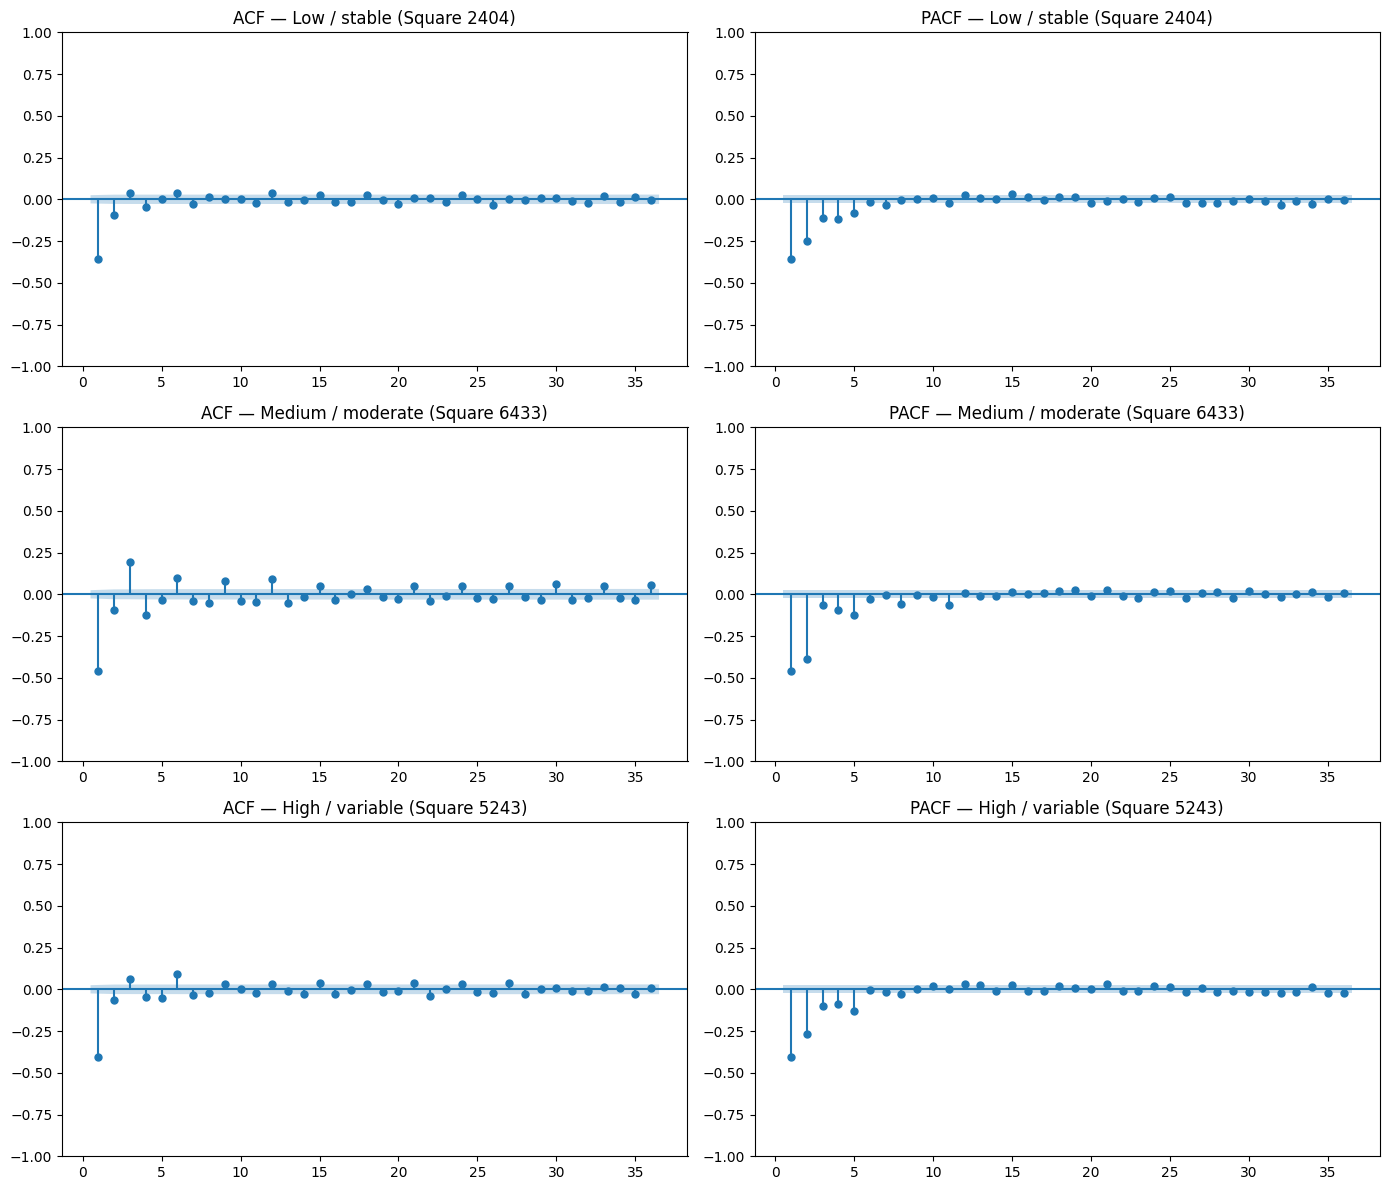

In [ ]:
# ============================================================
# 6.4 ACF / PACF OF FIRST-DIFFERENCED TRAINING SERIES
# ============================================================

from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)

fig, axes = plt.subplots(
    3, 2,
    figsize=(14, 12)
)

for row, profile in enumerate(profile_order):

    area_id = int(
        selected_areas.loc[
            profile,
            "square_id"
        ]
    )

    train_series = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")["internet"]
        .iloc[:train_end]
        .astype("float64")
    )

    first_difference = (
        train_series
        .diff()
        .dropna()
    )

    plot_acf(
        first_difference,
        lags=36,
        ax=axes[row, 0],
        zero=False
    )

    axes[row, 0].set_title(
        f"ACF — {profile} (Square {area_id})"
    )

    plot_pacf(
        first_difference,
        lags=36,
        ax=axes[row, 1],
        zero=False,
        method="ywm"
    )

    axes[row, 1].set_title(
        f"PACF — {profile} (Square {area_id})"
    )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CORRELATION AROUND DAILY SEASONAL LAG
# ============================================================

seasonal_lag_results = []

for profile in profile_order:

    area_id = int(
        selected_areas.loc[
            profile,
            "square_id"
        ]
    )

    train_series = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")["internet"]
        .iloc[:train_end]
        .to_numpy(dtype=np.float64)
    )

    acf_values_area = acf(
        train_series,
        nlags=150,
        fft=True
    )

    seasonal_lag_results.append({
        "profile": profile,
        "square_id": area_id,
        "lag_142": acf_values_area[142],
        "lag_143": acf_values_area[143],
        "lag_144": acf_values_area[144],
        "lag_145": acf_values_area[145],
        "lag_146": acf_values_area[146]
    })

seasonal_lag_results = pd.DataFrame(
    seasonal_lag_results
)

display(seasonal_lag_results)

,profile,square_id,lag_142,lag_143,lag_144,lag_145,lag_146
0,Low / stable,2404,0.531893,0.541221,0.547391,0.549017,0.545586
1,Medium / moderate,6433,0.556813,0.559123,0.575741,0.561382,0.561726
2,High / variable,5243,0.841335,0.838793,0.837517,0.836974,0.836223


**Interpretation.** The first-differenced ACF and PACF plots show that the strongest short-term dependence occurs at the earliest lags across all three geographical areas. The relatively limited structure at higher short-term lags supports restricting the initial non-seasonal AR and MA orders to small values.

The original training series also retain substantial correlation around the daily seasonal lag. Correlation at lag 144 is approximately 0.547 for Square 2404, 0.576 for Square 6433, and 0.838 for Square 5243. The correlations at neighbouring lags 142–146 are similarly elevated, indicating broad daily persistence rather than a single isolated correlation at exactly 144 observations.

These diagnostics are therefore used to define a small set of plausible SARIMA configurations rather than mechanically selecting one model. The final specification will be determined empirically using one-step-ahead validation performance.

In [ ]:
# ============================================================
# 6.5 SARIMA EXPERIMENT 1 — LOW/STABLE AREA
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

SARIMA_ORDER = (1, 0, 1)
SARIMA_SEASONAL_ORDER = (1, 0, 0, 144)

profile = "Low / stable"

area_id = int(
    selected_areas.loc[
        profile,
        "square_id"
    ]
)

area_values = (
    df_selected[
        df_selected["square_id"] == area_id
    ]
    .sort_values("datetime")["internet"]
    .to_numpy(dtype=np.float64)
)

train_values = area_values[:train_end]

validation_values = area_values[
    train_end:val_end
]

print(
    f"Experiment 1: "
    f"SARIMA{SARIMA_ORDER}"
    f"{SARIMA_SEASONAL_ORDER}"
)

print(
    f"Area: {profile} "
    f"(Square {area_id})"
)

start_time = time.perf_counter()

model = SARIMAX(
    train_values,
    order=SARIMA_ORDER,
    seasonal_order=SARIMA_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fitted_model = model.fit(
    disp=False,
    maxiter=100
)

fit_time = (
    time.perf_counter()
    - start_time
)

print(
    f"\nModel fitted in "
    f"{fit_time:.2f} seconds"
)

print(
    "Converged:",
    fitted_model.mle_retvals.get(
        "converged",
        "unknown"
    )
)

print(
    "AIC:",
    round(fitted_model.aic, 2)
)

print(
    "BIC:",
    round(fitted_model.bic, 2)
)

Experiment 1: SARIMA(1, 0, 1)(1, 0, 0, 144)
Area: Low / stable (Square 2404)


### 6.5.1 Computational Limitation of Full Seasonal SARIMA

An initial SARIMA specification, \(SARIMA(1,0,1)(1,0,0)_{144}\), was attempted using the original 10-minute sampling frequency. The seasonal period of 144 corresponds directly to the empirically observed 24-hour cycle.

However, fitting the model exhausted the available runtime memory before estimation completed. This demonstrates an important computational limitation of explicitly representing a long seasonal period within the SARIMA state-space formulation.

Rather than changing the forecasting resolution, which would alter the original one-step-ahead 10-minute forecasting problem, the statistical modeling strategy was adapted to preserve the original data frequency. Daily seasonality is represented using Fourier terms, while a lower-order ARIMA component models short-term temporal dependence.

This maintains the experimentally supported 24-hour seasonal structure while substantially reducing the computational burden of the statistical model.

In [ ]:
# ============================================================
# 6.6 FOURIER REPRESENTATION OF DAILY SEASONALITY
# ============================================================

def create_fourier_terms(
    n,
    period=144,
    K=2,
    start=0
):
    """
    Create Fourier terms for seasonal structure.
    """

    t = np.arange(
        start,
        start + n
    )

    terms = {}

    for k in range(1, K + 1):

        terms[f"sin_{k}"] = np.sin(
            2 * np.pi * k * t / period
        )

        terms[f"cos_{k}"] = np.cos(
            2 * np.pi * k * t / period
        )

    return pd.DataFrame(terms)


# Demonstration
fourier_example = create_fourier_terms(
    n=144,
    period=144,
    K=2
)

print("Fourier design matrix shape:")
print(fourier_example.shape)

display(fourier_example.head())

Fourier design matrix shape:
(144, 4)


,sin_1,cos_1,sin_2,cos_2
0,0.000000,1.000000,0.000000,1.000000
1,0.043619,0.999048,0.087156,0.996195
2,0.087156,0.996195,0.173648,0.984808
3,0.130526,0.991445,0.258819,0.965926
4,0.173648,0.984808,0.342020,0.939693


### 6.7 Fourier-Seasonal ARIMA: Initial Experiment

Following the memory failure of the explicit seasonal SARIMA model, daily seasonality is represented using Fourier terms while short-term dependence is modeled using ARIMA.

The first configuration uses:

\[
ARIMA(1,0,1) + Fourier(K=2,\;m=144)
\]

where \(m=144\) represents the 24-hour period at 10-minute resolution.

The initial experiment is performed on the low/stable geographical area to verify computational feasibility before applying the method to all three areas. The model is fitted using training data only.

In [ ]:
# ============================================================
# 6.7 EXPERIMENT 1
# ARIMA(1,0,1) + DAILY FOURIER TERMS (K=2)
# LOW / STABLE AREA ONLY
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

ARIMA_ORDER = (1, 0, 1)
FOURIER_K = 2
SEASONAL_PERIOD = 144

profile = "Low / stable"

area_id = int(
    selected_areas.loc[
        profile,
        "square_id"
    ]
)

area_values = (
    df_selected[
        df_selected["square_id"] == area_id
    ]
    .sort_values("datetime")["internet"]
    .to_numpy(dtype=np.float64)
)

train_values = area_values[:train_end]

# Fourier regressors for training period
train_fourier = create_fourier_terms(
    n=len(train_values),
    period=SEASONAL_PERIOD,
    K=FOURIER_K,
    start=0
)

print(
    f"Experiment 1: ARIMA{ARIMA_ORDER} "
    f"+ Fourier(K={FOURIER_K})"
)

print(
    f"Area: {profile} "
    f"(Square {area_id})"
)

print(
    "Training observations:",
    len(train_values)
)

print(
    "Fourier regressors:",
    train_fourier.shape[1]
)

start_time = time.perf_counter()

fourier_arima = SARIMAX(
    train_values,
    exog=train_fourier,
    order=ARIMA_ORDER,
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

fourier_arima_fit = fourier_arima.fit(
    disp=False,
    maxiter=100
)

fit_time = (
    time.perf_counter()
    - start_time
)

print("\n" + "=" * 60)

print(
    f"Fit time: "
    f"{fit_time:.2f} seconds"
)

print(
    "Converged:",
    fourier_arima_fit.mle_retvals.get(
        "converged",
        "unknown"
    )
)

print(
    f"AIC: "
    f"{fourier_arima_fit.aic:.2f}"
)

print(
    f"BIC: "
    f"{fourier_arima_fit.bic:.2f}"
)

Experiment 1: ARIMA(1, 0, 1) + Fourier(K=2)
Area: Low / stable (Square 2404)
Training observations: 6249
Fourier regressors: 4

Fit time: 7.19 seconds
Converged: True
AIC: 28289.89
BIC: 28343.81


### 6.8 Rolling One-Step-Ahead Validation

The initial Fourier-seasonal ARIMA configuration is evaluated using rolling one-step-ahead validation.

At each validation timestamp, the model forecasts only the next 10-minute observation. Once the true observation becomes available, it is incorporated into the model state before the following forecast is generated. Model parameters are not re-estimated at every step.

This procedure reflects the operational forecasting task more closely than recursively forecasting the entire validation period without access to newly observed traffic.

Performance is compared directly with the persistence baseline using MAE, RMSE, and sMAPE.

In [ ]:
# ============================================================
# 6.8 ROLLING ONE-STEP VALIDATION
# ARIMA(1,0,1) + FOURIER K=2
# LOW / STABLE AREA
# ============================================================

validation_fourier = create_fourier_terms(
    n=len(validation_values),
    period=SEASONAL_PERIOD,
    K=FOURIER_K,
    start=train_end
).to_numpy(dtype=np.float64)

rolling_model = fourier_arima_fit

validation_predictions = []

validation_start_time = time.perf_counter()

for i in range(len(validation_values)):

    # Shape must remain (1, number_of_fourier_terms)
    current_exog = validation_fourier[
        i:i+1
    ]

    # ----------------------------------------
    # 1. Forecast next 10-minute observation
    # ----------------------------------------

    forecast = rolling_model.get_forecast(
        steps=1,
        exog=current_exog
    )

    prediction = float(
        np.asarray(
            forecast.predicted_mean
        ).reshape(-1)[0]
    )

    validation_predictions.append(
        prediction
    )

    # ----------------------------------------
    # 2. Reveal actual observation
    #    and update model state
    # ----------------------------------------

    rolling_model = rolling_model.append(
        endog=np.array(
            [validation_values[i]],
            dtype=np.float64
        ),
        exog=current_exog,
        refit=False
    )


validation_time = (
    time.perf_counter()
    - validation_start_time
)

validation_predictions = np.asarray(
    validation_predictions,
    dtype=np.float64
)

# Safety checks
assert (
    len(validation_predictions)
    == len(validation_values)
)

assert np.isfinite(
    validation_predictions
).all()


# --------------------------------------------
# Evaluate
# --------------------------------------------

experiment_1_metrics = evaluate_forecast(
    validation_values,
    validation_predictions
)

print("=" * 65)
print("EXPERIMENT 1 — VALIDATION RESULTS")
print("=" * 65)

print(
    f"Model: ARIMA{ARIMA_ORDER} "
    f"+ Fourier(K={FOURIER_K})"
)

print(
    f"Area: {profile} "
    f"(Square {area_id})"
)

print(
    f"\nPredictions generated: "
    f"{len(validation_predictions)}"
)

print(
    f"Rolling validation time: "
    f"{validation_time:.2f} seconds"
)

print("\nValidation metrics:")

for metric, value in experiment_1_metrics.items():

    print(
        f"{metric}: {value:.4f}"
    )

EXPERIMENT 1 — VALIDATION RESULTS
Model: ARIMA(1, 0, 1) + Fourier(K=2)
Area: Low / stable (Square 2404)

Predictions generated: 1339
Rolling validation time: 54.15 seconds

Validation metrics:
MAE: 8.6266
RMSE: 11.5080
sMAPE (%): 17.1162


#### Experiment 1 Analysis

The initial ARIMA(1,0,1) model with two Fourier harmonics performed substantially worse than the persistence baseline on the low/stable area.

The model achieved an MAE of 8.6266, RMSE of 11.5080, and sMAPE of 17.1162%, compared with persistence errors of approximately 1.1396, 1.4875, and 9.5622%, respectively.

This indicates that representing the 24-hour cycle using Fourier terms was not sufficient to produce competitive one-step-ahead forecasts. Earlier autocorrelation analysis showed strong dependence between consecutive 10-minute observations (lag-1 autocorrelation ≈ 0.819 for this area). For such a short forecasting horizon, the immediately preceding traffic level therefore contains substantial predictive information.

The next experiment will introduce first-order differencing, changing the ARIMA component from (1,0,1) to (1,1,1), while retaining K=2 Fourier harmonics. This tests whether explicitly modelling short-term changes rather than the absolute traffic level improves one-step-ahead forecasting performance.

In [ ]:
# ============================================================
# 6.9 EXPERIMENT 2
# ARIMA(1,1,1) + FOURIER K=2
# ============================================================

ARIMA_ORDER_EXP2 = (1, 1, 1)
FOURIER_K_EXP2 = 2

train_fourier_exp2 = create_fourier_terms(
    n=len(train_values),
    period=SEASONAL_PERIOD,
    K=FOURIER_K_EXP2,
    start=0
).to_numpy(dtype=np.float64)

print(
    f"Experiment 2: ARIMA{ARIMA_ORDER_EXP2} "
    f"+ Fourier(K={FOURIER_K_EXP2})"
)

print(
    f"Area: {profile} "
    f"(Square {area_id})"
)

start_time = time.perf_counter()

model_exp2 = SARIMAX(
    train_values,
    exog=train_fourier_exp2,
    order=ARIMA_ORDER_EXP2,
    seasonal_order=(0, 0, 0, 0),

    # No constant with d=1
    trend="n",

    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_exp2 = model_exp2.fit(
    disp=False,
    maxiter=100
)

fit_time_exp2 = (
    time.perf_counter()
    - start_time
)

print("\n" + "=" * 60)

print(
    f"Fit time: "
    f"{fit_time_exp2:.2f} seconds"
)

print(
    "Converged:",
    fit_exp2.mle_retvals.get(
        "converged",
        "unknown"
    )
)

print(
    f"AIC: {fit_exp2.aic:.2f}"
)

print(
    f"BIC: {fit_exp2.bic:.2f}"
)

Experiment 2: ARIMA(1, 1, 1) + Fourier(K=2)
Area: Low / stable (Square 2404)

Fit time: 1.45 seconds
Converged: True
AIC: 28339.96
BIC: 28387.14


In [ ]:
# ============================================================
# 6.10 EXPERIMENT 2 — ROLLING ONE-STEP VALIDATION
# ARIMA(1,1,1) + FOURIER K=2
# ============================================================

validation_fourier_exp2 = create_fourier_terms(
    n=len(validation_values),
    period=SEASONAL_PERIOD,
    K=FOURIER_K_EXP2,
    start=train_end
).to_numpy(dtype=np.float64)

rolling_model_exp2 = fit_exp2

validation_predictions_exp2 = []

validation_start_time_exp2 = time.perf_counter()

for i in range(len(validation_values)):

    current_exog = validation_fourier_exp2[i:i+1]

    # One-step forecast
    forecast = rolling_model_exp2.get_forecast(
        steps=1,
        exog=current_exog
    )

    prediction = float(
        np.asarray(
            forecast.predicted_mean
        ).reshape(-1)[0]
    )

    validation_predictions_exp2.append(
        prediction
    )

    # Update state using the actual observation
    # without re-estimating parameters
    rolling_model_exp2 = rolling_model_exp2.append(
        endog=np.array(
            [validation_values[i]],
            dtype=np.float64
        ),
        exog=current_exog,
        refit=False
    )


validation_time_exp2 = (
    time.perf_counter()
    - validation_start_time_exp2
)

validation_predictions_exp2 = np.asarray(
    validation_predictions_exp2,
    dtype=np.float64
)

assert (
    len(validation_predictions_exp2)
    == len(validation_values)
)

assert np.isfinite(
    validation_predictions_exp2
).all()


experiment_2_metrics = evaluate_forecast(
    validation_values,
    validation_predictions_exp2
)


print("=" * 65)
print("EXPERIMENT 2 — VALIDATION RESULTS")
print("=" * 65)

print(
    f"Model: ARIMA{ARIMA_ORDER_EXP2} "
    f"+ Fourier(K={FOURIER_K_EXP2})"
)

print(
    f"Area: {profile} "
    f"(Square {area_id})"
)

print(
    f"\nPredictions generated: "
    f"{len(validation_predictions_exp2)}"
)

print(
    f"Rolling validation time: "
    f"{validation_time_exp2:.2f} seconds"
)

print("\nValidation metrics:")

for metric, value in experiment_2_metrics.items():
    print(f"{metric}: {value:.4f}")

EXPERIMENT 2 — VALIDATION RESULTS
Model: ARIMA(1, 1, 1) + Fourier(K=2)
Area: Low / stable (Square 2404)

Predictions generated: 1339
Rolling validation time: 52.33 seconds

Validation metrics:
MAE: 7.2971
RMSE: 9.5456
sMAPE (%): 14.1176


In [ ]:
# ============================================================
# EXPERIMENT 1 vs EXPERIMENT 2 vs PERSISTENCE
# ============================================================

baseline_row = (
    baseline_validation_results[
        baseline_validation_results["square_id"] == area_id
    ]
    .iloc[0]
)

sarima_experiment_comparison = pd.DataFrame({
    "Model": [
        "Persistence",
        "ARIMA(1,0,1) + Fourier K=2",
        "ARIMA(1,1,1) + Fourier K=2"
    ],

    "MAE": [
        baseline_row["MAE"],
        experiment_1_metrics["MAE"],
        experiment_2_metrics["MAE"]
    ],

    "RMSE": [
        baseline_row["RMSE"],
        experiment_1_metrics["RMSE"],
        experiment_2_metrics["RMSE"]
    ],

    "sMAPE (%)": [
        baseline_row["sMAPE (%)"],
        experiment_1_metrics["sMAPE (%)"],
        experiment_2_metrics["sMAPE (%)"]
    ]
})

sarima_experiment_comparison[
    "RMSE improvement vs persistence (%)"
] = (
    (
        baseline_row["RMSE"]
        - sarima_experiment_comparison["RMSE"]
    )
    / baseline_row["RMSE"]
    * 100
)

display(
    sarima_experiment_comparison.round(4)
)

,Model,MAE,RMSE,sMAPE (%),RMSE improvement vs persistence (%)
0,Persistence,1.1396,1.4875,9.5622,0.0000
1,"ARIMA(1,0,1) + Fourier K=2",8.6266,11.5080,17.1162,-673.6261
2,"ARIMA(1,1,1) + Fourier K=2",7.2971,9.5456,14.1176,-541.7025


#### Experiment 2 Analysis

Introducing first-order differencing improved the Fourier-ARIMA model across all three validation metrics. RMSE decreased from 11.5080 in Experiment 1 to 9.5456 in Experiment 2, while MAE decreased from 8.6266 to 7.2971 and sMAPE decreased from 17.1162% to 14.1176%.

This indicates that modelling changes in traffic rather than only its absolute level was beneficial. However, the model remained substantially worse than the persistence baseline, whose RMSE was only 1.4875.

The result suggests that the main limitation is not simply the number of Fourier harmonics. At a 10-minute forecasting horizon, recent observations provide extremely strong predictive information. Therefore, the next experiment focuses on increasing the short-term autoregressive capacity of the model while retaining first-order differencing and the same Fourier representation.

Experiment 3 increases the autoregressive order from p=1 to p=3 while keeping d=1, q=1, and K=2 fixed. This isolates whether additional recent lags improve one-step-ahead forecasting.

In [ ]:
# ============================================================
# 6.11 EXPERIMENT 3
# ARIMA(3,1,1) + FOURIER K=2
# ============================================================

ARIMA_ORDER_EXP3 = (3, 1, 1)
FOURIER_K_EXP3 = 2

train_fourier_exp3 = create_fourier_terms(
    n=len(train_values),
    period=SEASONAL_PERIOD,
    K=FOURIER_K_EXP3,
    start=0
).to_numpy(dtype=np.float64)

print(
    f"Experiment 3: ARIMA{ARIMA_ORDER_EXP3} "
    f"+ Fourier(K={FOURIER_K_EXP3})"
)

print(
    f"Area: {profile} "
    f"(Square {area_id})"
)

start_time = time.perf_counter()

model_exp3 = SARIMAX(
    train_values,
    exog=train_fourier_exp3,
    order=ARIMA_ORDER_EXP3,
    seasonal_order=(0, 0, 0, 0),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_exp3 = model_exp3.fit(
    disp=False,
    maxiter=100
)

fit_time_exp3 = (
    time.perf_counter()
    - start_time
)

print("\n" + "=" * 60)

print(
    f"Fit time: "
    f"{fit_time_exp3:.2f} seconds"
)

print(
    "Converged:",
    fit_exp3.mle_retvals.get(
        "converged",
        "unknown"
    )
)

print(
    f"AIC: {fit_exp3.aic:.2f}"
)

print(
    f"BIC: {fit_exp3.bic:.2f}"
)

Experiment 3: ARIMA(3, 1, 1) + Fourier(K=2)
Area: Low / stable (Square 2404)

Fit time: 5.04 seconds
Converged: True
AIC: 28299.81
BIC: 28360.47


In [ ]:
# ============================================================
# 6.12 EXPERIMENT 3 — ROLLING ONE-STEP VALIDATION
# ARIMA(3,1,1) + FOURIER K=2
# ============================================================

validation_fourier_exp3 = create_fourier_terms(
    n=len(validation_values),
    period=SEASONAL_PERIOD,
    K=FOURIER_K_EXP3,
    start=train_end
).to_numpy(dtype=np.float64)

rolling_model_exp3 = fit_exp3

validation_predictions_exp3 = []

validation_start_time_exp3 = time.perf_counter()

for i in range(len(validation_values)):

    current_exog = validation_fourier_exp3[i:i+1]

    # One-step-ahead forecast
    forecast = rolling_model_exp3.get_forecast(
        steps=1,
        exog=current_exog
    )

    prediction = float(
        np.asarray(
            forecast.predicted_mean
        ).reshape(-1)[0]
    )

    validation_predictions_exp3.append(
        prediction
    )

    # Update model state with the actual observation
    # without re-estimating parameters
    rolling_model_exp3 = rolling_model_exp3.append(
        endog=np.array(
            [validation_values[i]],
            dtype=np.float64
        ),
        exog=current_exog,
        refit=False
    )


validation_time_exp3 = (
    time.perf_counter()
    - validation_start_time_exp3
)

validation_predictions_exp3 = np.asarray(
    validation_predictions_exp3,
    dtype=np.float64
)

assert (
    len(validation_predictions_exp3)
    == len(validation_values)
)

assert np.isfinite(
    validation_predictions_exp3
).all()


experiment_3_metrics = evaluate_forecast(
    validation_values,
    validation_predictions_exp3
)


print("=" * 65)
print("EXPERIMENT 3 — VALIDATION RESULTS")
print("=" * 65)

print(
    f"Model: ARIMA{ARIMA_ORDER_EXP3} "
    f"+ Fourier(K={FOURIER_K_EXP3})"
)

print(
    f"Area: {profile} "
    f"(Square {area_id})"
)

print(
    f"\nPredictions generated: "
    f"{len(validation_predictions_exp3)}"
)

print(
    f"Rolling validation time: "
    f"{validation_time_exp3:.2f} seconds"
)

print("\nValidation metrics:")

for metric, value in experiment_3_metrics.items():
    print(f"{metric}: {value:.4f}")

EXPERIMENT 3 — VALIDATION RESULTS
Model: ARIMA(3, 1, 1) + Fourier(K=2)
Area: Low / stable (Square 2404)

Predictions generated: 1339
Rolling validation time: 55.35 seconds

Validation metrics:
MAE: 7.3482
RMSE: 9.6043
sMAPE (%): 14.2690


#### Experiment 3 Analysis

Increasing the autoregressive order from \(p=1\) to \(p=3\) did not improve validation performance. Experiment 3 produced an MAE of 7.3482, RMSE of 9.6043, and sMAPE of 14.2690%, which were all slightly worse than Experiment 2.

Interestingly, Experiment 3 achieved a lower AIC (28299.81) than Experiment 2 (28339.96). This demonstrates that improved in-sample statistical fit does not necessarily translate into improved out-of-sample forecasting performance. Therefore, validation forecasting error rather than AIC is used as the primary criterion for model selection.

The results also suggest that increasing autoregressive complexity is unlikely to address the remaining performance gap. Experiment 4 therefore returns to the better-performing ARIMA(1,1,1) structure and investigates the seasonal representation by increasing the number of Fourier harmonics from K=2 to K=4.

In [ ]:
# ============================================================
# 6.13 EXPERIMENT 4
# ARIMA(1,1,1) + FOURIER K=4
# ============================================================

ARIMA_ORDER_EXP4 = (1, 1, 1)
FOURIER_K_EXP4 = 4

train_fourier_exp4 = create_fourier_terms(
    n=len(train_values),
    period=SEASONAL_PERIOD,
    K=FOURIER_K_EXP4,
    start=0
).to_numpy(dtype=np.float64)

print(
    f"Experiment 4: ARIMA{ARIMA_ORDER_EXP4} "
    f"+ Fourier(K={FOURIER_K_EXP4})"
)

print(
    f"Area: {profile} "
    f"(Square {area_id})"
)

print(
    f"Number of Fourier regressors: "
    f"{train_fourier_exp4.shape[1]}"
)

start_time = time.perf_counter()

model_exp4 = SARIMAX(
    train_values,
    exog=train_fourier_exp4,
    order=ARIMA_ORDER_EXP4,
    seasonal_order=(0, 0, 0, 0),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_exp4 = model_exp4.fit(
    disp=False,
    maxiter=100
)

fit_time_exp4 = (
    time.perf_counter()
    - start_time
)

print("\n" + "=" * 60)

print(
    f"Fit time: "
    f"{fit_time_exp4:.2f} seconds"
)

print(
    "Converged:",
    fit_exp4.mle_retvals.get(
        "converged",
        "unknown"
    )
)

print(
    f"AIC: {fit_exp4.aic:.2f}"
)

print(
    f"BIC: {fit_exp4.bic:.2f}"
)

Experiment 4: ARIMA(1, 1, 1) + Fourier(K=4)
Area: Low / stable (Square 2404)
Number of Fourier regressors: 8

Fit time: 3.37 seconds
Converged: True
AIC: 28296.01
BIC: 28370.15


In [ ]:
# ============================================================
# 6.14 EXPERIMENT 4 — ROLLING ONE-STEP VALIDATION
# ARIMA(1,1,1) + FOURIER K=4
# ============================================================

validation_fourier_exp4 = create_fourier_terms(
    n=len(validation_values),
    period=SEASONAL_PERIOD,
    K=FOURIER_K_EXP4,
    start=train_end
).to_numpy(dtype=np.float64)

rolling_model_exp4 = fit_exp4

validation_predictions_exp4 = []

validation_start_time_exp4 = time.perf_counter()

for i in range(len(validation_values)):

    current_exog = validation_fourier_exp4[i:i+1]

    # One-step-ahead forecast
    forecast = rolling_model_exp4.get_forecast(
        steps=1,
        exog=current_exog
    )

    prediction = float(
        np.asarray(
            forecast.predicted_mean
        ).reshape(-1)[0]
    )

    validation_predictions_exp4.append(
        prediction
    )

    # Update state using the actual observation
    # without re-estimating model parameters
    rolling_model_exp4 = rolling_model_exp4.append(
        endog=np.array(
            [validation_values[i]],
            dtype=np.float64
        ),
        exog=current_exog,
        refit=False
    )


validation_time_exp4 = (
    time.perf_counter()
    - validation_start_time_exp4
)

validation_predictions_exp4 = np.asarray(
    validation_predictions_exp4,
    dtype=np.float64
)

assert (
    len(validation_predictions_exp4)
    == len(validation_values)
)

assert np.isfinite(
    validation_predictions_exp4
).all()


experiment_4_metrics = evaluate_forecast(
    validation_values,
    validation_predictions_exp4
)


print("=" * 65)
print("EXPERIMENT 4 — VALIDATION RESULTS")
print("=" * 65)

print(
    f"Model: ARIMA{ARIMA_ORDER_EXP4} "
    f"+ Fourier(K={FOURIER_K_EXP4})"
)

print(
    f"Area: {profile} "
    f"(Square {area_id})"
)

print(
    f"\nPredictions generated: "
    f"{len(validation_predictions_exp4)}"
)

print(
    f"Rolling validation time: "
    f"{validation_time_exp4:.2f} seconds"
)

print("\nValidation metrics:")

for metric, value in experiment_4_metrics.items():
    print(f"{metric}: {value:.4f}")

EXPERIMENT 4 — VALIDATION RESULTS
Model: ARIMA(1, 1, 1) + Fourier(K=4)
Area: Low / stable (Square 2404)

Predictions generated: 1339
Rolling validation time: 95.28 seconds

Validation metrics:
MAE: 7.3174
RMSE: 9.5812
sMAPE (%): 14.1586


In [ ]:
# ============================================================
# EXPERIMENTS 1–4 COMPARISON
# ============================================================

sarima_experiment_comparison = pd.DataFrame({
    "Model": [
        "Persistence",
        "ARIMA(1,0,1) + Fourier K=2",
        "ARIMA(1,1,1) + Fourier K=2",
        "ARIMA(3,1,1) + Fourier K=2",
        "ARIMA(1,1,1) + Fourier K=4"
    ],

    "MAE": [
        baseline_row["MAE"],
        experiment_1_metrics["MAE"],
        experiment_2_metrics["MAE"],
        experiment_3_metrics["MAE"],
        experiment_4_metrics["MAE"]
    ],

    "RMSE": [
        baseline_row["RMSE"],
        experiment_1_metrics["RMSE"],
        experiment_2_metrics["RMSE"],
        experiment_3_metrics["RMSE"],
        experiment_4_metrics["RMSE"]
    ],

    "sMAPE (%)": [
        baseline_row["sMAPE (%)"],
        experiment_1_metrics["sMAPE (%)"],
        experiment_2_metrics["sMAPE (%)"],
        experiment_3_metrics["sMAPE (%)"],
        experiment_4_metrics["sMAPE (%)"]
    ]
})

sarima_experiment_comparison[
    "RMSE improvement vs persistence (%)"
] = (
    (
        baseline_row["RMSE"]
        - sarima_experiment_comparison["RMSE"]
    )
    / baseline_row["RMSE"]
    * 100
)

display(
    sarima_experiment_comparison.round(4)
)

,Model,MAE,RMSE,sMAPE (%),RMSE improvement vs persistence (%)
0,Persistence,1.1396,1.4875,9.5622,0.0000
1,"ARIMA(1,0,1) + Fourier K=2",8.6266,11.5080,17.1162,-673.6261
2,"ARIMA(1,1,1) + Fourier K=2",7.2971,9.5456,14.1176,-541.7025
3,"ARIMA(3,1,1) + Fourier K=2",7.3482,9.6043,14.2690,-545.6455
4,"ARIMA(1,1,1) + Fourier K=4",7.3174,9.5812,14.1586,-544.0918


#### Experiment 4 Analysis and Configuration Selection

Increasing the number of Fourier harmonics from K=2 to K=4 did not improve forecasting performance. Experiment 4 achieved an MAE of 7.3174, RMSE of 9.5812, and sMAPE of 14.1586%, compared with 7.2971, 9.5456, and 14.1176% respectively for Experiment 2.

The additional seasonal complexity therefore produced no meaningful forecasting benefit. It also increased rolling validation time from approximately 52 seconds to 95 seconds.

Across the four experiments, ARIMA(1,1,1) with K=2 Fourier harmonics produced the lowest validation errors and is therefore retained as the selected statistical configuration.

The tuning process also revealed an important limitation. Although first-order differencing substantially improved the initial model, neither increasing autoregressive order nor increasing Fourier complexity closed the large performance gap relative to persistence. This suggests that, for the low/stable area and a 10-minute prediction horizon, immediate local traffic persistence is substantially more informative than the smoother daily seasonal structure represented by Fourier terms.

The persistence baseline therefore remains an important benchmark rather than being treated as a trivial comparator.

In [ ]:
# ============================================================
# 6.15 REUSABLE FOURIER-ARIMA VALIDATION FUNCTION
# ============================================================

def validate_fourier_arima(
    area_id,
    profile,
    order=(1, 1, 1),
    fourier_k=2,
    period=144
):

    # ----------------------------------------
    # Extract complete area series
    # ----------------------------------------

    values = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")["internet"]
        .to_numpy(dtype=np.float64)
    )

    train = values[:train_end]

    validation = values[
        train_end:val_end
    ]

    # ----------------------------------------
    # Fourier regressors
    # ----------------------------------------

    train_exog = create_fourier_terms(
        n=len(train),
        period=period,
        K=fourier_k,
        start=0
    ).to_numpy(dtype=np.float64)

    validation_exog = create_fourier_terms(
        n=len(validation),
        period=period,
        K=fourier_k,
        start=train_end
    ).to_numpy(dtype=np.float64)

    # ----------------------------------------
    # Fit
    # ----------------------------------------

    fit_start = time.perf_counter()

    model = SARIMAX(
        train,
        exog=train_exog,
        order=order,
        seasonal_order=(0, 0, 0, 0),
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(
        disp=False,
        maxiter=100
    )

    fit_time = (
        time.perf_counter()
        - fit_start
    )

    # ----------------------------------------
    # Rolling one-step validation
    # ----------------------------------------

    predictions = []

    validation_start = time.perf_counter()

    rolling_model = fitted

    for i in range(len(validation)):

        current_exog = validation_exog[i:i+1]

        forecast = rolling_model.get_forecast(
            steps=1,
            exog=current_exog
        )

        prediction = float(
            np.asarray(
                forecast.predicted_mean
            ).reshape(-1)[0]
        )

        predictions.append(prediction)

        rolling_model = rolling_model.append(
            endog=np.array(
                [validation[i]],
                dtype=np.float64
            ),
            exog=current_exog,
            refit=False
        )

    validation_time = (
        time.perf_counter()
        - validation_start
    )

    predictions = np.asarray(
        predictions,
        dtype=np.float64
    )

    metrics = evaluate_forecast(
        validation,
        predictions
    )

    return {
        "profile": profile,
        "square_id": area_id,
        "order": str(order),
        "fourier_k": fourier_k,
        "converged": fitted.mle_retvals.get(
            "converged",
            False
        ),
        "AIC": fitted.aic,
        "BIC": fitted.bic,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "sMAPE (%)": metrics["sMAPE (%)"],
        "fit_time_sec": fit_time,
        "validation_time_sec": validation_time
    }

In [ ]:
medium_result = validate_fourier_arima(
    area_id=6433,
    profile="Medium / moderate",
    order=(1, 1, 1),
    fourier_k=2,
    period=144
)

pd.DataFrame(
    [medium_result]
).round(4)

,profile,square_id,order,fourier_k,converged,AIC,BIC,MAE,RMSE,sMAPE (%),fit_time_sec,validation_time_sec
0,Medium / moderate,6433,"(1, 1, 1)",2,True,43409.6109,43456.7888,4.249,5.6195,14.9433,2.6283,49.0998


#### Cross-Area Validation: Medium/Moderate Area

The selected ARIMA(1,1,1) + Fourier(K=2) configuration generalized substantially better to the medium/moderate area (Square 6433) than to the low/stable tuning area.

For Square 6433, the model achieved an MAE of 4.2490, RMSE of 5.6195, and sMAPE of 14.9433%. The corresponding persistence baseline produced an MAE of 5.4633, RMSE of 7.0829, and sMAPE of 19.4244%.

Therefore, the Fourier-ARIMA model reduced RMSE by approximately 20.7% relative to persistence in this area. This contrasts strongly with the low/stable area, where persistence substantially outperformed the statistical model.

This result provides preliminary evidence that forecasting performance depends on the traffic characteristics of the geographical area. A simple persistence model can be highly effective where consecutive observations are very predictable, while explicit temporal and seasonal modelling can provide greater value for other traffic profiles.

In [ ]:
# ============================================================
# 6.16 CROSS-AREA VALIDATION
# HIGH / VARIABLE AREA
# ============================================================

high_result = validate_fourier_arima(
    area_id=5243,
    profile="High / variable",
    order=(1, 1, 1),
    fourier_k=2,
    period=144
)

pd.DataFrame(
    [high_result]
).round(4)

,profile,square_id,order,fourier_k,converged,AIC,BIC,MAE,RMSE,sMAPE (%),fit_time_sec,validation_time_sec
0,High / variable,5243,"(1, 1, 1)",2,True,61217.9762,61265.1541,8.7645,10.9141,19.1344,2.3488,49.9586


#### Cross-Area Validation: High/Variable Area

For the high/variable area (Square 5243), the selected ARIMA(1,1,1) + Fourier(K=2) model achieved an MAE of 8.7645, RMSE of 10.9141, and sMAPE of 19.1344%.

The persistence baseline achieved an MAE of approximately 8.6227, RMSE of 11.1448, and sMAPE of 16.6350%.

The results are therefore mixed. Fourier-ARIMA reduced RMSE by approximately 2.1%, suggesting a small reduction in the influence of larger forecast errors. However, persistence produced lower MAE and sMAPE.

This area also exhibited substantially greater variability and a pronounced level change during exploratory analysis. The mixed validation performance suggests that the usefulness of explicit seasonal modelling may depend not only on traffic volume but also on temporal stability and changes in the underlying traffic regime.

Across the three geographical profiles, the results demonstrate substantial spatial variation in forecasting behaviour. This supports evaluating forecasting models separately across areas rather than assuming that a single model will perform uniformly across the entire spatial grid.

In [ ]:
# ============================================================
# 6.17 CROSS-AREA VALIDATION SUMMARY
# ============================================================

selected_statistical_results = pd.DataFrame([
    {
        "Profile": "Low / stable",
        "Square ID": 2404,
        "MAE": experiment_2_metrics["MAE"],
        "RMSE": experiment_2_metrics["RMSE"],
        "sMAPE (%)": experiment_2_metrics["sMAPE (%)"]
    },
    {
        "Profile": medium_result["profile"],
        "Square ID": medium_result["square_id"],
        "MAE": medium_result["MAE"],
        "RMSE": medium_result["RMSE"],
        "sMAPE (%)": medium_result["sMAPE (%)"]
    },
    {
        "Profile": high_result["profile"],
        "Square ID": high_result["square_id"],
        "MAE": high_result["MAE"],
        "RMSE": high_result["RMSE"],
        "sMAPE (%)": high_result["sMAPE (%)"]
    }
])


# Persistence results already calculated earlier
baseline_summary = (
    baseline_validation_results[
        baseline_validation_results["square_id"].isin(
            [2404, 6433, 5243]
        )
    ]
    [["square_id", "MAE", "RMSE", "sMAPE (%)"]]
    .rename(columns={
        "square_id": "Square ID",
        "MAE": "Persistence MAE",
        "RMSE": "Persistence RMSE",
        "sMAPE (%)": "Persistence sMAPE (%)"
    })
)


cross_area_comparison = (
    selected_statistical_results
    .merge(
        baseline_summary,
        on="Square ID",
        how="left"
    )
)


cross_area_comparison[
    "RMSE improvement vs persistence (%)"
] = (
    (
        cross_area_comparison["Persistence RMSE"]
        - cross_area_comparison["RMSE"]
    )
    / cross_area_comparison["Persistence RMSE"]
    * 100
)


cross_area_comparison[
    "MAE improvement vs persistence (%)"
] = (
    (
        cross_area_comparison["Persistence MAE"]
        - cross_area_comparison["MAE"]
    )
    / cross_area_comparison["Persistence MAE"]
    * 100
)


display(
    cross_area_comparison.round(4)
)

,Profile,Square ID,MAE,RMSE,sMAPE (%),Persistence MAE,Persistence RMSE,Persistence sMAPE (%),RMSE improvement vs persistence (%),MAE improvement vs persistence (%)
0,Low / stable,2404,7.2971,9.5456,14.1176,1.1396,1.4875,9.5622,-541.7025,-540.3344
1,Medium / moderate,6433,4.2490,5.6195,14.9433,5.4633,7.0829,19.4244,20.6604,22.2269
2,High / variable,5243,8.7645,10.9141,19.1344,8.6227,11.1448,16.6350,2.0697,-1.6452


### Statistical Model Validation Summary

The selected statistical configuration, ARIMA(1,1,1) with K=2 Fourier harmonics, demonstrated substantially different forecasting behaviour across the three geographical traffic profiles.

For the low/stable area (Square 2404), the model performed substantially worse than persistence, with an RMSE of 9.5456 compared with 1.4875 for the baseline. This indicates that, at a 10-minute forecasting horizon, the immediately preceding observation contains particularly strong predictive information for this area.

For the medium/moderate area (Square 6433), the statistical model clearly outperformed persistence. RMSE decreased from 7.0829 to 5.6195, corresponding to an improvement of approximately 20.66%. MAE also improved by approximately 22.23%.

For the high/variable area (Square 5243), the results were mixed. Fourier-ARIMA improved RMSE by approximately 2.07%, from 11.1448 to 10.9141, but MAE was approximately 1.65% worse and sMAPE increased from 16.6350% to 19.1344%.

These results demonstrate that forecasting effectiveness varies substantially across geographical areas. A model that performs well for one traffic profile cannot be assumed to provide the same advantage elsewhere. Consequently, all subsequent models are evaluated separately across the same three areas using identical chronological splits and forecasting horizons.

In [ ]:
# ============================================================
# 7.1 LSTM PREPROCESSING UTILITIES
# ============================================================

from sklearn.preprocessing import StandardScaler

LOOKBACK = 144


def create_sequences(values, lookback=144):
    """
    Convert a one-dimensional time series into supervised
    learning sequences.

    X = previous `lookback` observations
    y = next observation
    """

    X = []
    y = []

    for i in range(lookback, len(values)):
        X.append(
            values[i-lookback:i]
        )

        y.append(
            values[i]
        )

    X = np.asarray(
        X,
        dtype=np.float32
    )

    y = np.asarray(
        y,
        dtype=np.float32
    )

    # LSTM input:
    # (samples, timesteps, features)
    X = X.reshape(
        X.shape[0],
        X.shape[1],
        1
    )

    return X, y


def prepare_lstm_data(
    area_id,
    lookback=144
):

    # ----------------------------------------
    # Extract complete chronological series
    # ----------------------------------------

    values = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")["internet"]
        .to_numpy(dtype=np.float32)
    )

    # ----------------------------------------
    # Original chronological partitions
    # ----------------------------------------

    train_values = values[:train_end]

    validation_values_area = values[
        train_end:val_end
    ]

    test_values = values[
        val_end:
    ]

    # ----------------------------------------
    # Fit scaler on TRAINING DATA ONLY
    # ----------------------------------------

    scaler = StandardScaler()

    scaler.fit(
        train_values.reshape(-1, 1)
    )

    scaled_values = scaler.transform(
        values.reshape(-1, 1)
    ).reshape(-1)

    # ----------------------------------------
    # Training sequences
    # ----------------------------------------

    train_scaled = scaled_values[
        :train_end
    ]

    X_train, y_train = create_sequences(
        train_scaled,
        lookback
    )

    # ----------------------------------------
    # Validation sequences
    #
    # Include the final `lookback` training
    # observations as context, but targets
    # begin exactly at train_end.
    # ----------------------------------------

    validation_context = scaled_values[
        train_end-lookback:val_end
    ]

    X_val, y_val = create_sequences(
        validation_context,
        lookback
    )

    # ----------------------------------------
    # Test sequences
    #
    # Constructed for later use only.
    # Do NOT evaluate test performance during
    # hyperparameter tuning.
    # ----------------------------------------

    test_context = scaled_values[
        val_end-lookback:
    ]

    X_test, y_test = create_sequences(
        test_context,
        lookback
    )

    return {
        "scaler": scaler,

        "X_train": X_train,
        "y_train": y_train,

        "X_val": X_val,
        "y_val": y_val,

        "X_test": X_test,
        "y_test": y_test,

        "train_original": train_values,
        "validation_original":
            validation_values_area,
        "test_original": test_values
    }


print(
    f"LSTM lookback: {LOOKBACK} steps"
)

print(
    f"Equivalent history: "
    f"{LOOKBACK * 10 / 60:.1f} hours"
)

LSTM lookback: 144 steps
Equivalent history: 24.0 hours


In [ ]:
lstm_data_2404 = prepare_lstm_data(
    area_id=2404,
    lookback=LOOKBACK
)

print("=" * 60)
print("LSTM DATA — SQUARE 2404")
print("=" * 60)

print(
    "X_train:",
    lstm_data_2404["X_train"].shape
)

print(
    "y_train:",
    lstm_data_2404["y_train"].shape
)

print(
    "X_val:",
    lstm_data_2404["X_val"].shape
)

print(
    "y_val:",
    lstm_data_2404["y_val"].shape
)

print(
    "X_test:",
    lstm_data_2404["X_test"].shape
)

print(
    "y_test:",
    lstm_data_2404["y_test"].shape
)

print("\nScaler fitted on training data:")
print(
    f"Mean: "
    f"{lstm_data_2404['scaler'].mean_[0]:.4f}"
)

print(
    f"Scale: "
    f"{lstm_data_2404['scaler'].scale_[0]:.4f}"
)

assert len(
    lstm_data_2404["y_val"]
) == (val_end - train_end)

assert len(
    lstm_data_2404["y_test"]
) == (len(
    lstm_data_2404["test_original"]
))

print("\nValidation target count: correct")
print("Test target count: correct")

LSTM DATA — SQUARE 2404
X_train: (6105, 144, 1)
y_train: (6105,)
X_val: (1339, 144, 1)
y_val: (1339,)
X_test: (1340, 144, 1)
y_test: (1340,)

Scaler fitted on training data:
Mean: 13.8405
Scale: 4.4745

Validation target count: correct
Test target count: correct


In [ ]:
# ============================================================
# 7.3 LSTM EXPERIMENT 1
# Baseline: 32 LSTM units
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense
)
from tensorflow.keras.callbacks import EarlyStopping


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

tf.keras.utils.set_random_seed(SEED)


# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------

LSTM_UNITS_EXP1 = 32
LEARNING_RATE_EXP1 = 0.001
BATCH_SIZE_EXP1 = 32
MAX_EPOCHS_EXP1 = 50


model_lstm_exp1 = Sequential([

    Input(
        shape=(LOOKBACK, 1)
    ),

    LSTM(
        LSTM_UNITS_EXP1
    ),

    Dense(1)
])


optimizer_exp1 = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE_EXP1
)


model_lstm_exp1.compile(
    optimizer=optimizer_exp1,
    loss="mse"
)


model_lstm_exp1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("=" * 60)
print("LSTM EXPERIMENT 1")
print("=" * 60)

print(
    f"Area: Low / stable "
    f"(Square 2404)"
)

print(
    f"Lookback: {LOOKBACK} steps "
    f"({LOOKBACK * 10 / 60:.1f} hours)"
)

print(
    f"LSTM units: {LSTM_UNITS_EXP1}"
)

print(
    f"Learning rate: "
    f"{LEARNING_RATE_EXP1}"
)

print(
    f"Batch size: "
    f"{BATCH_SIZE_EXP1}"
)

print(
    f"Maximum epochs: "
    f"{MAX_EPOCHS_EXP1}"
)

print(
    f"Train sequences: "
    f"{len(lstm_data_2404['X_train'])}"
)

print(
    f"Validation sequences: "
    f"{len(lstm_data_2404['X_val'])}"
)

LSTM EXPERIMENT 1
Area: Low / stable (Square 2404)
Lookback: 144 steps (24.0 hours)
LSTM units: 32
Learning rate: 0.001
Batch size: 32
Maximum epochs: 50
Train sequences: 6105
Validation sequences: 1339


In [ ]:
# ============================================================
# 7.4 TRAIN LSTM EXPERIMENT 1
# ============================================================

early_stopping_exp1 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

training_start_exp1 = time.perf_counter()

history_lstm_exp1 = model_lstm_exp1.fit(
    lstm_data_2404["X_train"],
    lstm_data_2404["y_train"],

    validation_data=(
        lstm_data_2404["X_val"],
        lstm_data_2404["y_val"]
    ),

    epochs=MAX_EPOCHS_EXP1,
    batch_size=BATCH_SIZE_EXP1,

    callbacks=[
        early_stopping_exp1
    ],

    shuffle=False,
    verbose=1
)

training_time_exp1 = (
    time.perf_counter()
    - training_start_exp1
)

best_epoch_exp1 = (
    np.argmin(
        history_lstm_exp1.history["val_loss"]
    ) + 1
)

best_val_loss_exp1 = np.min(
    history_lstm_exp1.history["val_loss"]
)

print("\n" + "=" * 60)
print("LSTM EXPERIMENT 1 — TRAINING SUMMARY")
print("=" * 60)

print(
    f"Epochs completed: "
    f"{len(history_lstm_exp1.history['loss'])}"
)

print(
    f"Best epoch: "
    f"{best_epoch_exp1}"
)

print(
    f"Best validation MSE "
    f"(scaled): {best_val_loss_exp1:.6f}"
)

print(
    f"Training time: "
    f"{training_time_exp1:.2f} seconds"
)

Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.3769 - val_loss: 0.1018
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.2914 - val_loss: 0.0931
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2790 - val_loss: 0.0911
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2740 - val_loss: 0.0900
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2715 - val_loss: 0.0891
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2698 - val_loss: 0.0883
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2682 - val_loss: 0.0876
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2667 - val_loss: 0.0872
Epoch 9/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.2654 - val_loss: 0.0871
Epoch 10/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2645 - val_loss: 0.0869
Epoch 11/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2637 - val_loss: 0.0867
Epoch 12/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/s

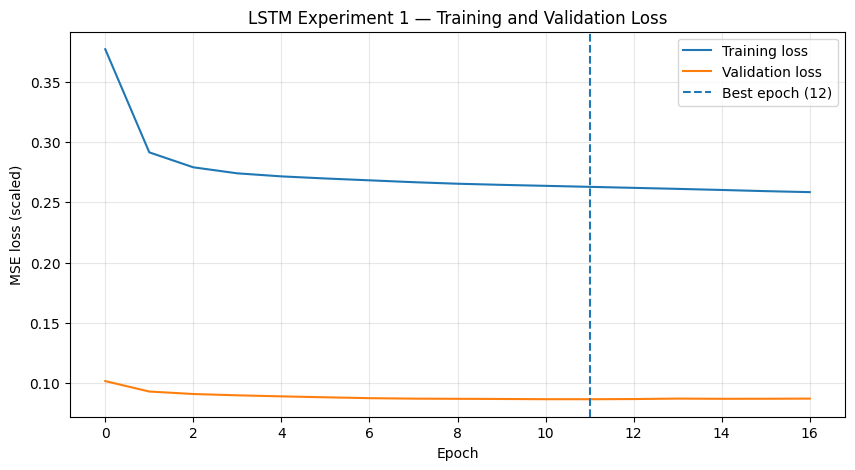

In [ ]:
# ============================================================
# 7.5 LSTM EXPERIMENT 1 — LEARNING CURVES
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_lstm_exp1.history["loss"],
    label="Training loss"
)

plt.plot(
    history_lstm_exp1.history["val_loss"],
    label="Validation loss"
)

plt.axvline(
    best_epoch_exp1 - 1,
    linestyle="--",
    label=f"Best epoch ({best_epoch_exp1})"
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss (scaled)")
plt.title(
    "LSTM Experiment 1 — Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# 7.6 LSTM EXPERIMENT 1 — VALIDATION EVALUATION
# ============================================================

prediction_start_exp1 = time.perf_counter()

val_predictions_scaled_exp1 = (
    model_lstm_exp1.predict(
        lstm_data_2404["X_val"],
        verbose=0
    )
    .reshape(-1)
)

prediction_time_exp1 = (
    time.perf_counter()
    - prediction_start_exp1
)


# ------------------------------------------------------------
# Convert predictions back to original traffic units
# ------------------------------------------------------------

val_predictions_exp1 = (
    lstm_data_2404["scaler"]
    .inverse_transform(
        val_predictions_scaled_exp1.reshape(-1, 1)
    )
    .reshape(-1)
)


# Validation targets back to original units
val_actual_exp1 = (
    lstm_data_2404["scaler"]
    .inverse_transform(
        lstm_data_2404["y_val"].reshape(-1, 1)
    )
    .reshape(-1)
)


# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert (
    len(val_predictions_exp1)
    == len(val_actual_exp1)
)

assert np.isfinite(
    val_predictions_exp1
).all()

assert np.isfinite(
    val_actual_exp1
).all()


# ------------------------------------------------------------
# Original-scale metrics
# ------------------------------------------------------------

lstm_exp1_metrics = evaluate_forecast(
    val_actual_exp1,
    val_predictions_exp1
)


print("=" * 65)
print("LSTM EXPERIMENT 1 — VALIDATION RESULTS")
print("=" * 65)

print(
    "Area: Low / stable "
    "(Square 2404)"
)

print(
    f"Predictions generated: "
    f"{len(val_predictions_exp1)}"
)

print(
    f"Prediction time: "
    f"{prediction_time_exp1:.4f} seconds"
)

print("\nValidation metrics:")

for metric, value in lstm_exp1_metrics.items():
    print(
        f"{metric}: {value:.4f}"
    )

LSTM EXPERIMENT 1 — VALIDATION RESULTS
Area: Low / stable (Square 2404)
Predictions generated: 1339
Prediction time: 0.4768 seconds

Validation metrics:
MAE: 0.9949
RMSE: 1.3177
sMAPE (%): 8.2635


In [ ]:
# ============================================================
# LSTM EXPERIMENT 1 — BENCHMARK COMPARISON
# ============================================================

lstm_exp1_comparison = pd.DataFrame({
    "Model": [
        "Persistence",
        "Fourier-ARIMA",
        "LSTM Experiment 1"
    ],

    "MAE": [
        baseline_row["MAE"],
        experiment_2_metrics["MAE"],
        lstm_exp1_metrics["MAE"]
    ],

    "RMSE": [
        baseline_row["RMSE"],
        experiment_2_metrics["RMSE"],
        lstm_exp1_metrics["RMSE"]
    ],

    "sMAPE (%)": [
        baseline_row["sMAPE (%)"],
        experiment_2_metrics["sMAPE (%)"],
        lstm_exp1_metrics["sMAPE (%)"]
    ]
})


lstm_exp1_comparison[
    "RMSE improvement vs persistence (%)"
] = (
    (
        baseline_row["RMSE"]
        - lstm_exp1_comparison["RMSE"]
    )
    / baseline_row["RMSE"]
    * 100
)


display(
    lstm_exp1_comparison.round(4)
)

,Model,MAE,RMSE,sMAPE (%),RMSE improvement vs persistence (%)
0,Persistence,1.1396,1.4875,9.5622,0.0000
1,Fourier-ARIMA,7.2971,9.5456,14.1176,-541.7025
2,LSTM Experiment 1,0.9949,1.3177,8.2635,11.4173


#### LSTM Experiment 1: Training Behaviour

The baseline LSTM used a 144-step (24-hour) input window and 32 hidden units, resulting in 4,385 trainable parameters. Training was performed chronologically without shuffling and used early stopping based on validation MSE.

Training stopped after 17 epochs and restored the weights from epoch 12, where the minimum scaled validation MSE was 0.086725. Validation loss initially decreased consistently before plateauing after approximately 10–12 epochs. Continuing training beyond this point did not improve validation performance, demonstrating the usefulness of early stopping for limiting unnecessary training and potential overfitting.

All forecasting metrics are subsequently calculated after transforming predictions back to the original traffic scale so that results are directly comparable with the persistence and statistical forecasting models.

#### LSTM Experiment 1: Validation Performance

The baseline LSTM substantially improved forecasting performance for the low/stable area. It achieved an MAE of 0.9949, RMSE of 1.3177, and sMAPE of 8.2635%.

Compared with the persistence baseline, the LSTM reduced RMSE by approximately 11.42% and MAE by approximately 12.7%. It also reduced sMAPE from 9.5622% to 8.2635%.

This is particularly notable because persistence was already a strong benchmark for this area due to the high short-term autocorrelation observed during exploratory analysis. The LSTM therefore demonstrates that the previous 24 hours contain additional predictive structure beyond simply repeating the immediately preceding observation.

The LSTM also substantially outperformed the selected Fourier-ARIMA configuration for this area. This suggests that nonlinear sequence modelling is better able to exploit the short-term temporal structure of the low/stable traffic series.

The baseline model therefore provides a strong starting configuration for further LSTM experimentation.

In [ ]:
# ============================================================
# 7.7 LSTM EXPERIMENT 2
# Increase hidden units: 32 -> 64
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

LSTM_UNITS_EXP2 = 64
LEARNING_RATE_EXP2 = 0.001
BATCH_SIZE_EXP2 = 32
MAX_EPOCHS_EXP2 = 50


model_lstm_exp2 = Sequential([

    Input(
        shape=(LOOKBACK, 1)
    ),

    LSTM(
        LSTM_UNITS_EXP2
    ),

    Dense(1)
])


optimizer_exp2 = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE_EXP2
)


model_lstm_exp2.compile(
    optimizer=optimizer_exp2,
    loss="mse"
)


model_lstm_exp2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("=" * 60)
print("LSTM EXPERIMENT 2")
print("=" * 60)

print("Change from Experiment 1:")
print("LSTM units: 32 -> 64")

print(
    f"\nLookback: {LOOKBACK} steps "
    f"({LOOKBACK * 10 / 60:.1f} hours)"
)

print(
    f"LSTM units: {LSTM_UNITS_EXP2}"
)

print(
    f"Learning rate: "
    f"{LEARNING_RATE_EXP2}"
)

print(
    f"Batch size: "
    f"{BATCH_SIZE_EXP2}"
)

print(
    f"Maximum epochs: "
    f"{MAX_EPOCHS_EXP2}"
)

print(
    f"Total parameters: "
    f"{model_lstm_exp2.count_params():,}"
)

LSTM EXPERIMENT 2
Change from Experiment 1:
LSTM units: 32 -> 64

Lookback: 144 steps (24.0 hours)
LSTM units: 64
Learning rate: 0.001
Batch size: 32
Maximum epochs: 50
Total parameters: 16,961


In [ ]:
# ============================================================
# 7.8 TRAIN LSTM EXPERIMENT 2
# ============================================================

early_stopping_exp2 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

training_start_exp2 = time.perf_counter()

history_lstm_exp2 = model_lstm_exp2.fit(
    lstm_data_2404["X_train"],
    lstm_data_2404["y_train"],

    validation_data=(
        lstm_data_2404["X_val"],
        lstm_data_2404["y_val"]
    ),

    epochs=MAX_EPOCHS_EXP2,
    batch_size=BATCH_SIZE_EXP2,

    callbacks=[
        early_stopping_exp2
    ],

    shuffle=False,
    verbose=1
)

training_time_exp2 = (
    time.perf_counter()
    - training_start_exp2
)


best_epoch_exp2 = (
    np.argmin(
        history_lstm_exp2.history["val_loss"]
    ) + 1
)

best_val_loss_exp2 = np.min(
    history_lstm_exp2.history["val_loss"]
)


print("\n" + "=" * 60)
print("LSTM EXPERIMENT 2 — TRAINING SUMMARY")
print("=" * 60)

print(
    f"Epochs completed: "
    f"{len(history_lstm_exp2.history['loss'])}"
)

print(
    f"Best epoch: "
    f"{best_epoch_exp2}"
)

print(
    f"Best validation MSE (scaled): "
    f"{best_val_loss_exp2:.6f}"
)

print(
    f"Training time: "
    f"{training_time_exp2:.2f} seconds"
)

Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3552 - val_loss: 0.1017
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2918 - val_loss: 0.0943
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2798 - val_loss: 0.0914
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.2742 - val_loss: 0.0893
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2709 - val_loss: 0.0884
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2686 - val_loss: 0.0879
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2670 - val_loss: 0.0877
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2657 - val_loss: 0.0877
Epoch 9/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2646 - val_loss: 0.0882
Epoch 10/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2637 - val_loss: 0.0882
Epoch 11/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.2628 - val_loss: 0.0880
Epoch 12/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/

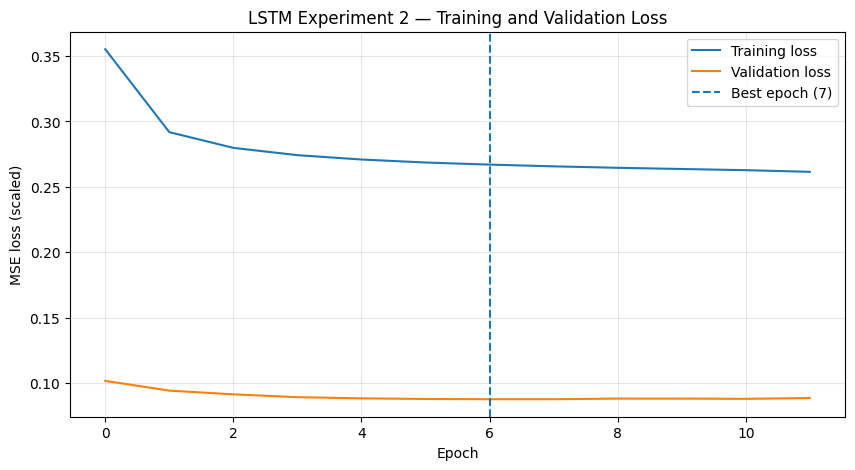

In [ ]:
# ============================================================
# LSTM EXPERIMENT 2 — LEARNING CURVES
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_lstm_exp2.history["loss"],
    label="Training loss"
)

plt.plot(
    history_lstm_exp2.history["val_loss"],
    label="Validation loss"
)

plt.axvline(
    best_epoch_exp2 - 1,
    linestyle="--",
    label=f"Best epoch ({best_epoch_exp2})"
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss (scaled)")

plt.title(
    "LSTM Experiment 2 — Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# 7.9 LSTM EXPERIMENT 2 — VALIDATION EVALUATION
# ============================================================

prediction_start_exp2 = time.perf_counter()

val_predictions_scaled_exp2 = (
    model_lstm_exp2.predict(
        lstm_data_2404["X_val"],
        verbose=0
    )
    .reshape(-1)
)

prediction_time_exp2 = (
    time.perf_counter()
    - prediction_start_exp2
)


# Convert predictions back to original traffic units
val_predictions_exp2 = (
    lstm_data_2404["scaler"]
    .inverse_transform(
        val_predictions_scaled_exp2.reshape(-1, 1)
    )
    .reshape(-1)
)


# Actual validation targets in original units
val_actual_exp2 = (
    lstm_data_2404["scaler"]
    .inverse_transform(
        lstm_data_2404["y_val"].reshape(-1, 1)
    )
    .reshape(-1)
)


assert len(val_predictions_exp2) == len(val_actual_exp2)
assert np.isfinite(val_predictions_exp2).all()


lstm_exp2_metrics = evaluate_forecast(
    val_actual_exp2,
    val_predictions_exp2
)


print("=" * 65)
print("LSTM EXPERIMENT 2 — VALIDATION RESULTS")
print("=" * 65)

print("Area: Low / stable (Square 2404)")

print(
    f"Predictions generated: "
    f"{len(val_predictions_exp2)}"
)

print(
    f"Prediction time: "
    f"{prediction_time_exp2:.4f} seconds"
)

print("\nValidation metrics:")

for metric, value in lstm_exp2_metrics.items():
    print(f"{metric}: {value:.4f}")

LSTM EXPERIMENT 2 — VALIDATION RESULTS
Area: Low / stable (Square 2404)
Predictions generated: 1339
Prediction time: 0.4606 seconds

Validation metrics:
MAE: 0.9960
RMSE: 1.3250
sMAPE (%): 8.2682


In [ ]:
# ============================================================
# LSTM EXPERIMENT COMPARISON
# ============================================================

lstm_experiment_comparison = pd.DataFrame({
    "Experiment": [
        "Persistence",
        "LSTM Exp 1",
        "LSTM Exp 2"
    ],

    "Units": [
        None,
        32,
        64
    ],

    "Lookback": [
        1,
        144,
        144
    ],

    "Parameters": [
        0,
        model_lstm_exp1.count_params(),
        model_lstm_exp2.count_params()
    ],

    "MAE": [
        baseline_row["MAE"],
        lstm_exp1_metrics["MAE"],
        lstm_exp2_metrics["MAE"]
    ],

    "RMSE": [
        baseline_row["RMSE"],
        lstm_exp1_metrics["RMSE"],
        lstm_exp2_metrics["RMSE"]
    ],

    "sMAPE (%)": [
        baseline_row["sMAPE (%)"],
        lstm_exp1_metrics["sMAPE (%)"],
        lstm_exp2_metrics["sMAPE (%)"]
    ]
})


lstm_experiment_comparison[
    "RMSE improvement vs persistence (%)"
] = (
    (
        baseline_row["RMSE"]
        - lstm_experiment_comparison["RMSE"]
    )
    / baseline_row["RMSE"]
    * 100
)


display(
    lstm_experiment_comparison.round(4)
)

,Experiment,Units,Lookback,Parameters,MAE,RMSE,sMAPE (%),RMSE improvement vs persistence (%)
0,Persistence,NaN,1,0,1.1396,1.4875,9.5622,0.0000
1,LSTM Exp 1,32.0,144,4385,0.9949,1.3177,8.2635,11.4173
2,LSTM Exp 2,64.0,144,16961,0.9960,1.3250,8.2682,10.9259


#### LSTM Experiment 2: Increasing Hidden Units

Experiment 2 increased the number of LSTM hidden units from 32 to 64 while keeping the 144-step lookback, learning rate, batch size, and training procedure unchanged.

The larger model increased the number of trainable parameters from 4,385 to 16,961. However, validation performance did not improve. Experiment 2 achieved an MAE of 0.9960, RMSE of 1.3250, and sMAPE of 8.2682%, compared with 0.9949, 1.3177, and 8.2635% respectively for the smaller 32-unit model.

The 64-unit model also reached its best validation loss earlier, at epoch 7, compared with epoch 12 for Experiment 1. Increasing hidden capacity therefore provided no forecasting benefit despite substantially increasing model complexity.

Experiment 1 remains the preferred architecture at this stage. The next experiment investigates whether the amount of historical context, rather than hidden-state capacity, has a greater influence on forecasting performance.

In [ ]:
# ============================================================
# 7.10 LSTM EXPERIMENT 3
# Lookback: 144 -> 72 steps
# ============================================================

LOOKBACK_EXP3 = 72

lstm_data_2404_exp3 = prepare_lstm_data(
    area_id=2404,
    lookback=LOOKBACK_EXP3
)

print("=" * 60)
print("LSTM EXPERIMENT 3 — DATA")
print("=" * 60)

print(
    f"Lookback: {LOOKBACK_EXP3} steps "
    f"({LOOKBACK_EXP3 * 10 / 60:.1f} hours)"
)

print(
    "X_train:",
    lstm_data_2404_exp3["X_train"].shape
)

print(
    "y_train:",
    lstm_data_2404_exp3["y_train"].shape
)

print(
    "X_val:",
    lstm_data_2404_exp3["X_val"].shape
)

print(
    "y_val:",
    lstm_data_2404_exp3["y_val"].shape
)

assert (
    len(lstm_data_2404_exp3["y_val"])
    == val_end - train_end
)

print("\nValidation target count: correct")

LSTM EXPERIMENT 3 — DATA
Lookback: 72 steps (12.0 hours)
X_train: (6177, 72, 1)
y_train: (6177,)
X_val: (1339, 72, 1)
y_val: (1339,)

Validation target count: correct


In [ ]:
# ============================================================
# LSTM EXPERIMENT 3 — MODEL
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

LSTM_UNITS_EXP3 = 32
LEARNING_RATE_EXP3 = 0.001
BATCH_SIZE_EXP3 = 32
MAX_EPOCHS_EXP3 = 50


model_lstm_exp3 = Sequential([

    Input(
        shape=(LOOKBACK_EXP3, 1)
    ),

    LSTM(
        LSTM_UNITS_EXP3
    ),

    Dense(1)
])


model_lstm_exp3.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_EXP3
    ),
    loss="mse"
)


model_lstm_exp3.summary()


print("\n" + "=" * 60)
print("LSTM EXPERIMENT 3")
print("=" * 60)

print("Change from Experiment 1:")
print("Lookback: 144 -> 72 steps")

print(
    f"\nHistory represented: "
    f"{LOOKBACK_EXP3 * 10 / 60:.1f} hours"
)

print(
    f"LSTM units: "
    f"{LSTM_UNITS_EXP3}"
)

print(
    f"Learning rate: "
    f"{LEARNING_RATE_EXP3}"
)

print(
    f"Batch size: "
    f"{BATCH_SIZE_EXP3}"
)

print(
    f"Total parameters: "
    f"{model_lstm_exp3.count_params():,}"
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)


LSTM EXPERIMENT 3
Change from Experiment 1:
Lookback: 144 -> 72 steps

History represented: 12.0 hours
LSTM units: 32
Learning rate: 0.001
Batch size: 32
Total parameters: 4,385


In [ ]:
# ============================================================
# 7.11 TRAIN LSTM EXPERIMENT 3
# 32 units, 72-step lookback
# ============================================================

early_stopping_exp3 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

training_start_exp3 = time.perf_counter()

history_lstm_exp3 = model_lstm_exp3.fit(
    lstm_data_2404_exp3["X_train"],
    lstm_data_2404_exp3["y_train"],

    validation_data=(
        lstm_data_2404_exp3["X_val"],
        lstm_data_2404_exp3["y_val"]
    ),

    epochs=MAX_EPOCHS_EXP3,
    batch_size=BATCH_SIZE_EXP3,

    callbacks=[
        early_stopping_exp3
    ],

    shuffle=False,
    verbose=1
)

training_time_exp3 = (
    time.perf_counter()
    - training_start_exp3
)

best_epoch_exp3 = (
    np.argmin(
        history_lstm_exp3.history["val_loss"]
    ) + 1
)

best_val_loss_exp3 = np.min(
    history_lstm_exp3.history["val_loss"]
)

print("\n" + "=" * 60)
print("LSTM EXPERIMENT 3 — TRAINING SUMMARY")
print("=" * 60)

print(
    f"Epochs completed: "
    f"{len(history_lstm_exp3.history['loss'])}"
)

print(
    f"Best epoch: "
    f"{best_epoch_exp3}"
)

print(
    f"Best validation MSE (scaled): "
    f"{best_val_loss_exp3:.6f}"
)

print(
    f"Training time: "
    f"{training_time_exp3:.2f} seconds"
)

Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3694 - val_loss: 0.1015
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2894 - val_loss: 0.0931
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2777 - val_loss: 0.0914
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2730 - val_loss: 0.0904
Epoch 5/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2706 - val_loss: 0.0895
Epoch 6/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2688 - val_loss: 0.0886
Epoch 7/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2671 - val_loss: 0.0879
Epoch 8/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2658 - val_loss: 0.0875
Epoch 9/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2647 - val_loss: 0.0873
Epoch 10/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2638 - val_loss: 0.0873
Epoch 11/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2629 - val_loss: 0.0873
Epoch 12/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/ste

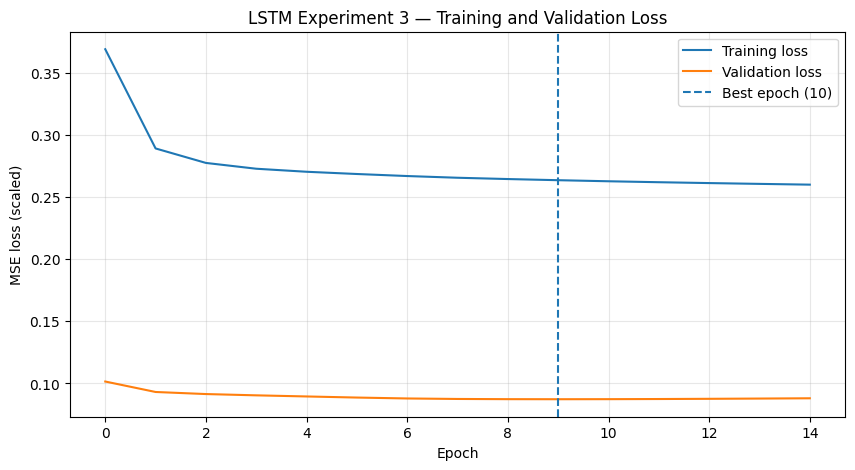

In [ ]:
# ============================================================
# LSTM EXPERIMENT 3 — LEARNING CURVES
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_lstm_exp3.history["loss"],
    label="Training loss"
)

plt.plot(
    history_lstm_exp3.history["val_loss"],
    label="Validation loss"
)

plt.axvline(
    best_epoch_exp3 - 1,
    linestyle="--",
    label=f"Best epoch ({best_epoch_exp3})"
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss (scaled)")

plt.title(
    "LSTM Experiment 3 — Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# 7.12 LSTM EXPERIMENT 3 — VALIDATION EVALUATION
# ============================================================

prediction_start_exp3 = time.perf_counter()

val_predictions_scaled_exp3 = (
    model_lstm_exp3.predict(
        lstm_data_2404_exp3["X_val"],
        verbose=0
    )
    .reshape(-1)
)

prediction_time_exp3 = (
    time.perf_counter()
    - prediction_start_exp3
)


# ------------------------------------------------------------
# Inverse transform predictions
# ------------------------------------------------------------

val_predictions_exp3 = (
    lstm_data_2404_exp3["scaler"]
    .inverse_transform(
        val_predictions_scaled_exp3.reshape(-1, 1)
    )
    .reshape(-1)
)


val_actual_exp3 = (
    lstm_data_2404_exp3["scaler"]
    .inverse_transform(
        lstm_data_2404_exp3["y_val"].reshape(-1, 1)
    )
    .reshape(-1)
)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert (
    len(val_predictions_exp3)
    == len(val_actual_exp3)
)

assert np.isfinite(
    val_predictions_exp3
).all()


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

lstm_exp3_metrics = evaluate_forecast(
    val_actual_exp3,
    val_predictions_exp3
)


print("=" * 65)
print("LSTM EXPERIMENT 3 — VALIDATION RESULTS")
print("=" * 65)

print(
    "Area: Low / stable "
    "(Square 2404)"
)

print(
    f"Lookback: {LOOKBACK_EXP3} steps "
    f"({LOOKBACK_EXP3 * 10 / 60:.1f} hours)"
)

print(
    f"Predictions generated: "
    f"{len(val_predictions_exp3)}"
)

print(
    f"Prediction time: "
    f"{prediction_time_exp3:.4f} seconds"
)

print("\nValidation metrics:")

for metric, value in lstm_exp3_metrics.items():
    print(
        f"{metric}: {value:.4f}"
    )

LSTM EXPERIMENT 3 — VALIDATION RESULTS
Area: Low / stable (Square 2404)
Lookback: 72 steps (12.0 hours)
Predictions generated: 1339
Prediction time: 0.3533 seconds

Validation metrics:
MAE: 1.0003
RMSE: 1.3217
sMAPE (%): 8.3113


In [ ]:
# ============================================================
# LSTM EXPERIMENTS 1–3 COMPARISON
# ============================================================

lstm_experiment_comparison = pd.DataFrame({

    "Experiment": [
        "Persistence",
        "LSTM Exp 1",
        "LSTM Exp 2",
        "LSTM Exp 3"
    ],

    "Units": [
        None,
        32,
        64,
        32
    ],

    "Lookback": [
        1,
        144,
        144,
        72
    ],

    "History (hours)": [
        10 / 60,
        24,
        24,
        12
    ],

    "Parameters": [
        0,
        model_lstm_exp1.count_params(),
        model_lstm_exp2.count_params(),
        model_lstm_exp3.count_params()
    ],

    "MAE": [
        baseline_row["MAE"],
        lstm_exp1_metrics["MAE"],
        lstm_exp2_metrics["MAE"],
        lstm_exp3_metrics["MAE"]
    ],

    "RMSE": [
        baseline_row["RMSE"],
        lstm_exp1_metrics["RMSE"],
        lstm_exp2_metrics["RMSE"],
        lstm_exp3_metrics["RMSE"]
    ],

    "sMAPE (%)": [
        baseline_row["sMAPE (%)"],
        lstm_exp1_metrics["sMAPE (%)"],
        lstm_exp2_metrics["sMAPE (%)"],
        lstm_exp3_metrics["sMAPE (%)"]
    ]
})


lstm_experiment_comparison[
    "RMSE improvement vs persistence (%)"
] = (
    (
        baseline_row["RMSE"]
        - lstm_experiment_comparison["RMSE"]
    )
    / baseline_row["RMSE"]
    * 100
)


display(
    lstm_experiment_comparison.round(4)
)

,Experiment,Units,Lookback,History (hours),Parameters,MAE,RMSE,sMAPE (%),RMSE improvement vs persistence (%)
0,Persistence,NaN,1,0.1667,0,1.1396,1.4875,9.5622,0.0000
1,LSTM Exp 1,32.0,144,24.0000,4385,0.9949,1.3177,8.2635,11.4173
2,LSTM Exp 2,64.0,144,24.0000,16961,0.9960,1.3250,8.2682,10.9259
3,LSTM Exp 3,32.0,72,12.0000,4385,1.0003,1.3217,8.3113,11.1462


#### LSTM Experiment 3: Reducing the Lookback Window

Experiment 3 reduced the input lookback from 144 observations (24 hours) to 72 observations (12 hours), while retaining the 32-unit LSTM architecture.

The shorter lookback achieved an MAE of 1.0003, RMSE of 1.3217, and sMAPE of 8.3113%. These results were slightly worse than Experiment 1, which achieved an MAE of 0.9949, RMSE of 1.3177, and sMAPE of 8.2635%.

The difference in forecasting accuracy was relatively small. However, reducing the sequence length decreased training time from approximately 34.55 seconds to 22.40 seconds and prediction time from approximately 0.48 seconds to 0.35 seconds.

This indicates an accuracy-computation trade-off: a 12-hour history provides nearly the same forecasting performance at lower computational cost, while the full 24-hour history provides the best validation accuracy. Since predictive performance is the primary model-selection criterion, the 144-step lookback is retained for subsequent experiments.

In [ ]:
# ============================================================
# 7.13 LSTM EXPERIMENT 4
# Learning rate: 0.001 -> 0.0005
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

LSTM_UNITS_EXP4 = 32
LOOKBACK_EXP4 = 144
LEARNING_RATE_EXP4 = 0.0005
BATCH_SIZE_EXP4 = 32
MAX_EPOCHS_EXP4 = 50


model_lstm_exp4 = Sequential([

    Input(
        shape=(LOOKBACK_EXP4, 1)
    ),

    LSTM(
        LSTM_UNITS_EXP4
    ),

    Dense(1)
])


model_lstm_exp4.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_EXP4
    ),
    loss="mse"
)


model_lstm_exp4.summary()


print("\n" + "=" * 60)
print("LSTM EXPERIMENT 4")
print("=" * 60)

print("Change from Experiment 1:")
print("Learning rate: 0.001 -> 0.0005")

print(
    f"\nLookback: {LOOKBACK_EXP4} steps "
    f"({LOOKBACK_EXP4 * 10 / 60:.1f} hours)"
)

print(
    f"LSTM units: {LSTM_UNITS_EXP4}"
)

print(
    f"Learning rate: {LEARNING_RATE_EXP4}"
)

print(
    f"Batch size: {BATCH_SIZE_EXP4}"
)

print(
    f"Total parameters: "
    f"{model_lstm_exp4.count_params():,}"
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)


LSTM EXPERIMENT 4
Change from Experiment 1:
Learning rate: 0.001 -> 0.0005

Lookback: 144 steps (24.0 hours)
LSTM units: 32
Learning rate: 0.0005
Batch size: 32
Total parameters: 4,385


In [ ]:
# ============================================================
# 7.14 TRAIN LSTM EXPERIMENT 4
# 32 units, 144-step lookback, LR=0.0005
# ============================================================

early_stopping_exp4 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

training_start_exp4 = time.perf_counter()

history_lstm_exp4 = model_lstm_exp4.fit(
    lstm_data_2404["X_train"],
    lstm_data_2404["y_train"],

    validation_data=(
        lstm_data_2404["X_val"],
        lstm_data_2404["y_val"]
    ),

    epochs=MAX_EPOCHS_EXP4,
    batch_size=BATCH_SIZE_EXP4,

    callbacks=[
        early_stopping_exp4
    ],

    shuffle=False,
    verbose=1
)

training_time_exp4 = (
    time.perf_counter()
    - training_start_exp4
)


best_epoch_exp4 = (
    np.argmin(
        history_lstm_exp4.history["val_loss"]
    ) + 1
)

best_val_loss_exp4 = np.min(
    history_lstm_exp4.history["val_loss"]
)


print("\n" + "=" * 60)
print("LSTM EXPERIMENT 4 — TRAINING SUMMARY")
print("=" * 60)

print(
    f"Epochs completed: "
    f"{len(history_lstm_exp4.history['loss'])}"
)

print(
    f"Best epoch: "
    f"{best_epoch_exp4}"
)

print(
    f"Best validation MSE (scaled): "
    f"{best_val_loss_exp4:.6f}"
)

print(
    f"Training time: "
    f"{training_time_exp4:.2f} seconds"
)

Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.4509 - val_loss: 0.1186
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3108 - val_loss: 0.1034
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2941 - val_loss: 0.0978
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2840 - val_loss: 0.0942
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2780 - val_loss: 0.0920
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2746 - val_loss: 0.0908
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2725 - val_loss: 0.0900
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2711 - val_loss: 0.0894
Epoch 9/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2700 - val_loss: 0.0889
Epoch 10/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.2690 - val_loss: 0.0884
Epoch 11/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2680 - val_loss: 0.0881
Epoch 12/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/s

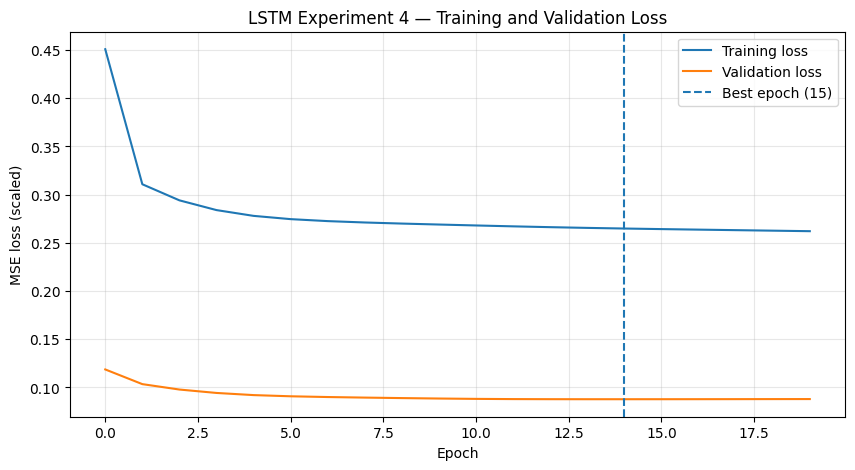

In [ ]:
# ============================================================
# LSTM EXPERIMENT 4 — LEARNING CURVES
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_lstm_exp4.history["loss"],
    label="Training loss"
)

plt.plot(
    history_lstm_exp4.history["val_loss"],
    label="Validation loss"
)

plt.axvline(
    best_epoch_exp4 - 1,
    linestyle="--",
    label=f"Best epoch ({best_epoch_exp4})"
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss (scaled)")

plt.title(
    "LSTM Experiment 4 — Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# 7.15 LSTM EXPERIMENT 4 — VALIDATION EVALUATION
# ============================================================

prediction_start_exp4 = time.perf_counter()

val_predictions_scaled_exp4 = (
    model_lstm_exp4.predict(
        lstm_data_2404["X_val"],
        verbose=0
    )
    .reshape(-1)
)

prediction_time_exp4 = (
    time.perf_counter()
    - prediction_start_exp4
)


# Convert predictions to original traffic scale
val_predictions_exp4 = (
    lstm_data_2404["scaler"]
    .inverse_transform(
        val_predictions_scaled_exp4.reshape(-1, 1)
    )
    .reshape(-1)
)

val_actual_exp4 = (
    lstm_data_2404["scaler"]
    .inverse_transform(
        lstm_data_2404["y_val"].reshape(-1, 1)
    )
    .reshape(-1)
)


assert len(val_predictions_exp4) == len(val_actual_exp4)
assert np.isfinite(val_predictions_exp4).all()


lstm_exp4_metrics = evaluate_forecast(
    val_actual_exp4,
    val_predictions_exp4
)


print("=" * 65)
print("LSTM EXPERIMENT 4 — VALIDATION RESULTS")
print("=" * 65)

print("Area: Low / stable (Square 2404)")
print("Learning rate: 0.0005")

print(
    f"Predictions generated: "
    f"{len(val_predictions_exp4)}"
)

print(
    f"Prediction time: "
    f"{prediction_time_exp4:.4f} seconds"
)

print("\nValidation metrics:")

for metric, value in lstm_exp4_metrics.items():
    print(f"{metric}: {value:.4f}")

LSTM EXPERIMENT 4 — VALIDATION RESULTS
Area: Low / stable (Square 2404)
Learning rate: 0.0005
Predictions generated: 1339
Prediction time: 0.4935 seconds

Validation metrics:
MAE: 1.0138
RMSE: 1.3253
sMAPE (%): 8.4722


In [ ]:
# ============================================================
# LSTM EXPERIMENTS 1–4 COMPARISON
# ============================================================

lstm_experiment_comparison = pd.DataFrame({

    "Experiment": [
        "Persistence",
        "LSTM Exp 1",
        "LSTM Exp 2",
        "LSTM Exp 3",
        "LSTM Exp 4"
    ],

    "Units": [
        None,
        32,
        64,
        32,
        32
    ],

    "Lookback": [
        1,
        144,
        144,
        72,
        144
    ],

    "Learning Rate": [
        None,
        0.001,
        0.001,
        0.001,
        0.0005
    ],

    "Parameters": [
        0,
        model_lstm_exp1.count_params(),
        model_lstm_exp2.count_params(),
        model_lstm_exp3.count_params(),
        model_lstm_exp4.count_params()
    ],

    "MAE": [
        baseline_row["MAE"],
        lstm_exp1_metrics["MAE"],
        lstm_exp2_metrics["MAE"],
        lstm_exp3_metrics["MAE"],
        lstm_exp4_metrics["MAE"]
    ],

    "RMSE": [
        baseline_row["RMSE"],
        lstm_exp1_metrics["RMSE"],
        lstm_exp2_metrics["RMSE"],
        lstm_exp3_metrics["RMSE"],
        lstm_exp4_metrics["RMSE"]
    ],

    "sMAPE (%)": [
        baseline_row["sMAPE (%)"],
        lstm_exp1_metrics["sMAPE (%)"],
        lstm_exp2_metrics["sMAPE (%)"],
        lstm_exp3_metrics["sMAPE (%)"],
        lstm_exp4_metrics["sMAPE (%)"]
    ]
})


lstm_experiment_comparison[
    "RMSE improvement vs persistence (%)"
] = (
    (
        baseline_row["RMSE"]
        - lstm_experiment_comparison["RMSE"]
    )
    / baseline_row["RMSE"]
    * 100
)


display(
    lstm_experiment_comparison.round(4)
)

,Experiment,Units,Lookback,Learning Rate,Parameters,MAE,RMSE,sMAPE (%),RMSE improvement vs persistence (%)
0,Persistence,NaN,1,NaN,0,1.1396,1.4875,9.5622,0.0000
1,LSTM Exp 1,32.0,144,0.0010,4385,0.9949,1.3177,8.2635,11.4173
2,LSTM Exp 2,64.0,144,0.0010,16961,0.9960,1.3250,8.2682,10.9259
3,LSTM Exp 3,32.0,72,0.0010,4385,1.0003,1.3217,8.3113,11.1462
4,LSTM Exp 4,32.0,144,0.0005,4385,1.0138,1.3253,8.4722,10.9091


#### LSTM Experiment 4: Learning Rate

Experiment 4 reduced the Adam learning rate from 0.001 to 0.0005 while retaining the 32-unit architecture and 144-step input window.

The lower learning rate produced a best scaled validation MSE of 0.087723 at epoch 15, compared with 0.086725 at epoch 12 for Experiment 1. Training also required more epochs before early stopping, indicating slower convergence without improved validation performance.

These results suggest that reducing the learning rate does not provide an advantage for the current architecture and dataset. The original learning rate of 0.001 is therefore retained.

### LSTM Hyperparameter Selection

Four controlled LSTM experiments were conducted on the low/stable development area (Square 2404). Experiment 1 used 32 LSTM units, a 144-step (24-hour) lookback, a learning rate of 0.001, and batch size 32. Subsequent experiments changed one major factor at a time.

Increasing the hidden-state size from 32 to 64 units increased the number of trainable parameters from 4,385 to 16,961 but slightly worsened validation performance. Reducing the lookback window from 144 to 72 observations lowered computational cost but also produced slightly higher forecasting errors. Finally, reducing the learning rate from 0.001 to 0.0005 resulted in slower convergence and higher validation error.

Experiment 1 therefore produced the best overall validation performance, with an MAE of 0.9949, RMSE of 1.3177, and sMAPE of 8.2635%. It improved RMSE by approximately 11.42% relative to persistence.

The selected LSTM configuration is therefore:

- Lookback window: 144 observations (24 hours)
- LSTM units: 32
- Learning rate: 0.001
- Batch size: 32
- Optimizer: Adam
- Loss function: mean squared error
- Early stopping patience: 5 epochs

No further LSTM hyperparameter adjustments are made after this selection to avoid tuning excessively to the validation data.

In [ ]:
# ============================================================
# 7.16 REUSABLE LSTM CROSS-AREA VALIDATION
# ============================================================

def validate_selected_lstm(
    area_id,
    profile,
    lookback=144,
    units=32,
    learning_rate=0.001,
    batch_size=32,
    max_epochs=50
):

    # --------------------------------------------------------
    # Prepare area-specific data
    # Scaler is fitted ONLY on this area's training data
    # --------------------------------------------------------

    data = prepare_lstm_data(
        area_id=area_id,
        lookback=lookback
    )


    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)


    # --------------------------------------------------------
    # Selected architecture
    # --------------------------------------------------------

    model = Sequential([

        Input(
            shape=(lookback, 1)
        ),

        LSTM(
            units
        ),

        Dense(1)
    ])


    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="mse"
    )


    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode="min",
        verbose=0
    )


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    training_start = time.perf_counter()

    history = model.fit(
        data["X_train"],
        data["y_train"],

        validation_data=(
            data["X_val"],
            data["y_val"]
        ),

        epochs=max_epochs,
        batch_size=batch_size,

        callbacks=[
            early_stopping
        ],

        shuffle=False,
        verbose=0
    )

    training_time = (
        time.perf_counter()
        - training_start
    )


    best_epoch = (
        np.argmin(
            history.history["val_loss"]
        ) + 1
    )

    best_val_loss = np.min(
        history.history["val_loss"]
    )


    # --------------------------------------------------------
    # Validation predictions
    # --------------------------------------------------------

    prediction_start = time.perf_counter()

    predictions_scaled = (
        model.predict(
            data["X_val"],
            verbose=0
        )
        .reshape(-1)
    )

    prediction_time = (
        time.perf_counter()
        - prediction_start
    )


    # --------------------------------------------------------
    # Return to original traffic scale
    # --------------------------------------------------------

    predictions = (
        data["scaler"]
        .inverse_transform(
            predictions_scaled.reshape(-1, 1)
        )
        .reshape(-1)
    )

    actual = (
        data["scaler"]
        .inverse_transform(
            data["y_val"].reshape(-1, 1)
        )
        .reshape(-1)
    )


    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    metrics = evaluate_forecast(
        actual,
        predictions
    )


    return {

        "profile": profile,
        "square_id": area_id,

        "lookback": lookback,
        "units": units,
        "learning_rate": learning_rate,

        "parameters": model.count_params(),

        "epochs_completed":
            len(history.history["loss"]),

        "best_epoch":
            best_epoch,

        "best_val_mse_scaled":
            best_val_loss,

        "MAE":
            metrics["MAE"],

        "RMSE":
            metrics["RMSE"],

        "sMAPE (%)":
            metrics["sMAPE (%)"],

        "training_time_sec":
            training_time,

        "prediction_time_sec":
            prediction_time
    }

In [ ]:
lstm_medium_result = validate_selected_lstm(
    area_id=6433,
    profile="Medium / moderate",
    lookback=144,
    units=32,
    learning_rate=0.001,
    batch_size=32
)

pd.DataFrame(
    [lstm_medium_result]
).round(4)

,profile,square_id,lookback,units,learning_rate,parameters,epochs_completed,best_epoch,best_val_mse_scaled,MAE,RMSE,sMAPE (%),training_time_sec,prediction_time_sec
0,Medium / moderate,6433,144,32,0.001,4385,32,27,0.1858,4.1152,5.4583,14.2278,57.1969,0.3721


#### LSTM Cross-Area Validation: Medium/Moderate Area

The selected LSTM configuration was applied unchanged to the medium/moderate area (Square 6433). The model achieved an MAE of 4.1152, RMSE of 5.4583, and sMAPE of 14.2278%.

For comparison, the persistence baseline achieved an RMSE of 7.0829, while the selected Fourier-ARIMA model achieved an RMSE of 5.6195. The LSTM therefore reduced RMSE by approximately 22.9% relative to persistence and approximately 2.9% relative to Fourier-ARIMA.

Importantly, the LSTM architecture and hyperparameters were selected using the low/stable development area and were not retuned for Square 6433. The improvement therefore provides evidence that the selected LSTM configuration generalizes across different geographical traffic characteristics.

In [ ]:
# ============================================================
# 7.17 LSTM CROSS-AREA VALIDATION
# HIGH / VARIABLE AREA
# ============================================================

lstm_high_result = validate_selected_lstm(
    area_id=5243,
    profile="High / variable",
    lookback=144,
    units=32,
    learning_rate=0.001,
    batch_size=32
)

pd.DataFrame(
    [lstm_high_result]
).round(4)

,profile,square_id,lookback,units,learning_rate,parameters,epochs_completed,best_epoch,best_val_mse_scaled,MAE,RMSE,sMAPE (%),training_time_sec,prediction_time_sec
0,High / variable,5243,144,32,0.001,4385,50,49,0.007,7.009,9.1777,13.4245,89.9397,0.6906


#### LSTM Cross-Area Validation: High/Variable Area

The selected LSTM configuration was finally applied unchanged to the high/variable traffic area (Square 5243). The model achieved an MAE of 7.0090, RMSE of 9.1777, and sMAPE of 13.4245%.

The persistence baseline produced an RMSE of 11.1448, while the selected Fourier-ARIMA model produced an RMSE of 10.9141. The LSTM therefore reduced RMSE by approximately 17.65% relative to persistence and approximately 15.91% relative to Fourier-ARIMA.

Unlike the lower-traffic areas, training continued for 50 epochs and reached its lowest validation loss at epoch 49. This suggests that the more variable traffic series required substantially more optimization before convergence.

Overall, the same LSTM architecture and hyperparameters selected using Square 2404 produced improvements over persistence across all three geographical traffic profiles without area-specific hyperparameter retuning.

In [ ]:
# ============================================================
# 7.18 FINAL LSTM CROSS-AREA VALIDATION SUMMARY
# ============================================================

lstm_cross_area = pd.DataFrame([

    {
        "Profile": "Low / stable",
        "Square": 2404,
        "MAE": lstm_exp1_metrics["MAE"],
        "RMSE": lstm_exp1_metrics["RMSE"],
        "sMAPE (%)": lstm_exp1_metrics["sMAPE (%)"],
        "Persistence RMSE": 1.487545
    },

    {
        "Profile": "Medium / moderate",
        "Square": 6433,
        "MAE": lstm_medium_result["MAE"],
        "RMSE": lstm_medium_result["RMSE"],
        "sMAPE (%)": lstm_medium_result["sMAPE (%)"],
        "Persistence RMSE": 7.082905
    },

    {
        "Profile": "High / variable",
        "Square": 5243,
        "MAE": lstm_high_result["MAE"],
        "RMSE": lstm_high_result["RMSE"],
        "sMAPE (%)": lstm_high_result["sMAPE (%)"],
        "Persistence RMSE": 11.144783
    }
])

lstm_cross_area[
    "RMSE improvement vs persistence (%)"
] = (
    (
        lstm_cross_area["Persistence RMSE"]
        - lstm_cross_area["RMSE"]
    )
    / lstm_cross_area["Persistence RMSE"]
    * 100
)

display(
    lstm_cross_area.round(4)
)

,Profile,Square,MAE,RMSE,sMAPE (%),Persistence RMSE,RMSE improvement vs persistence (%)
0,Low / stable,2404,0.9949,1.3177,8.2635,1.4875,11.4173
1,Medium / moderate,6433,4.1152,5.4583,14.2278,7.0829,22.9369
2,High / variable,5243,7.0090,9.1777,13.4245,11.1448,17.6506


### LSTM Cross-Area Summary

The selected LSTM configuration generalized successfully across all three geographical traffic profiles without area-specific hyperparameter retuning.

Relative to the persistence baseline, validation RMSE decreased by 11.42% for the low/stable area, 22.94% for the medium/moderate area, and 17.65% for the high/variable area.

The magnitude of the improvement differed across geographical areas, indicating that forecasting performance depends on the underlying traffic characteristics. This directly supports the study's research question, which investigates not only differences between forecasting models but also how their performance varies across areas with different traffic profiles.

These results remain validation results; the held-out test set has not yet been used for final model comparison.

## 7. Related Work and Model Motivation

Mobile network traffic forecasting supports tasks such as capacity planning, resource allocation, and anticipating changes in network demand. The literature also shows that traffic behaviour can differ across geographical cells and that statistical, recurrent, and attention-based models capture different aspects of temporal structure.

Barlacchi et al. [1] describe the Telecom Italia Big Data Challenge dataset used in this study. Milan is divided into geographical grid cells, and telecommunications activity is recorded at 10-minute intervals. This spatial-temporal structure motivates evaluating forecasting behaviour across areas with different traffic characteristics rather than relying on a single city-wide series.

Santos et al. [2] used two months of Telecom Italia Milan data to compare LSTM and GRU recurrent networks with conventional machine-learning models. Their study grouped cells by Internet-activity characteristics and reported variation in predictive performance across traffic groups. This directly motivates the present study's use of an LSTM and its cross-profile evaluation design.

Statistical forecasting provides a complementary, interpretable approach. Kochetkova et al. [6] evaluated SARIMA and Holt-Winters models for short-term mobile-network traffic forecasting, demonstrating the continued relevance of explicitly modeling seasonal temporal structure. In the present dataset, strong daily autocorrelation and STL seasonality similarly motivate a seasonal statistical benchmark. Because an explicit 144-step SARIMA state-space model exceeded the available memory, daily seasonality is represented with Fourier terms while ARIMA models short-term dependence.

The Transformer architecture introduced by Vaswani et al. [3] replaces recurrence with attention-based sequence modeling. Subsequent forecasting research such as Informer [4] demonstrated the potential of attention mechanisms for time-series forecasting while also highlighting the computational cost of standard self-attention for long sequences. Lim et al. [5] further combined attention with recurrent components for interpretable multi-horizon forecasting.

Transformer-based methods have also been applied directly to cellular traffic. Zhang et al. [7] used an inverted Transformer for cellular traffic forecasting and evaluated it on real-world data including the Telecom Italia Milan dataset. Li and Li [8] later proposed a hybrid spatiotemporal LSTM-Transformer architecture for cellular traffic prediction. These studies motivate evaluating an attention-based model alongside a recurrent model, while the present work deliberately uses a simpler univariate setup so that the three forecasting families can be compared under the same one-step information set.

Together, the literature supports the comparison of statistical, recurrent, and attention-based approaches, but does not imply that one family should perform best for every traffic profile. The experiments therefore evaluate both overall accuracy and variation across contrasting geographical traffic characteristics.

### References

[1] G. Barlacchi et al., "A multi-source dataset of urban life in the city of Milan and the Province of Trentino," *Scientific Data*, vol. 2, Art. no. 150055, 2015, doi: 10.1038/sdata.2015.55.

[2] G. L. Santos et al., "Predicting short-term mobile Internet traffic from Internet activity using recurrent neural networks," *International Journal of Network Management*, 2022, doi: 10.1002/nem.2191.

[3] A. Vaswani et al., "Attention Is All You Need," in *Advances in Neural Information Processing Systems*, vol. 30, 2017.

[4] H. Zhou et al., "Informer: Beyond Efficient Transformer for Long Sequence Time-Series Forecasting," in *Proceedings of the AAAI Conference on Artificial Intelligence*, vol. 35, no. 12, pp. 11106–11115, 2021, doi: 10.1609/aaai.v35i12.17325.

[5] B. Lim, S. O. Arik, N. Loeff, and T. Pfister, "Temporal Fusion Transformers for Interpretable Multi-horizon Time Series Forecasting," *International Journal of Forecasting*, vol. 37, no. 4, pp. 1748–1764, 2021, doi: 10.1016/j.ijforecast.2021.03.012.

[6] I. Kochetkova, A. Kushchazli, S. Burtseva, and A. Gorshenin, "Short-Term Mobile Network Traffic Forecasting Using Seasonal ARIMA and Holt-Winters Models," *Future Internet*, vol. 15, no. 9, Art. no. 290, 2023, doi: 10.3390/fi15090290.

[7] J. Zhang, C. Tan, Z. Cai, L. Zhu, Y. Feng, and S. Liang, "Cellular traffic forecasting based on inverted transformer for mobile perception dual-level base station sleep control," *Ad Hoc Networks*, vol. 161, Art. no. 103505, 2024, doi: 10.1016/j.adhoc.2024.103505.

[8] A.-M. Li and J. Li, "A hybrid spatiotemporal LSTM and transformer network for cellular traffic prediction," *Computer Networks*, vol. 272, Art. no. 111669, 2025, doi: 10.1016/j.comnet.2025.111669.

## 8. Transformer Model

## 8.1 Transformer Forecasting Setup

The third forecasting approach uses a Transformer-based neural network. Unlike the LSTM, which processes the historical observations recurrently, the Transformer uses self-attention to learn relationships between different positions within the input sequence.

For comparability with the LSTM experiments, the Transformer uses the same forecasting protocol:

- **Input window:** 144 observations (24 hours at 10-minute intervals)
- **Forecast horizon:** 1 observation (10 minutes ahead)
- **Development area:** Square 2404 (low/stable traffic)
- **Scaling:** StandardScaler fitted only on the training data
- **Loss function:** Mean Squared Error (MSE)
- **Optimizer:** Adam
- **Validation strategy:** chronological validation set
- **Evaluation metrics:** MAE, RMSE, and sMAPE
- **Early stopping:** validation loss with restoration of the best weights

Because self-attention does not inherently represent the chronological position of observations, positional information is added to the projected traffic observations before the Transformer encoder.

A relatively small Transformer is used because the dataset is univariate and the input sequence contains only 144 time steps. The initial architecture contains one Transformer encoder block with multi-head self-attention, residual connections, layer normalization, a feed-forward network, and a final regression layer.

Hyperparameters are tuned incrementally on Square 2404. Once the final Transformer configuration is selected, it will be applied unchanged to Squares 6433 and 5243 to evaluate cross-area generalization.

In [ ]:
# ============================================================
# 8.2 TRANSFORMER DATA PREPARATION
# ============================================================

TRANSFORMER_LOOKBACK = 144

transformer_data = prepare_lstm_data(
    area_id=2404,
    lookback=TRANSFORMER_LOOKBACK
)

X_train_tr = transformer_data["X_train"]
y_train_tr = transformer_data["y_train"]

X_val_tr = transformer_data["X_val"]
y_val_tr = transformer_data["y_val"]

X_test_tr = transformer_data["X_test"]
y_test_tr = transformer_data["y_test"]

transformer_scaler = transformer_data["scaler"]

print("Transformer development area: Square 2404")
print("Lookback:", TRANSFORMER_LOOKBACK)
print()

print("X_train:", X_train_tr.shape)
print("y_train:", y_train_tr.shape)

print("X_val:  ", X_val_tr.shape)
print("y_val:  ", y_val_tr.shape)

print("X_test: ", X_test_tr.shape)
print("y_test: ", y_test_tr.shape)

print()
print("Training scaler mean:", transformer_scaler.mean_[0])
print("Training scaler scale:", transformer_scaler.scale_[0])

Transformer development area: Square 2404
Lookback: 144

X_train: (6105, 144, 1)
y_train: (6105,)
X_val:   (1339, 144, 1)
y_val:   (1339,)
X_test:  (1340, 144, 1)
y_test:  (1340,)

Training scaler mean: 13.840489552486112
Training scaler scale: 4.474513393455193


## 8.3 Transformer Experiment 1 — Baseline Architecture

The first Transformer experiment establishes a relatively small baseline architecture suitable for the univariate forecasting problem.

The configuration is:

- Lookback: 144 observations
- Model dimension (`d_model`): 32
- Attention heads: 2
- Feed-forward dimension: 64
- Transformer encoder blocks: 1
- Dropout: 0.1
- Learning rate: 0.001
- Batch size: 32
- Maximum epochs: 50
- Early stopping patience: 5

Each scalar traffic observation is first projected into a 32-dimensional representation. A learned positional embedding is then added so that the model can distinguish the chronological positions within the 144-step input sequence.

The resulting sequence is passed through a Transformer encoder containing multi-head self-attention, residual connections, layer normalization, and a feed-forward network. The representation of the final historical time step is then used to predict the next traffic observation.

This experiment provides the baseline against which subsequent Transformer hyperparameter adjustments will be evaluated.

In [ ]:
# ============================================================
# 8.4 TRANSFORMER MODEL DEFINITION
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, Model


class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, d_model):
        super().__init__()

        self.sequence_length = sequence_length
        self.d_model = d_model

        self.projection = layers.Dense(d_model)

        self.position_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=d_model
        )

    def call(self, inputs):

        # Project scalar traffic values into d_model dimensions
        x = self.projection(inputs)

        # Positions: 0, 1, ..., sequence_length - 1
        positions = tf.range(
            start=0,
            limit=tf.shape(inputs)[1],
            delta=1
        )

        position_vectors = self.position_embedding(positions)

        return x + position_vectors


def build_transformer_model(
    lookback=144,
    d_model=32,
    num_heads=2,
    ff_dim=64,
    dropout_rate=0.1,
    learning_rate=0.001
):

    inputs = layers.Input(
        shape=(lookback, 1),
        name="traffic_input"
    )

    # --------------------------------------------------------
    # Input projection + learned positional information
    # --------------------------------------------------------

    x = PositionalEmbedding(
        sequence_length=lookback,
        d_model=d_model
    )(inputs)

    # --------------------------------------------------------
    # Multi-head self-attention
    # --------------------------------------------------------

    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout_rate
    )(
        query=x,
        value=x,
        key=x
    )

    attention_output = layers.Dropout(
        dropout_rate
    )(attention_output)

    # Residual connection + normalization
    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x + attention_output)

    # --------------------------------------------------------
    # Feed-forward network
    # --------------------------------------------------------

    ff_output = layers.Dense(
        ff_dim,
        activation="relu"
    )(x)

    ff_output = layers.Dropout(
        dropout_rate
    )(ff_output)

    ff_output = layers.Dense(
        d_model
    )(ff_output)

    # Residual connection + normalization
    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x + ff_output)

    # --------------------------------------------------------
    # Use representation of final historical time step
    # --------------------------------------------------------

    x = layers.Lambda(
        lambda tensor: tensor[:, -1, :]
    )(x)

    outputs = layers.Dense(
        1,
        name="forecast"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="TrafficTransformer"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="mse"
    )

    return model

In [ ]:
# ============================================================
# 8.5 TRANSFORMER EXPERIMENT 1
# BASELINE MODEL
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

transformer_exp1 = build_transformer_model(
    lookback=144,
    d_model=32,
    num_heads=2,
    ff_dim=64,
    dropout_rate=0.1,
    learning_rate=0.001
)

transformer_exp1.summary()

print("\nTotal parameters:", transformer_exp1.count_params())

Model: "TrafficTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ traffic_input       │ (None, 144, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 144, 32)   │      4,672 │ traffic_input[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 144, 32)   │      4,224 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 144, 32)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 144, 32)   │          0 │ positional_embed… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 144, 32)   │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 144, 64)   │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 144, 64)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 144, 32)   │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 144, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 144, 32)   │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast (Dense)    │ (None, 1)         │         33 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,249 (51.75 KB)

 Trainable params: 13,249 (51.75 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 13249


In [ ]:
# ============================================================
# 8.6 TRAIN TRANSFORMER EXPERIMENT 1
# ============================================================

import time

early_stopping_tr1 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_tr1 = transformer_exp1.fit(
    X_train_tr,
    y_train_tr,
    validation_data=(X_val_tr, y_val_tr),
    epochs=50,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stopping_tr1],
    verbose=1
)

training_time_tr1 = time.time() - start_time

# Best validation epoch
best_epoch_tr1 = np.argmin(history_tr1.history["val_loss"]) + 1
best_val_loss_tr1 = np.min(history_tr1.history["val_loss"])

print("\nTransformer Experiment 1")
print("------------------------")
print("Epochs completed:", len(history_tr1.history["loss"]))
print("Best epoch:", best_epoch_tr1)
print("Best validation MSE (scaled):", round(best_val_loss_tr1, 6))
print("Training time (sec):", round(training_time_tr1, 2))

Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - loss: 0.5583 - val_loss: 0.2444
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3526 - val_loss: 0.1983
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3321 - val_loss: 0.2141
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3260 - val_loss: 0.1942
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3254 - val_loss: 0.1937
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3219 - val_loss: 0.1800
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3208 - val_loss: 0.1961
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3206 - val_loss: 0.2013
Epoch 9/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3207 - val_loss: 0.1835
Epoch 10/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3167 - val_loss: 0.1925
Epoch 11/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3174 - val_loss: 0.1893
Epoch 11: early stopping
Restoring model weights f

In [ ]:
# ============================================================
# 8.7 TRANSFORMER EXPERIMENT 1 — VALIDATION EVALUATION
# ============================================================

start_time = time.time()

tr1_val_pred_scaled = transformer_exp1.predict(
    X_val_tr,
    verbose=0
)

prediction_time_tr1 = time.time() - start_time

# Convert predictions back to original traffic scale
tr1_val_pred = transformer_scaler.inverse_transform(
    tr1_val_pred_scaled
).ravel()

tr1_val_actual = transformer_scaler.inverse_transform(
    y_val_tr.reshape(-1, 1)
).ravel()

tr1_metrics = evaluate_forecast(
    tr1_val_actual,
    tr1_val_pred
)

persistence_rmse_2404 = 1.487545

tr1_rmse_improvement = percentage_improvement(
    persistence_rmse_2404,
    tr1_metrics["RMSE"]
)

print("Transformer Experiment 1 — Validation Results")
print("------------------------------------------------")
print(f"MAE:       {tr1_metrics['MAE']:.4f}")
print(f"RMSE:      {tr1_metrics['RMSE']:.4f}")
print(f"sMAPE:     {tr1_metrics['sMAPE (%)']:.4f}%")
print(f"Prediction time: {prediction_time_tr1:.4f} sec")
print(
    f"RMSE improvement vs persistence: "
    f"{tr1_rmse_improvement:.4f}%"
)

print("\nReference models on Square 2404 validation:")
print("Persistence RMSE:    1.4875")
print("Selected LSTM RMSE:  1.3177")
print("Fourier-ARIMA RMSE:  9.5456")

Transformer Experiment 1 — Validation Results
------------------------------------------------
MAE:       1.5190
RMSE:      1.8982
sMAPE:     12.2808%
Prediction time: 1.3974 sec
RMSE improvement vs persistence: -27.6061%

Reference models on Square 2404 validation:
Persistence RMSE:    1.4875
Selected LSTM RMSE:  1.3177
Fourier-ARIMA RMSE:  9.5456


### Transformer Experiment 1 Results

The baseline Transformer achieved a validation MAE of 1.5190, RMSE of 1.8982, and sMAPE of 12.2808% on Square 2404. Training stopped after 11 epochs, with the lowest validation loss occurring at epoch 6.

The baseline Transformer underperformed the persistence baseline, whose RMSE was 1.4875, and the selected LSTM, whose RMSE was 1.3177. Its RMSE was approximately 27.61% higher than persistence.

The relatively early minimum in validation loss suggests that simply continuing training is unlikely to resolve the performance gap. Rather than increasing model capacity immediately, the next experiment changes how the encoded sequence is summarized for forecasting.

Experiment 1 used only the representation of the final input position after self-attention. Although this representation can attend to the complete historical sequence, relying on a single output position may discard useful information distributed across the encoded sequence. Experiment 2 therefore replaces final-position extraction with global average pooling while keeping the remaining hyperparameters unchanged.

In [ ]:
# ============================================================
# 8.8 TRANSFORMER EXPERIMENT 2
# GLOBAL AVERAGE POOLING
# ============================================================

def build_transformer_model_exp2(
    lookback=144,
    d_model=32,
    num_heads=2,
    ff_dim=64,
    dropout_rate=0.1,
    learning_rate=0.001
):

    inputs = layers.Input(
        shape=(lookback, 1),
        name="traffic_input"
    )

    x = PositionalEmbedding(
        sequence_length=lookback,
        d_model=d_model
    )(inputs)

    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout_rate
    )(x, x, x)

    attention_output = layers.Dropout(
        dropout_rate
    )(attention_output)

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x + attention_output)

    ff_output = layers.Dense(
        ff_dim,
        activation="relu"
    )(x)

    ff_output = layers.Dropout(
        dropout_rate
    )(ff_output)

    ff_output = layers.Dense(
        d_model
    )(ff_output)

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x + ff_output)

    # Experiment 2 change:
    # summarize information across the complete encoded sequence
    x = layers.GlobalAveragePooling1D()(x)

    outputs = layers.Dense(
        1,
        name="forecast"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="TrafficTransformerExp2"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="mse"
    )

    return model

In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

transformer_exp2 = build_transformer_model_exp2(
    lookback=144,
    d_model=32,
    num_heads=2,
    ff_dim=64,
    dropout_rate=0.1,
    learning_rate=0.001
)

print("Experiment 2 parameters:", transformer_exp2.count_params())

early_stopping_tr2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_tr2 = transformer_exp2.fit(
    X_train_tr,
    y_train_tr,
    validation_data=(X_val_tr, y_val_tr),
    epochs=50,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stopping_tr2],
    verbose=1
)

training_time_tr2 = time.time() - start_time

best_epoch_tr2 = np.argmin(
    history_tr2.history["val_loss"]
) + 1

best_val_loss_tr2 = np.min(
    history_tr2.history["val_loss"]
)

print("\nTransformer Experiment 2")
print("------------------------")
print("Epochs completed:", len(history_tr2.history["loss"]))
print("Best epoch:", best_epoch_tr2)
print(
    "Best validation MSE (scaled):",
    round(best_val_loss_tr2, 6)
)
print(
    "Training time (sec):",
    round(training_time_tr2, 2)
)

Experiment 2 parameters: 13249
Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 1.0615 - val_loss: 0.5553
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.7700 - val_loss: 0.4789
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5773 - val_loss: 0.3354
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4776 - val_loss: 0.2958
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4114 - val_loss: 0.3073
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3694 - val_loss: 0.3232
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3451 - val_loss: 0.3007
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3316 - val_loss: 0.2743
Epoch 9/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3229 - val_loss: 0.2483
Epoch 10/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3182 - val_loss: 0.2377
Epoch 11/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3111 - val_loss: 0.2125
Epoch 12/50
191/19

In [ ]:
# ============================================================
# 8.9 EXPERIMENT 2 VALIDATION EVALUATION
# ============================================================

start_time = time.time()

tr2_val_pred_scaled = transformer_exp2.predict(
    X_val_tr,
    verbose=0
)

prediction_time_tr2 = time.time() - start_time

tr2_val_pred = transformer_scaler.inverse_transform(
    tr2_val_pred_scaled
).ravel()

tr2_val_actual = transformer_scaler.inverse_transform(
    y_val_tr.reshape(-1, 1)
).ravel()

tr2_metrics = evaluate_forecast(
    tr2_val_actual,
    tr2_val_pred
)

tr2_rmse_improvement = percentage_improvement(
    persistence_rmse_2404,
    tr2_metrics["RMSE"]
)

print("Transformer Experiment 2 — Validation Results")
print("------------------------------------------------")
print(f"MAE:   {tr2_metrics['MAE']:.4f}")
print(f"RMSE:  {tr2_metrics['RMSE']:.4f}")
print(f"sMAPE: {tr2_metrics['sMAPE (%)']:.4f}%")

print(
    f"RMSE improvement vs persistence: "
    f"{tr2_rmse_improvement:.4f}%"
)

print("\nComparison:")
print(f"Persistence RMSE:      {persistence_rmse_2404:.4f}")
print(f"Transformer Exp 1:     {tr1_metrics['RMSE']:.4f}")
print(f"Transformer Exp 2:     {tr2_metrics['RMSE']:.4f}")
print("Selected LSTM:         1.3177")

Transformer Experiment 2 — Validation Results
------------------------------------------------
MAE:   1.6184
RMSE:  1.9847
sMAPE: 13.7757%
RMSE improvement vs persistence: -33.4212%

Comparison:
Persistence RMSE:      1.4875
Transformer Exp 1:     1.8982
Transformer Exp 2:     1.9847
Selected LSTM:         1.3177


### Transformer Experiment 2 Results

Experiment 2 replaced the final-position representation used in Experiment 1 with global average pooling across all 144 encoded time steps. All other hyperparameters were kept unchanged.

The model achieved an MAE of 1.6184, RMSE of 1.9847, and sMAPE of 13.7757%. This was worse than Experiment 1, which achieved an RMSE of 1.8982. Experiment 2 also remained below the persistence baseline in forecasting performance, with an RMSE approximately 33.42% higher than persistence.

The result indicates that averaging representations across the entire historical sequence did not improve one-step-ahead forecasting for this traffic series. For a short-horizon forecast, the representation associated with the most recent historical position appears to retain more useful predictive information than a simple average across all encoded positions.

Therefore, subsequent experiments return to the final-position representation used in Experiment 1.

In [ ]:
# ============================================================
# 8.10 TRANSFORMER EXPERIMENT 3
# REDUCED MODEL CAPACITY
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

transformer_exp3 = build_transformer_model(
    lookback=144,
    d_model=16,          # changed: 32 -> 16
    num_heads=2,
    ff_dim=32,           # changed proportionally: 64 -> 32
    dropout_rate=0.1,
    learning_rate=0.001
)

print("Experiment 3 parameters:", transformer_exp3.count_params())

early_stopping_tr3 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_tr3 = transformer_exp3.fit(
    X_train_tr,
    y_train_tr,
    validation_data=(X_val_tr, y_val_tr),
    epochs=50,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stopping_tr3],
    verbose=1
)

training_time_tr3 = time.time() - start_time

best_epoch_tr3 = np.argmin(
    history_tr3.history["val_loss"]
) + 1

best_val_loss_tr3 = np.min(
    history_tr3.history["val_loss"]
)

print("\nTransformer Experiment 3")
print("------------------------")
print("Epochs completed:", len(history_tr3.history["loss"]))
print("Best epoch:", best_epoch_tr3)
print(f"Best validation MSE (scaled): {best_val_loss_tr3:.6f}")
print(f"Training time (sec): {training_time_tr3:.2f}")

Experiment 3 parameters: 4577
Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - loss: 0.4698 - val_loss: 0.1480
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3564 - val_loss: 0.1339
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3342 - val_loss: 0.1311
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3239 - val_loss: 0.1464
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3225 - val_loss: 0.1460
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3198 - val_loss: 0.1418
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3155 - val_loss: 0.1368
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3154 - val_loss: 0.1376
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.

Transformer Experiment 3
------------------------
Epochs completed: 8
Best epoch: 3
Best validation MSE (scaled): 0.131078
Training time (sec): 22.47


In [ ]:
# ============================================================
# 8.11 EXPERIMENT 3 VALIDATION EVALUATION
# ============================================================

start_time = time.time()

tr3_val_pred_scaled = transformer_exp3.predict(
    X_val_tr,
    verbose=0
)

prediction_time_tr3 = time.time() - start_time

tr3_val_pred = transformer_scaler.inverse_transform(
    tr3_val_pred_scaled
).ravel()

tr3_val_actual = transformer_scaler.inverse_transform(
    y_val_tr.reshape(-1, 1)
).ravel()

tr3_metrics = evaluate_forecast(
    tr3_val_actual,
    tr3_val_pred
)

tr3_rmse_improvement = percentage_improvement(
    persistence_rmse_2404,
    tr3_metrics["RMSE"]
)

print("Transformer Experiment 3 — Validation Results")
print("------------------------------------------------")
print(f"MAE:   {tr3_metrics['MAE']:.4f}")
print(f"RMSE:  {tr3_metrics['RMSE']:.4f}")
print(f"sMAPE: {tr3_metrics['sMAPE (%)']:.4f}%")
print(f"Prediction time: {prediction_time_tr3:.4f} sec")
print(
    f"RMSE improvement vs persistence: "
    f"{tr3_rmse_improvement:.4f}%"
)

print("\nTransformer validation comparison:")
print(f"Persistence:       {persistence_rmse_2404:.4f}")
print(f"Transformer Exp 1: {tr1_metrics['RMSE']:.4f}")
print(f"Transformer Exp 2: {tr2_metrics['RMSE']:.4f}")
print(f"Transformer Exp 3: {tr3_metrics['RMSE']:.4f}")
print("Selected LSTM:     1.3177")

Transformer Experiment 3 — Validation Results
------------------------------------------------
MAE:   1.2612
RMSE:  1.6200
sMAPE: 10.4417%
Prediction time: 1.4463 sec
RMSE improvement vs persistence: -8.9033%

Transformer validation comparison:
Persistence:       1.4875
Transformer Exp 1: 1.8982
Transformer Exp 2: 1.9847
Transformer Exp 3: 1.6200
Selected LSTM:     1.3177


### Transformer Experiment 3 Results

Experiment 3 reduced the Transformer representation dimension from 32 to 16 and the feed-forward dimension from 64 to 32 while retaining two attention heads, the 144-step lookback, dropout of 0.1, and learning rate of 0.001.

This reduced the number of trainable parameters from 13,249 to 4,577. The smaller model achieved an MAE of 1.2612, RMSE of 1.6200, and sMAPE of 10.4417%, substantially improving upon Experiments 1 and 2.

The result indicates that additional Transformer capacity was not beneficial for this univariate forecasting problem. A smaller representation provided better validation generalization while also reducing model size and training time.

However, Experiment 3 still produced an RMSE approximately 8.90% higher than the persistence baseline and remained behind the selected LSTM. Therefore, Experiment 3 becomes the new Transformer reference configuration for the next controlled adjustment.

In [ ]:
# ============================================================
# 8.12 TRANSFORMER EXPERIMENT 4
# LOWER LEARNING RATE
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

transformer_exp4 = build_transformer_model(
    lookback=144,
    d_model=16,
    num_heads=2,
    ff_dim=32,
    dropout_rate=0.1,
    learning_rate=0.0005   # only major change
)

print("Experiment 4 parameters:", transformer_exp4.count_params())

early_stopping_tr4 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_tr4 = transformer_exp4.fit(
    X_train_tr,
    y_train_tr,
    validation_data=(X_val_tr, y_val_tr),
    epochs=50,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stopping_tr4],
    verbose=1
)

training_time_tr4 = time.time() - start_time

best_epoch_tr4 = np.argmin(history_tr4.history["val_loss"]) + 1
best_val_loss_tr4 = np.min(history_tr4.history["val_loss"])

print("\nTransformer Experiment 4")
print("------------------------")
print("Epochs completed:", len(history_tr4.history["loss"]))
print("Best epoch:", best_epoch_tr4)
print(f"Best validation MSE (scaled): {best_val_loss_tr4:.6f}")
print(f"Training time (sec): {training_time_tr4:.2f}")

Experiment 4 parameters: 4577
Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.4911 - val_loss: 0.1417
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3816 - val_loss: 0.1231
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3502 - val_loss: 0.1156
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3351 - val_loss: 0.1199
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3287 - val_loss: 0.1154
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3228 - val_loss: 0.1130
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3159 - val_loss: 0.1128
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3155 - val_loss: 0.1129
Epoch 9/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3162 - val_loss: 0.1156
Epoch 10/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3147 - val_loss: 0.1139
Epoch 11/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3153 - val_loss: 0.1167
Epoch 12/50
191/191 

In [ ]:
# ============================================================
# 8.13 EXPERIMENT 4 VALIDATION EVALUATION
# ============================================================

start_time = time.time()

tr4_val_pred_scaled = transformer_exp4.predict(
    X_val_tr,
    verbose=0
)

prediction_time_tr4 = time.time() - start_time

tr4_val_pred = transformer_scaler.inverse_transform(
    tr4_val_pred_scaled
).ravel()

tr4_val_actual = transformer_scaler.inverse_transform(
    y_val_tr.reshape(-1, 1)
).ravel()

tr4_metrics = evaluate_forecast(
    tr4_val_actual,
    tr4_val_pred
)

tr4_rmse_improvement = percentage_improvement(
    persistence_rmse_2404,
    tr4_metrics["RMSE"]
)

print("Transformer Experiment 4 — Validation Results")
print("------------------------------------------------")
print(f"MAE:   {tr4_metrics['MAE']:.4f}")
print(f"RMSE:  {tr4_metrics['RMSE']:.4f}")
print(f"sMAPE: {tr4_metrics['sMAPE (%)']:.4f}%")
print(f"Prediction time: {prediction_time_tr4:.4f} sec")
print(
    f"RMSE improvement vs persistence: "
    f"{tr4_rmse_improvement:.4f}%"
)

print("\nTransformer validation comparison:")
print(f"Persistence:       {persistence_rmse_2404:.4f}")
print(f"Transformer Exp 1: {tr1_metrics['RMSE']:.4f}")
print(f"Transformer Exp 2: {tr2_metrics['RMSE']:.4f}")
print(f"Transformer Exp 3: {tr3_metrics['RMSE']:.4f}")
print(f"Transformer Exp 4: {tr4_metrics['RMSE']:.4f}")
print("Selected LSTM:     1.3177")

Transformer Experiment 4 — Validation Results
------------------------------------------------
MAE:   1.1644
RMSE:  1.5029
sMAPE: 9.7687%
Prediction time: 1.4533 sec
RMSE improvement vs persistence: -1.0320%

Transformer validation comparison:
Persistence:       1.4875
Transformer Exp 1: 1.8982
Transformer Exp 2: 1.9847
Transformer Exp 3: 1.6200
Transformer Exp 4: 1.5029
Selected LSTM:     1.3177


### Transformer Experiment 4 Results

Experiment 4 retained the smaller Transformer architecture from Experiment 3 but reduced the learning rate from 0.001 to 0.0005.

The model achieved an MAE of 1.1644, RMSE of 1.5029, and sMAPE of 9.7687%. This was the strongest Transformer result so far, improving substantially upon the RMSE of 1.6200 obtained in Experiment 3.

The lower learning rate also shifted the best validation epoch from epoch 3 to epoch 7, suggesting that more gradual optimization allowed the smaller Transformer to reach a better validation solution.

Despite this improvement, the model remained approximately 1.03% worse than the persistence baseline in RMSE and remained behind the selected LSTM.

Since the Transformer now performs close to persistence, one final controlled experiment investigates the effect of input-window length. The lookback is reduced from 144 observations (24 hours) to 72 observations (12 hours), while retaining the architecture and optimization settings from Experiment 4.

In [ ]:
# ============================================================
# 8.14 TRANSFORMER EXPERIMENT 5
# SHORTER 72-STEP LOOKBACK
# ============================================================

transformer_data_72 = prepare_lstm_data(
    area_id=2404,
    lookback=72
)

X_train_tr72 = transformer_data_72["X_train"]
y_train_tr72 = transformer_data_72["y_train"]

X_val_tr72 = transformer_data_72["X_val"]
y_val_tr72 = transformer_data_72["y_val"]

transformer_scaler_72 = transformer_data_72["scaler"]

print("X_train:", X_train_tr72.shape)
print("y_train:", y_train_tr72.shape)
print("X_val:", X_val_tr72.shape)
print("y_val:", y_val_tr72.shape)

X_train: (6177, 72, 1)
y_train: (6177,)
X_val: (1339, 72, 1)
y_val: (1339,)


In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

transformer_exp5 = build_transformer_model(
    lookback=72,          # changed: 144 -> 72
    d_model=16,
    num_heads=2,
    ff_dim=32,
    dropout_rate=0.1,
    learning_rate=0.0005
)

print("Experiment 5 parameters:", transformer_exp5.count_params())

early_stopping_tr5 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_tr5 = transformer_exp5.fit(
    X_train_tr72,
    y_train_tr72,
    validation_data=(X_val_tr72, y_val_tr72),
    epochs=50,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stopping_tr5],
    verbose=1
)

training_time_tr5 = time.time() - start_time

best_epoch_tr5 = np.argmin(history_tr5.history["val_loss"]) + 1
best_val_loss_tr5 = np.min(history_tr5.history["val_loss"])

print("\nTransformer Experiment 5")
print("------------------------")
print("Epochs completed:", len(history_tr5.history["loss"]))
print("Best epoch:", best_epoch_tr5)
print(f"Best validation MSE (scaled): {best_val_loss_tr5:.6f}")
print(f"Training time (sec): {training_time_tr5:.2f}")

Experiment 5 parameters: 3425
Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.4824 - val_loss: 0.1528
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3815 - val_loss: 0.1284
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3459 - val_loss: 0.1144
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3311 - val_loss: 0.1167
Epoch 5/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3226 - val_loss: 0.1109
Epoch 6/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3133 - val_loss: 0.1108
Epoch 7/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3148 - val_loss: 0.1066
Epoch 8/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3109 - val_loss: 0.1094
Epoch 9/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3126 - val_loss: 0.1058
Epoch 10/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3078 - val_loss: 0.1085
Epoch 11/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3062 - val_loss: 0.1060
Epoch 12/50
194/194 

In [ ]:
# ============================================================
# 8.15 EXPERIMENT 5 VALIDATION EVALUATION
# ============================================================

start_time = time.time()

tr5_val_pred_scaled = transformer_exp5.predict(
    X_val_tr72,
    verbose=0
)

prediction_time_tr5 = time.time() - start_time

tr5_val_pred = transformer_scaler_72.inverse_transform(
    tr5_val_pred_scaled
).ravel()

tr5_val_actual = transformer_scaler_72.inverse_transform(
    y_val_tr72.reshape(-1, 1)
).ravel()

tr5_metrics = evaluate_forecast(
    tr5_val_actual,
    tr5_val_pred
)

tr5_rmse_improvement = percentage_improvement(
    persistence_rmse_2404,
    tr5_metrics["RMSE"]
)

print("Transformer Experiment 5 — Validation Results")
print("------------------------------------------------")
print(f"MAE:   {tr5_metrics['MAE']:.4f}")
print(f"RMSE:  {tr5_metrics['RMSE']:.4f}")
print(f"sMAPE: {tr5_metrics['sMAPE (%)']:.4f}%")
print(f"Prediction time: {prediction_time_tr5:.4f} sec")
print(
    f"RMSE improvement vs persistence: "
    f"{tr5_rmse_improvement:.4f}%"
)

print("\nTransformer validation comparison:")
print(f"Persistence:       {persistence_rmse_2404:.4f}")
print(f"Transformer Exp 1: {tr1_metrics['RMSE']:.4f}")
print(f"Transformer Exp 2: {tr2_metrics['RMSE']:.4f}")
print(f"Transformer Exp 3: {tr3_metrics['RMSE']:.4f}")
print(f"Transformer Exp 4: {tr4_metrics['RMSE']:.4f}")
print(f"Transformer Exp 5: {tr5_metrics['RMSE']:.4f}")
print("Selected LSTM:     1.3177")

Transformer Experiment 5 — Validation Results
------------------------------------------------
MAE:   1.1202
RMSE:  1.4554
sMAPE: 9.3874%
Prediction time: 1.6415 sec
RMSE improvement vs persistence: 2.1606%

Transformer validation comparison:
Persistence:       1.4875
Transformer Exp 1: 1.8982
Transformer Exp 2: 1.9847
Transformer Exp 3: 1.6200
Transformer Exp 4: 1.5029
Transformer Exp 5: 1.4554
Selected LSTM:     1.3177


### Transformer Experiment 5 and Final Hyperparameter Selection

Experiment 5 retained the smaller Transformer architecture and lower learning rate identified in the previous experiments, while reducing the input lookback from 144 observations (24 hours) to 72 observations (12 hours).

The model achieved an MAE of 1.1202, RMSE of 1.4554, and sMAPE of 9.3874%. This was the strongest Transformer result across the five experiments and the first Transformer configuration to outperform the persistence baseline. Relative to persistence, validation RMSE improved by approximately 2.16%.

Reducing the lookback also reduced the number of trainable parameters from 4,577 in Experiment 4 to 3,425 in Experiment 5. This suggests that, for one-step-ahead forecasting on the low/stable development area, the Transformer benefited more from a shorter recent-history window than from representing the complete previous 24 hours.

Across the experiments, increasing model complexity did not improve forecasting performance. Instead, progressively reducing model capacity, lowering the learning rate, and shortening the input sequence produced better validation generalization.

Experiment 5 is therefore selected as the final Transformer configuration:

- Lookback: 72 observations (12 hours)
- Model dimension: 16
- Attention heads: 2
- Feed-forward dimension: 32
- Encoder blocks: 1
- Sequence representation: final encoded position
- Dropout: 0.1
- Learning rate: 0.0005
- Batch size: 32
- Loss: Mean Squared Error
- Optimizer: Adam
- Early stopping patience: 5

No further Transformer hyperparameter tuning is performed after this selection to avoid excessive adaptation to the validation set.

In [ ]:
# ============================================================
# 8.16 TRANSFORMER HYPERPARAMETER EXPERIMENT SUMMARY
# ============================================================

transformer_experiments = pd.DataFrame([
    {
        "Experiment": 1,
        "Lookback": 144,
        "d_model": 32,
        "Heads": 2,
        "FF Dim": 64,
        "Aggregation": "Final position",
        "Learning Rate": 0.001,
        "Parameters": 13249,
        "Best Epoch": 6,
        "MAE": tr1_metrics["MAE"],
        "RMSE": tr1_metrics["RMSE"],
        "sMAPE (%)": tr1_metrics["sMAPE (%)"]
    },
    {
        "Experiment": 2,
        "Lookback": 144,
        "d_model": 32,
        "Heads": 2,
        "FF Dim": 64,
        "Aggregation": "Global average",
        "Learning Rate": 0.001,
        "Parameters": 13249,
        "Best Epoch": 14,
        "MAE": tr2_metrics["MAE"],
        "RMSE": tr2_metrics["RMSE"],
        "sMAPE (%)": tr2_metrics["sMAPE (%)"]
    },
    {
        "Experiment": 3,
        "Lookback": 144,
        "d_model": 16,
        "Heads": 2,
        "FF Dim": 32,
        "Aggregation": "Final position",
        "Learning Rate": 0.001,
        "Parameters": 4577,
        "Best Epoch": 3,
        "MAE": tr3_metrics["MAE"],
        "RMSE": tr3_metrics["RMSE"],
        "sMAPE (%)": tr3_metrics["sMAPE (%)"]
    },
    {
        "Experiment": 4,
        "Lookback": 144,
        "d_model": 16,
        "Heads": 2,
        "FF Dim": 32,
        "Aggregation": "Final position",
        "Learning Rate": 0.0005,
        "Parameters": 4577,
        "Best Epoch": 7,
        "MAE": tr4_metrics["MAE"],
        "RMSE": tr4_metrics["RMSE"],
        "sMAPE (%)": tr4_metrics["sMAPE (%)"]
    },
    {
        "Experiment": 5,
        "Lookback": 72,
        "d_model": 16,
        "Heads": 2,
        "FF Dim": 32,
        "Aggregation": "Final position",
        "Learning Rate": 0.0005,
        "Parameters": 3425,
        "Best Epoch": 9,
        "MAE": tr5_metrics["MAE"],
        "RMSE": tr5_metrics["RMSE"],
        "sMAPE (%)": tr5_metrics["sMAPE (%)"]
    }
])

display(transformer_experiments.round(4))

,Experiment,Lookback,d_model,Heads,FF Dim,Aggregation,Learning Rate,Parameters,Best Epoch,MAE,RMSE,sMAPE (%)
0,1,144,32,2,64,Final position,0.0010,13249,6,1.5190,1.8982,12.2808
1,2,144,32,2,64,Global average,0.0010,13249,14,1.6184,1.9847,13.7757
2,3,144,16,2,32,Final position,0.0010,4577,3,1.2612,1.6200,10.4417
3,4,144,16,2,32,Final position,0.0005,4577,7,1.1644,1.5029,9.7687
4,5,72,16,2,32,Final position,0.0005,3425,9,1.1202,1.4554,9.3874


In [ ]:
# ============================================================
# 8.17 SELECTED TRANSFORMER — CROSS-AREA VALIDATION FUNCTION
# ============================================================

def validate_selected_transformer(
    area_id,
    profile,
    lookback=72,
    d_model=16,
    num_heads=2,
    ff_dim=32,
    dropout_rate=0.1,
    learning_rate=0.0005,
    batch_size=32
):
    # --------------------------------------------------------
    # Prepare data using training-only scaling
    # --------------------------------------------------------
    data = prepare_lstm_data(
        area_id=area_id,
        lookback=lookback
    )

    X_train = data["X_train"]
    y_train = data["y_train"]

    X_val = data["X_val"]
    y_val = data["y_val"]

    scaler = data["scaler"]

    # --------------------------------------------------------
    # Build selected Transformer configuration
    # --------------------------------------------------------
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = build_transformer_model(
        lookback=lookback,
        d_model=d_model,
        num_heads=num_heads,
        ff_dim=ff_dim,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stopping],
        verbose=0
    )

    training_time = time.time() - start_time

    best_epoch = np.argmin(
        history.history["val_loss"]
    ) + 1

    best_val_loss = np.min(
        history.history["val_loss"]
    )

    # --------------------------------------------------------
    # Validation prediction
    # --------------------------------------------------------
    start_time = time.time()

    val_pred_scaled = model.predict(
        X_val,
        verbose=0
    )

    prediction_time = time.time() - start_time

    # Return to original traffic scale
    val_pred = scaler.inverse_transform(
        val_pred_scaled
    ).ravel()

    val_actual = scaler.inverse_transform(
        y_val.reshape(-1, 1)
    ).ravel()

    metrics = evaluate_forecast(
        val_actual,
        val_pred
    )

    return {
        "Profile": profile,
        "Square": area_id,
        "Lookback": lookback,
        "d_model": d_model,
        "Heads": num_heads,
        "FF Dim": ff_dim,
        "Learning Rate": learning_rate,
        "Parameters": model.count_params(),
        "Epochs Completed": len(history.history["loss"]),
        "Best Epoch": best_epoch,
        "Best Val MSE Scaled": best_val_loss,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "sMAPE (%)": metrics["sMAPE (%)"],
        "Training Time Sec": training_time,
        "Prediction Time Sec": prediction_time
    }

In [ ]:
transformer_medium_result = validate_selected_transformer(
    area_id=6433,
    profile="Medium / moderate"
)

pd.DataFrame(
    [transformer_medium_result]
).round(4)

,Profile,Square,Lookback,d_model,Heads,FF Dim,Learning Rate,Parameters,Epochs Completed,Best Epoch,Best Val MSE Scaled,MAE,RMSE,sMAPE (%),Training Time Sec,Prediction Time Sec
0,Medium / moderate,6433,72,16,2,32,0.0005,3425,22,17,0.2502,4.8825,6.3334,17.1614,30.2896,1.9102


### Selected Transformer on the Medium/Moderate Traffic Area

The Transformer configuration selected using Square 2404 was applied unchanged to Square 6433 to evaluate cross-area generalization without area-specific hyperparameter tuning.

On Square 6433, the Transformer achieved an MAE of 4.8825, RMSE of 6.3334, and sMAPE of 17.1614%. This represents an approximately 10.58% reduction in RMSE relative to the persistence baseline (7.0829).

However, its RMSE remained higher than both the Fourier-seasonal ARIMA model (5.6195) and the LSTM (5.4583). The result indicates that the selected Transformer configuration generalizes sufficiently to improve upon naive persistence in the medium/moderate traffic area, but it does not provide the lowest forecasting error among the evaluated learned models.

The model trained for 22 epochs, with the lowest validation loss occurring at epoch 17. No Transformer hyperparameters were modified for this area.

In [ ]:
# ============================================================
# 8.19 SELECTED TRANSFORMER — HIGH/VARIABLE AREA
# ============================================================

transformer_high_result = validate_selected_transformer(
    area_id=5243,
    profile="High / variable"
)

pd.DataFrame(
    [transformer_high_result]
).round(4)

,Profile,Square,Lookback,d_model,Heads,FF Dim,Learning Rate,Parameters,Epochs Completed,Best Epoch,Best Val MSE Scaled,MAE,RMSE,sMAPE (%),Training Time Sec,Prediction Time Sec
0,High / variable,5243,72,16,2,32,0.0005,3425,27,22,0.0091,7.9985,10.4395,15.6045,33.8804,1.377


### Selected Transformer on the High/Variable Traffic Area

The selected Transformer configuration was finally applied unchanged to Square 5243, representing the high/variable traffic profile.

The model achieved an MAE of 7.9985, RMSE of 10.4395, and sMAPE of 15.6045%. Relative to the persistence baseline RMSE of 11.1448, this corresponds to an improvement of approximately 6.33%.

The Transformer also achieved a lower RMSE than the Fourier-seasonal ARIMA model (10.9141), but remained behind the LSTM (9.1777).

The model trained for 27 epochs, with its lowest validation loss occurring at epoch 22. Importantly, the Transformer architecture and hyperparameters were not modified for this area. The same configuration selected using Square 2404 was transferred directly to Square 5243.

Together with the results from the other areas, this demonstrates that the selected Transformer can outperform persistence across different traffic profiles, although the magnitude of the improvement varies by area.

In [ ]:
# ============================================================
# 8.20 TRANSFORMER CROSS-AREA VALIDATION SUMMARY
# ============================================================

transformer_cross_area = pd.DataFrame([
    {
        "Profile": "Low / stable",
        "Square": 2404,
        "MAE": tr5_metrics["MAE"],
        "RMSE": tr5_metrics["RMSE"],
        "sMAPE (%)": tr5_metrics["sMAPE (%)"],
        "Persistence RMSE": persistence_rmse_2404
    },
    {
        "Profile": transformer_medium_result["Profile"],
        "Square": transformer_medium_result["Square"],
        "MAE": transformer_medium_result["MAE"],
        "RMSE": transformer_medium_result["RMSE"],
        "sMAPE (%)": transformer_medium_result["sMAPE (%)"],
        "Persistence RMSE": 7.082905
    },
    {
        "Profile": transformer_high_result["Profile"],
        "Square": transformer_high_result["Square"],
        "MAE": transformer_high_result["MAE"],
        "RMSE": transformer_high_result["RMSE"],
        "sMAPE (%)": transformer_high_result["sMAPE (%)"],
        "Persistence RMSE": 11.144783
    }
])

transformer_cross_area["RMSE Improvement vs Persistence (%)"] = (
    (
        transformer_cross_area["Persistence RMSE"]
        - transformer_cross_area["RMSE"]
    )
    / transformer_cross_area["Persistence RMSE"]
    * 100
)

display(transformer_cross_area.round(4))

,Profile,Square,MAE,RMSE,sMAPE (%),Persistence RMSE,RMSE Improvement vs Persistence (%)
0,Low / stable,2404,1.1202,1.4554,9.3874,1.4875,2.1606
1,Medium / moderate,6433,4.8825,6.3334,17.1614,7.0829,10.5818
2,High / variable,5243,7.9985,10.4395,15.6045,11.1448,6.3288


## 9. Final Model Selection and Held-Out Test Protocol

All model and hyperparameter decisions were made using the training and validation sets. The held-out test targets were not used to select model architectures or hyperparameters.

The final configurations are therefore frozen before test evaluation:

### Fourier-Seasonal ARIMA
- ARIMA order: (1, 1, 1)
- Daily seasonality represented using Fourier terms
- Fourier harmonics: K = 2
- Seasonal period: 144 observations
- One-step-ahead forecasting

### LSTM
- Lookback: 144 observations (24 hours)
- LSTM units: 32
- Learning rate: 0.001
- Batch size: 32
- Optimizer: Adam
- Loss: Mean Squared Error
- Early stopping patience: 5

### Transformer
- Lookback: 72 observations (12 hours)
- Model dimension: 16
- Attention heads: 2
- Feed-forward dimension: 32
- Encoder blocks: 1
- Sequence representation: final encoded position
- Dropout: 0.1
- Learning rate: 0.0005
- Batch size: 32
- Optimizer: Adam
- Loss: Mean Squared Error
- Early stopping patience: 5

### Final Evaluation

The models will now be evaluated on the held-out test period using MAE, RMSE, and sMAPE. Persistence will also be evaluated as a naive one-step-ahead baseline.

No further hyperparameter tuning or model selection will be performed after examining test-set performance.

In [ ]:
# ============================================================
# 9.1 FINAL TEST EVALUATION PROTOCOL
# ============================================================

N_TOTAL = 8928
TRAIN_END = 6249
VAL_END = 7588

N_DEVELOPMENT = VAL_END
N_TEST = N_TOTAL - VAL_END

print("Total observations:", N_TOTAL)
print("Original training observations:", TRAIN_END)
print("Validation observations:", VAL_END - TRAIN_END)
print("Final development observations (train + validation):", N_DEVELOPMENT)
print("Held-out test observations:", N_TEST)

for area_id in [2404, 6433, 5243]:
    area_series = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")
        .reset_index(drop=True)
    )

    development = area_series.iloc[:VAL_END]
    test = area_series.iloc[VAL_END:]

    print(f"\nSquare {area_id}")
    print(
        "Development:",
        development["datetime"].iloc[0],
        "->",
        development["datetime"].iloc[-1],
        "| n =",
        len(development)
    )
    print(
        "Test:",
        test["datetime"].iloc[0],
        "->",
        test["datetime"].iloc[-1],
        "| n =",
        len(test)
    )

Total observations: 8928
Original training observations: 6249
Validation observations: 1339
Final development observations (train + validation): 7588
Held-out test observations: 1340

Square 2404
Development: 2013-11-01 00:00:00+01:00 -> 2013-12-23 16:30:00+01:00 | n = 7588
Test: 2013-12-23 16:40:00+01:00 -> 2014-01-01 23:50:00+01:00 | n = 1340

Square 6433
Development: 2013-11-01 00:00:00+01:00 -> 2013-12-23 16:30:00+01:00 | n = 7588
Test: 2013-12-23 16:40:00+01:00 -> 2014-01-01 23:50:00+01:00 | n = 1340

Square 5243
Development: 2013-11-01 00:00:00+01:00 -> 2013-12-23 16:30:00+01:00 | n = 7588
Test: 2013-12-23 16:40:00+01:00 -> 2014-01-01 23:50:00+01:00 | n = 1340


In [ ]:
# ============================================================
# 9.2 PERSISTENCE BASELINE — FINAL TEST SET
# ============================================================

final_persistence_results = []
final_persistence_predictions = {}

profile_area_map = {
    "Low / stable": 2404,
    "Medium / moderate": 6433,
    "High / variable": 5243
}

for profile, area_id in profile_area_map.items():

    area_values = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")["internet"]
        .to_numpy(dtype=np.float64)
    )

    development_values = area_values[:VAL_END]
    test_values = area_values[VAL_END:]

    # One-step-ahead persistence:
    # first test prediction = final development observation
    # subsequent predictions = previous observed test value
    test_predictions = np.concatenate([
        [development_values[-1]],
        test_values[:-1]
    ])

    # Safety checks
    assert len(test_predictions) == len(test_values)
    assert np.isfinite(test_predictions).all()
    assert np.isfinite(test_values).all()

    metrics = evaluate_forecast(
        test_values,
        test_predictions
    )

    final_persistence_predictions[area_id] = {
        "actual": test_values,
        "predicted": test_predictions
    }

    final_persistence_results.append({
        "Model": "Persistence",
        "Profile": profile,
        "Square": area_id,
        **metrics
    })


final_persistence_results = pd.DataFrame(
    final_persistence_results
)

print("PERSISTENCE BASELINE — FINAL TEST SET")
print("=" * 70)

display(
    final_persistence_results.round(4)
)

PERSISTENCE BASELINE — FINAL TEST SET


,Model,Profile,Square,MAE,RMSE,sMAPE (%)
0,Persistence,Low / stable,2404,0.9456,1.2387,9.3011
1,Persistence,Medium / moderate,6433,5.3005,6.6660,21.6372
2,Persistence,High / variable,5243,7.3329,9.3655,18.5031


In [ ]:
# ============================================================
# 9.3 FINAL FOURIER-SEASONAL ARIMA — TEST EVALUATION
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

FINAL_ARIMA_ORDER = (1, 1, 1)
FINAL_FOURIER_K = 2
FINAL_SEASONAL_PERIOD = 144


def evaluate_final_fourier_arima(area_id, profile):

    # --------------------------------------------------------
    # Extract complete chronological series
    # --------------------------------------------------------
    area_values = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")["internet"]
        .to_numpy(dtype=np.float64)
    )

    development_values = area_values[:VAL_END]
    test_values = area_values[VAL_END:]

    # --------------------------------------------------------
    # Fourier regressors for development period
    # --------------------------------------------------------
    development_fourier = create_fourier_terms(
        n=len(development_values),
        period=FINAL_SEASONAL_PERIOD,
        K=FINAL_FOURIER_K,
        start=0
    ).to_numpy(dtype=np.float64)

    # --------------------------------------------------------
    # Fit selected model on train + validation
    # --------------------------------------------------------
    start_time = time.perf_counter()

    model = SARIMAX(
        development_values,
        exog=development_fourier,
        order=FINAL_ARIMA_ORDER,
        seasonal_order=(0, 0, 0, 0),

        # d = 1, therefore no constant
        trend="n",

        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False,
        maxiter=100
    )

    fit_time = time.perf_counter() - start_time

    # --------------------------------------------------------
    # Fourier regressors for test timestamps
    # --------------------------------------------------------
    test_fourier = create_fourier_terms(
        n=len(test_values),
        period=FINAL_SEASONAL_PERIOD,
        K=FINAL_FOURIER_K,
        start=VAL_END
    ).to_numpy(dtype=np.float64)

    # --------------------------------------------------------
    # Rolling one-step-ahead test forecasting
    # --------------------------------------------------------
    rolling_model = fitted_model
    test_predictions = []

    forecast_start = time.perf_counter()

    for i in range(len(test_values)):

        current_exog = test_fourier[i:i+1]

        forecast = rolling_model.get_forecast(
            steps=1,
            exog=current_exog
        )

        prediction = float(
            np.asarray(
                forecast.predicted_mean
            ).reshape(-1)[0]
        )

        test_predictions.append(prediction)

        # Reveal actual observation and update model state.
        # Parameters are NOT re-estimated.
        rolling_model = rolling_model.append(
            endog=np.array(
                [test_values[i]],
                dtype=np.float64
            ),
            exog=current_exog,
            refit=False
        )

    forecast_time = time.perf_counter() - forecast_start

    test_predictions = np.asarray(
        test_predictions,
        dtype=np.float64
    )

    # --------------------------------------------------------
    # Safety checks
    # --------------------------------------------------------
    assert len(test_predictions) == len(test_values)
    assert np.isfinite(test_predictions).all()
    assert np.isfinite(test_values).all()

    # --------------------------------------------------------
    # Final metrics
    # --------------------------------------------------------
    metrics = evaluate_forecast(
        test_values,
        test_predictions
    )

    return {
        "Model": "Fourier-ARIMA",
        "Profile": profile,
        "Square": area_id,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "sMAPE (%)": metrics["sMAPE (%)"],
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic,
        "Converged": fitted_model.mle_retvals.get(
            "converged",
            np.nan
        ),
        "Fit Time Sec": fit_time,
        "Forecast Time Sec": forecast_time,
        "Actual": test_values,
        "Predicted": test_predictions
    }

In [ ]:
# ============================================================
# 9.4 FOURIER-ARIMA — ALL THREE TEST AREAS
# ============================================================

final_fourier_results = []

for profile, area_id in profile_area_map.items():

    print(
        f"Evaluating {profile} "
        f"(Square {area_id})..."
    )

    result = evaluate_final_fourier_arima(
        area_id=area_id,
        profile=profile
    )

    final_fourier_results.append(result)

    print(
        f"  RMSE = {result['RMSE']:.4f} | "
        f"MAE = {result['MAE']:.4f} | "
        f"sMAPE = {result['sMAPE (%)']:.4f}%"
    )


final_fourier_summary = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key not in ["Actual", "Predicted"]
    }
    for result in final_fourier_results
])

print("\nFINAL FOURIER-ARIMA — TEST RESULTS")
print("=" * 80)

display(
    final_fourier_summary.round(4)
)

Evaluating Low / stable (Square 2404)...
  RMSE = 1.1630 | MAE = 0.8979 | sMAPE = 8.9053%
Evaluating Medium / moderate (Square 6433)...
  RMSE = 5.2465 | MAE = 4.1276 | sMAPE = 16.7736%
Evaluating High / variable (Square 5243)...
  RMSE = 9.4290 | MAE = 7.6517 | sMAPE = 20.9351%

FINAL FOURIER-ARIMA — TEST RESULTS


,Model,Profile,Square,MAE,RMSE,sMAPE (%),AIC,BIC,Converged,Fit Time Sec,Forecast Time Sec
0,Fourier-ARIMA,Low / stable,2404,0.8979,1.1630,8.9053,33443.4110,33491.9485,True,3.4082,58.1226
1,Fourier-ARIMA,Medium / moderate,6433,4.1276,5.2465,16.7736,52037.7251,52086.2626,True,1.6313,59.2796
2,Fourier-ARIMA,High / variable,5243,7.6517,9.4290,20.9351,73035.0857,73083.6232,True,2.6395,60.0826


In [ ]:
# ============================================================
# 9.5 FINAL LSTM — DEVELOPMENT + TEST PREPARATION
# ============================================================

from sklearn.preprocessing import StandardScaler

FINAL_LSTM_LOOKBACK = 144
FINAL_LSTM_UNITS = 32
FINAL_LSTM_LR = 0.001
FINAL_LSTM_BATCH = 32

# Best epochs determined BEFORE test evaluation
FINAL_LSTM_EPOCHS = {
    2404: 12,
    6433: 27,
    5243: 49
}


def prepare_final_lstm_data(
    area_id,
    lookback=FINAL_LSTM_LOOKBACK
):

    area_values = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")["internet"]
        .to_numpy(dtype=np.float64)
    )

    # ----------------------------------------
    # Development = original train + validation
    # ----------------------------------------
    development_values = area_values[:VAL_END]

    test_values = area_values[VAL_END:]

    # ----------------------------------------
    # Fit scaler ONLY on pre-test observations
    # ----------------------------------------
    scaler = StandardScaler()

    development_scaled = scaler.fit_transform(
        development_values.reshape(-1, 1)
    ).ravel()

    # Test is transformed using development scaler
    test_scaled = scaler.transform(
        test_values.reshape(-1, 1)
    ).ravel()

    # ----------------------------------------
    # Training sequences from development only
    # ----------------------------------------
    X_development, y_development = create_sequences(
        development_scaled,
        lookback
    )

    # ----------------------------------------
    # Test sequences need historical context
    # from the end of development.
    # ----------------------------------------
    test_context = np.concatenate([
        development_scaled[-lookback:],
        test_scaled
    ])

    X_test, y_test = create_sequences(
        test_context,
        lookback
    )

    # Safety checks
    assert len(y_test) == len(test_values)
    assert len(y_test) == 1340

    return {
        "X_development": X_development,
        "y_development": y_development,
        "X_test": X_test,
        "y_test": y_test,
        "test_values": test_values,
        "scaler": scaler
    }

In [ ]:
# ============================================================
# 9.6 VERIFY FINAL LSTM DATA
# ============================================================

for profile, area_id in profile_area_map.items():

    data = prepare_final_lstm_data(area_id)

    print(f"\n{profile} — Square {area_id}")
    print(
        "Development sequences:",
        data["X_development"].shape
    )
    print(
        "Development targets:",
        data["y_development"].shape
    )
    print(
        "Test sequences:",
        data["X_test"].shape
    )
    print(
        "Test targets:",
        data["y_test"].shape
    )
    print(
        "Fixed final epochs:",
        FINAL_LSTM_EPOCHS[area_id]
    )


Low / stable — Square 2404
Development sequences: (7444, 144, 1)
Development targets: (7444,)
Test sequences: (1340, 144, 1)
Test targets: (1340,)
Fixed final epochs: 12

Medium / moderate — Square 6433
Development sequences: (7444, 144, 1)
Development targets: (7444,)
Test sequences: (1340, 144, 1)
Test targets: (1340,)
Fixed final epochs: 27

High / variable — Square 5243
Development sequences: (7444, 144, 1)
Development targets: (7444,)
Test sequences: (1340, 144, 1)
Test targets: (1340,)
Fixed final epochs: 49


In [ ]:
# ============================================================
# 9.7 FINAL LSTM — TRAIN ON DEVELOPMENT, EVALUATE ON TEST
# ============================================================

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

final_lstm_results = []
final_lstm_predictions = {}


for profile, area_id in profile_area_map.items():

    print("=" * 70)
    print(
        f"Training final LSTM: {profile} "
        f"(Square {area_id})"
    )
    print("=" * 70)

    # --------------------------------------------------------
    # Prepare development + test data
    # --------------------------------------------------------
    data = prepare_final_lstm_data(
        area_id=area_id,
        lookback=FINAL_LSTM_LOOKBACK
    )

    X_development = data["X_development"]
    y_development = data["y_development"]

    X_test = data["X_test"]
    y_test = data["y_test"]

    scaler = data["scaler"]

    fixed_epochs = FINAL_LSTM_EPOCHS[area_id]

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    # --------------------------------------------------------
    # Build frozen selected architecture
    # --------------------------------------------------------
    model = Sequential([
        Input(
            shape=(FINAL_LSTM_LOOKBACK, 1)
        ),

        LSTM(
            FINAL_LSTM_UNITS
        ),

        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=FINAL_LSTM_LR
        ),
        loss="mse"
    )

    # --------------------------------------------------------
    # Train for FIXED validation-selected epoch count
    #
    # No validation data
    # No early stopping
    # No test-based decisions
    # --------------------------------------------------------
    start_time = time.perf_counter()

    history = model.fit(
        X_development,
        y_development,
        epochs=fixed_epochs,
        batch_size=FINAL_LSTM_BATCH,
        shuffle=False,
        verbose=0
    )

    training_time = (
        time.perf_counter() - start_time
    )

    # --------------------------------------------------------
    # Test prediction
    # --------------------------------------------------------
    start_time = time.perf_counter()

    test_pred_scaled = model.predict(
        X_test,
        verbose=0
    )

    prediction_time = (
        time.perf_counter() - start_time
    )

    # --------------------------------------------------------
    # Return predictions to original traffic units
    # --------------------------------------------------------
    test_predictions = scaler.inverse_transform(
        test_pred_scaled
    ).ravel()

    test_actual = scaler.inverse_transform(
        y_test.reshape(-1, 1)
    ).ravel()

    # --------------------------------------------------------
    # Safety checks
    # --------------------------------------------------------
    assert len(test_predictions) == 1340
    assert len(test_actual) == 1340

    assert np.isfinite(
        test_predictions
    ).all()

    assert np.isfinite(
        test_actual
    ).all()

    # --------------------------------------------------------
    # Final test metrics
    # --------------------------------------------------------
    metrics = evaluate_forecast(
        test_actual,
        test_predictions
    )

    final_lstm_predictions[area_id] = {
        "actual": test_actual,
        "predicted": test_predictions
    }

    final_lstm_results.append({
        "Model": "LSTM",
        "Profile": profile,
        "Square": area_id,
        "Lookback": FINAL_LSTM_LOOKBACK,
        "Units": FINAL_LSTM_UNITS,
        "Epochs": fixed_epochs,
        "Parameters": model.count_params(),
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "sMAPE (%)": metrics["sMAPE (%)"],
        "Training Time Sec": training_time,
        "Prediction Time Sec": prediction_time
    })

    print(
        f"Epochs: {fixed_epochs}"
    )

    print(
        f"MAE: {metrics['MAE']:.4f}"
    )

    print(
        f"RMSE: {metrics['RMSE']:.4f}"
    )

    print(
        f"sMAPE: "
        f"{metrics['sMAPE (%)']:.4f}%"
    )

    print(
        f"Training time: "
        f"{training_time:.2f} sec"
    )

    print()


final_lstm_results = pd.DataFrame(
    final_lstm_results
)

print("\nFINAL LSTM — TEST RESULTS")
print("=" * 80)

display(
    final_lstm_results.round(4)
)

Training final LSTM: Low / stable (Square 2404)
Epochs: 12
MAE: 0.8732
RMSE: 1.1264
sMAPE: 8.6529%
Training time: 24.61 sec

Training final LSTM: Medium / moderate (Square 6433)
Epochs: 27
MAE: 4.0457
RMSE: 5.1868
sMAPE: 16.1416%
Training time: 51.53 sec

Training final LSTM: High / variable (Square 5243)
Epochs: 49
MAE: 5.7516
RMSE: 7.3438
sMAPE: 14.3716%
Training time: 92.69 sec


FINAL LSTM — TEST RESULTS


,Model,Profile,Square,Lookback,Units,Epochs,Parameters,MAE,RMSE,sMAPE (%),Training Time Sec,Prediction Time Sec
0,LSTM,Low / stable,2404,144,32,12,4385,0.8732,1.1264,8.6529,24.6109,0.3835
1,LSTM,Medium / moderate,6433,144,32,27,4385,4.0457,5.1868,16.1416,51.5256,0.5627
2,LSTM,High / variable,5243,144,32,49,4385,5.7516,7.3438,14.3716,92.6856,0.3778


In [ ]:
# ============================================================
# 9.8 FINAL TRANSFORMER — DEVELOPMENT + TEST PREPARATION
# ============================================================

FINAL_TRANSFORMER_LOOKBACK = 72
FINAL_TRANSFORMER_D_MODEL = 16
FINAL_TRANSFORMER_HEADS = 2
FINAL_TRANSFORMER_FF = 32
FINAL_TRANSFORMER_DROPOUT = 0.1
FINAL_TRANSFORMER_LR = 0.0005
FINAL_TRANSFORMER_BATCH = 32

# Best epochs selected during validation
FINAL_TRANSFORMER_EPOCHS = {
    2404: 9,
    6433: 17,
    5243: 22
}


def prepare_final_transformer_data(
    area_id,
    lookback=FINAL_TRANSFORMER_LOOKBACK
):

    area_values = (
        df_selected[
            df_selected["square_id"] == area_id
        ]
        .sort_values("datetime")["internet"]
        .to_numpy(dtype=np.float64)
    )

    development_values = area_values[:VAL_END]
    test_values = area_values[VAL_END:]

    # Fit scaler using development data only
    scaler = StandardScaler()

    development_scaled = scaler.fit_transform(
        development_values.reshape(-1, 1)
    ).ravel()

    test_scaled = scaler.transform(
        test_values.reshape(-1, 1)
    ).ravel()

    # Development sequences
    X_development, y_development = create_sequences(
        development_scaled,
        lookback
    )

    # Include final development observations as
    # historical context for first test prediction
    test_context = np.concatenate([
        development_scaled[-lookback:],
        test_scaled
    ])

    X_test, y_test = create_sequences(
        test_context,
        lookback
    )

    assert len(y_test) == len(test_values)
    assert len(y_test) == 1340

    return {
        "X_development": X_development,
        "y_development": y_development,
        "X_test": X_test,
        "y_test": y_test,
        "test_values": test_values,
        "scaler": scaler
    }

In [ ]:
# ============================================================
# 9.9 VERIFY FINAL TRANSFORMER DATA
# ============================================================

for profile, area_id in profile_area_map.items():

    data = prepare_final_transformer_data(
        area_id
    )

    print(f"\n{profile} — Square {area_id}")

    print(
        "Development sequences:",
        data["X_development"].shape
    )

    print(
        "Development targets:",
        data["y_development"].shape
    )

    print(
        "Test sequences:",
        data["X_test"].shape
    )

    print(
        "Test targets:",
        data["y_test"].shape
    )

    print(
        "Fixed final epochs:",
        FINAL_TRANSFORMER_EPOCHS[area_id]
    )


Low / stable — Square 2404
Development sequences: (7516, 72, 1)
Development targets: (7516,)
Test sequences: (1340, 72, 1)
Test targets: (1340,)
Fixed final epochs: 9

Medium / moderate — Square 6433
Development sequences: (7516, 72, 1)
Development targets: (7516,)
Test sequences: (1340, 72, 1)
Test targets: (1340,)
Fixed final epochs: 17

High / variable — Square 5243
Development sequences: (7516, 72, 1)
Development targets: (7516,)
Test sequences: (1340, 72, 1)
Test targets: (1340,)
Fixed final epochs: 22


In [ ]:
# ============================================================
# 9.10 FINAL TRANSFORMER — TEST EVALUATION
# ============================================================

final_transformer_results = []
final_transformer_predictions = {}


for profile, area_id in profile_area_map.items():

    print("=" * 70)
    print(
        f"Training final Transformer: {profile} "
        f"(Square {area_id})"
    )
    print("=" * 70)

    # --------------------------------------------------------
    # Prepare data
    # --------------------------------------------------------
    data = prepare_final_transformer_data(
        area_id=area_id,
        lookback=FINAL_TRANSFORMER_LOOKBACK
    )

    X_development = data["X_development"]
    y_development = data["y_development"]

    X_test = data["X_test"]
    y_test = data["y_test"]

    scaler = data["scaler"]

    fixed_epochs = FINAL_TRANSFORMER_EPOCHS[
        area_id
    ]

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    # --------------------------------------------------------
    # Build EXACT selected Transformer
    # --------------------------------------------------------
    model = build_transformer_model(
        lookback=FINAL_TRANSFORMER_LOOKBACK,
        d_model=FINAL_TRANSFORMER_D_MODEL,
        num_heads=FINAL_TRANSFORMER_HEADS,
        ff_dim=FINAL_TRANSFORMER_FF,
        dropout_rate=FINAL_TRANSFORMER_DROPOUT,
        learning_rate=FINAL_TRANSFORMER_LR
    )

    # --------------------------------------------------------
    # Final refit
    #
    # Fixed epoch count selected during validation.
    # No early stopping and no test feedback.
    # --------------------------------------------------------
    start_time = time.perf_counter()

    history = model.fit(
        X_development,
        y_development,
        epochs=fixed_epochs,
        batch_size=FINAL_TRANSFORMER_BATCH,
        shuffle=False,
        verbose=0
    )

    training_time = (
        time.perf_counter() - start_time
    )

    # --------------------------------------------------------
    # Test prediction
    # --------------------------------------------------------
    start_time = time.perf_counter()

    test_pred_scaled = model.predict(
        X_test,
        verbose=0
    )

    prediction_time = (
        time.perf_counter() - start_time
    )

    # --------------------------------------------------------
    # Back to original traffic scale
    # --------------------------------------------------------
    test_predictions = scaler.inverse_transform(
        test_pred_scaled
    ).ravel()

    test_actual = scaler.inverse_transform(
        y_test.reshape(-1, 1)
    ).ravel()

    # --------------------------------------------------------
    # Safety checks
    # --------------------------------------------------------
    assert len(test_predictions) == 1340
    assert len(test_actual) == 1340

    assert np.isfinite(
        test_predictions
    ).all()

    assert np.isfinite(
        test_actual
    ).all()

    # --------------------------------------------------------
    # Final metrics
    # --------------------------------------------------------
    metrics = evaluate_forecast(
        test_actual,
        test_predictions
    )

    final_transformer_predictions[area_id] = {
        "actual": test_actual,
        "predicted": test_predictions
    }

    final_transformer_results.append({
        "Model": "Transformer",
        "Profile": profile,
        "Square": area_id,
        "Lookback": FINAL_TRANSFORMER_LOOKBACK,
        "d_model": FINAL_TRANSFORMER_D_MODEL,
        "Heads": FINAL_TRANSFORMER_HEADS,
        "FF Dim": FINAL_TRANSFORMER_FF,
        "Epochs": fixed_epochs,
        "Parameters": model.count_params(),
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "sMAPE (%)": metrics["sMAPE (%)"],
        "Training Time Sec": training_time,
        "Prediction Time Sec": prediction_time
    })

    print(
        f"Epochs: {fixed_epochs}"
    )

    print(
        f"MAE: {metrics['MAE']:.4f}"
    )

    print(
        f"RMSE: {metrics['RMSE']:.4f}"
    )

    print(
        f"sMAPE: "
        f"{metrics['sMAPE (%)']:.4f}%"
    )

    print(
        f"Training time: "
        f"{training_time:.2f} sec"
    )

    print()


final_transformer_results = pd.DataFrame(
    final_transformer_results
)

print("\nFINAL TRANSFORMER — TEST RESULTS")
print("=" * 80)

display(
    final_transformer_results.round(4)
)

Training final Transformer: Low / stable (Square 2404)
Epochs: 9
MAE: 1.2024
RMSE: 1.4794
sMAPE: 12.5616%
Training time: 18.86 sec

Training final Transformer: Medium / moderate (Square 6433)
Epochs: 17
MAE: 4.9909
RMSE: 6.3359
sMAPE: 19.8070%
Training time: 25.75 sec

Training final Transformer: High / variable (Square 5243)
Epochs: 22
MAE: 6.9017
RMSE: 8.7723
sMAPE: 17.1690%
Training time: 29.84 sec


FINAL TRANSFORMER — TEST RESULTS


,Model,Profile,Square,Lookback,d_model,Heads,FF Dim,Epochs,Parameters,MAE,RMSE,sMAPE (%),Training Time Sec,Prediction Time Sec
0,Transformer,Low / stable,2404,72,16,2,32,9,3425,1.2024,1.4794,12.5616,18.8608,1.4222
1,Transformer,Medium / moderate,6433,72,16,2,32,17,3425,4.9909,6.3359,19.8070,25.7476,1.3599
2,Transformer,High / variable,5243,72,16,2,32,22,3425,6.9017,8.7723,17.1690,29.8411,1.4310


In [ ]:
# ============================================================
# 10.1 FINAL TEST COMPARISON — ALL MODELS
# ============================================================

# ------------------------------------------------------------
# Persistence
# ------------------------------------------------------------
persistence_comparison = (
    final_persistence_results[
        [
            "Model",
            "Profile",
            "Square",
            "MAE",
            "RMSE",
            "sMAPE (%)"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Fourier-ARIMA
# ------------------------------------------------------------
fourier_comparison = (
    final_fourier_summary[
        [
            "Model",
            "Profile",
            "Square",
            "MAE",
            "RMSE",
            "sMAPE (%)"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# LSTM
# ------------------------------------------------------------
lstm_comparison = (
    final_lstm_results[
        [
            "Model",
            "Profile",
            "Square",
            "MAE",
            "RMSE",
            "sMAPE (%)"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Transformer
# ------------------------------------------------------------
transformer_comparison = (
    final_transformer_results[
        [
            "Model",
            "Profile",
            "Square",
            "MAE",
            "RMSE",
            "sMAPE (%)"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------
final_test_comparison = pd.concat(
    [
        persistence_comparison,
        fourier_comparison,
        lstm_comparison,
        transformer_comparison
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# Add improvement relative to persistence
# ------------------------------------------------------------
baseline_rmse = (
    final_test_comparison[
        final_test_comparison["Model"] == "Persistence"
    ]
    .set_index("Square")["RMSE"]
)

baseline_mae = (
    final_test_comparison[
        final_test_comparison["Model"] == "Persistence"
    ]
    .set_index("Square")["MAE"]
)


final_test_comparison[
    "RMSE Improvement vs Persistence (%)"
] = final_test_comparison.apply(
    lambda row:
        100 * (
            baseline_rmse.loc[row["Square"]]
            - row["RMSE"]
        )
        / baseline_rmse.loc[row["Square"]],
    axis=1
)


final_test_comparison[
    "MAE Improvement vs Persistence (%)"
] = final_test_comparison.apply(
    lambda row:
        100 * (
            baseline_mae.loc[row["Square"]]
            - row["MAE"]
        )
        / baseline_mae.loc[row["Square"]],
    axis=1
)


# ------------------------------------------------------------
# Logical ordering
# ------------------------------------------------------------
model_order = [
    "Persistence",
    "Fourier-ARIMA",
    "LSTM",
    "Transformer"
]

profile_order_final = [
    "Low / stable",
    "Medium / moderate",
    "High / variable"
]

final_test_comparison["Model"] = pd.Categorical(
    final_test_comparison["Model"],
    categories=model_order,
    ordered=True
)

final_test_comparison["Profile"] = pd.Categorical(
    final_test_comparison["Profile"],
    categories=profile_order_final,
    ordered=True
)

final_test_comparison = (
    final_test_comparison
    .sort_values(
        ["Profile", "Model"]
    )
    .reset_index(drop=True)
)


print("FINAL HELD-OUT TEST COMPARISON")
print("=" * 100)

display(
    final_test_comparison.round(4)
)

FINAL HELD-OUT TEST COMPARISON


,Model,Profile,Square,MAE,RMSE,sMAPE (%),RMSE Improvement vs Persistence (%),MAE Improvement vs Persistence (%)
0,Persistence,Low / stable,2404,0.9456,1.2387,9.3011,0.0000,0.0000
1,Fourier-ARIMA,Low / stable,2404,0.8979,1.1630,8.9053,6.1127,5.0407
2,LSTM,Low / stable,2404,0.8732,1.1264,8.6529,9.0667,7.6578
3,Transformer,Low / stable,2404,1.2024,1.4794,12.5616,-19.4240,-27.1641
4,Persistence,Medium / moderate,6433,5.3005,6.6660,21.6372,0.0000,0.0000
5,Fourier-ARIMA,Medium / moderate,6433,4.1276,5.2465,16.7736,21.2954,22.1274
6,LSTM,Medium / moderate,6433,4.0457,5.1868,16.1416,22.1898,23.6734
7,Transformer,Medium / moderate,6433,4.9909,6.3359,19.8070,4.9523,5.8392
8,Persistence,High / variable,5243,7.3329,9.3655,18.5031,0.0000,0.0000
9,Fourier-ARIMA,High / variable,5243,7.6517,9.4290,20.9351,-0.6772,-4.3485


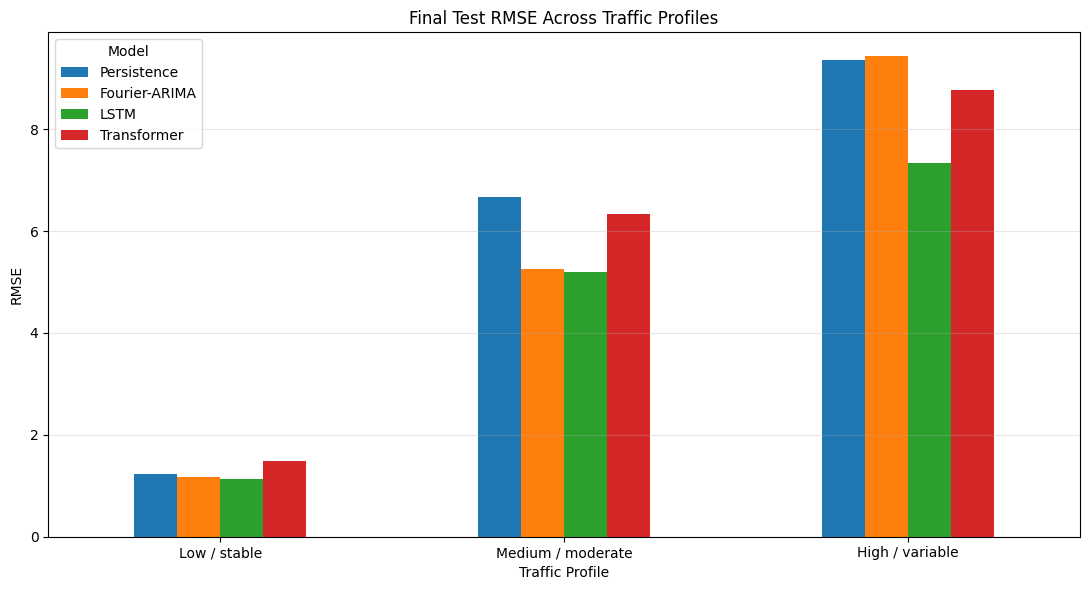

In [ ]:
# ============================================================
# 10.2 FINAL TEST RMSE COMPARISON
# ============================================================

rmse_plot_data = (
    final_test_comparison[
        [
            "Profile",
            "Model",
            "RMSE"
        ]
    ]
    .copy()
)

rmse_pivot = rmse_plot_data.pivot(
    index="Profile",
    columns="Model",
    values="RMSE"
)

# Preserve intended ordering
rmse_pivot = rmse_pivot.loc[
    profile_order_final,
    model_order
]

ax = rmse_pivot.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title(
    "Final Test RMSE Across Traffic Profiles"
)

ax.set_xlabel(
    "Traffic Profile"
)

ax.set_ylabel(
    "RMSE"
)

ax.legend(
    title="Model"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()

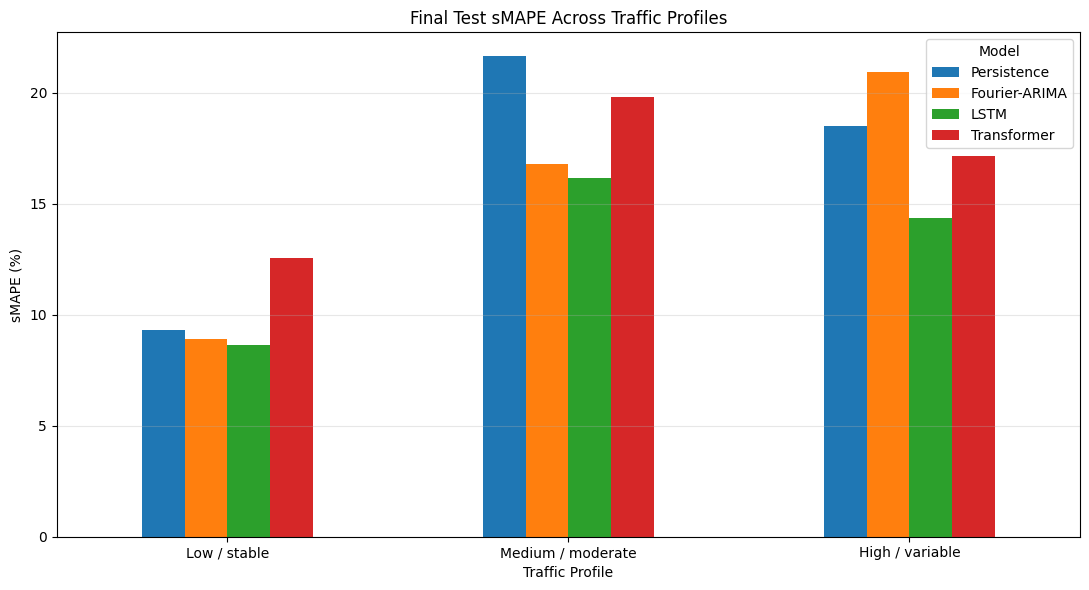

In [ ]:
# ============================================================
# 10.3 FINAL TEST sMAPE COMPARISON
# ============================================================

smape_pivot = (
    final_test_comparison
    .pivot(
        index="Profile",
        columns="Model",
        values="sMAPE (%)"
    )
    .loc[
        profile_order_final,
        model_order
    ]
)

ax = smape_pivot.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title(
    "Final Test sMAPE Across Traffic Profiles"
)

ax.set_xlabel(
    "Traffic Profile"
)

ax.set_ylabel(
    "sMAPE (%)"
)

ax.legend(
    title="Model"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()

### 9.1 Final Test Performance Across Traffic Profiles

The held-out test results demonstrate that forecasting performance varies substantially across both model classes and geographical traffic profiles.

The LSTM achieved the lowest RMSE, MAE, and sMAPE in all three geographical areas. Relative to the persistence baseline, its RMSE decreased by approximately 9.1% in the low/stable area, 22.2% in the medium/moderate area, and 21.6% in the high/variable area. The improvement was therefore considerably larger in the more variable traffic series than in the relatively stable low-traffic series.

The Fourier-ARIMA model showed stronger dependence on traffic characteristics. It reduced RMSE by approximately 6.1% in the low/stable area and 21.3% in the medium/moderate area, but slightly increased RMSE by approximately 0.7% in the high/variable area. Its MAE and sMAPE also deteriorated relative to persistence in the high/variable area. This indicates that the combination of deterministic daily Fourier seasonality and a linear ARIMA error structure was effective for some traffic profiles but less able to accommodate the behaviour of the most variable series.

The Transformer produced mixed results. In the low/stable area, its RMSE was approximately 19.4% higher than persistence, whereas it reduced RMSE by approximately 5.0% in the medium/moderate area and 6.3% in the high/variable area. Despite these improvements, it did not outperform the selected LSTM on any of the three held-out test series.

Overall, the results indicate that increased model complexity does not automatically produce better short-horizon forecasts. For the present one-step-ahead task, the LSTM provided the most consistent reduction in forecasting error across the three contrasting geographical traffic profiles, while the effectiveness of Fourier-ARIMA and the Transformer was more dependent on the characteristics of the individual series.

In [ ]:
# ============================================================
# 10.4 CONSOLIDATE FINAL TEST PREDICTIONS
# ============================================================

final_predictions = {}

fourier_prediction_map = {
    result["Square"]: result
    for result in final_fourier_results
}

for profile, area_id in profile_area_map.items():

    persistence_actual = (
        final_persistence_predictions[area_id]["actual"]
    )
    persistence_pred = (
        final_persistence_predictions[area_id]["predicted"]
    )

    fourier_actual = (
        fourier_prediction_map[area_id]["Actual"]
    )
    fourier_pred = (
        fourier_prediction_map[area_id]["Predicted"]
    )

    lstm_actual = (
        final_lstm_predictions[area_id]["actual"]
    )
    lstm_pred = (
        final_lstm_predictions[area_id]["predicted"]
    )

    transformer_actual = (
        final_transformer_predictions[area_id]["actual"]
    )
    transformer_pred = (
        final_transformer_predictions[area_id]["predicted"]
    )

    # Confirm every model was evaluated against
    # exactly the same test targets.
    assert np.allclose(persistence_actual, fourier_actual)
    assert np.allclose(persistence_actual, lstm_actual)
    assert np.allclose(persistence_actual, transformer_actual)

    final_predictions[area_id] = {
        "Profile": profile,
        "Actual": persistence_actual,
        "Persistence": persistence_pred,
        "Fourier-ARIMA": fourier_pred,
        "LSTM": lstm_pred,
        "Transformer": transformer_pred
    }

print("Prediction sets consolidated successfully.")

for area_id, values in final_predictions.items():
    print(
        area_id,
        values["Profile"],
        len(values["Actual"])
    )

Prediction sets consolidated successfully.
2404 Low / stable 1340
6433 Medium / moderate 1340
5243 High / variable 1340


In [ ]:
# ============================================================
# 11.1 FINAL TEST RESIDUAL ANALYSIS
# ============================================================

residual_results = []

models = [
    "Persistence",
    "Fourier-ARIMA",
    "LSTM",
    "Transformer"
]

for area_id, data in final_predictions.items():

    profile = data["Profile"]
    actual = np.asarray(
        data["Actual"],
        dtype=np.float64
    )

    for model_name in models:

        predicted = np.asarray(
            data[model_name],
            dtype=np.float64
        )

        residuals = actual - predicted

        residual_results.append({
            "Profile": profile,
            "Square": area_id,
            "Model": model_name,

            # Directional bias
            "Mean Residual": np.mean(residuals),

            # Typical absolute error
            "Median Absolute Error":
                np.median(np.abs(residuals)),

            # Spread of errors
            "Residual Std":
                np.std(residuals),

            # Extreme failure
            "Max Absolute Error":
                np.max(np.abs(residuals)),

            # Direction of errors
            "Underprediction (%)":
                100 * np.mean(residuals > 0),

            "Overprediction (%)":
                100 * np.mean(residuals < 0)
        })


residual_analysis = pd.DataFrame(
    residual_results
)

residual_analysis["Profile"] = pd.Categorical(
    residual_analysis["Profile"],
    categories=profile_order_final,
    ordered=True
)

residual_analysis["Model"] = pd.Categorical(
    residual_analysis["Model"],
    categories=model_order,
    ordered=True
)

residual_analysis = (
    residual_analysis
    .sort_values(["Profile", "Model"])
    .reset_index(drop=True)
)

print("FINAL TEST RESIDUAL ANALYSIS")
print("=" * 100)

display(
    residual_analysis.round(4)
)

FINAL TEST RESIDUAL ANALYSIS


,Profile,Square,Model,Mean Residual,Median Absolute Error,Residual Std,Max Absolute Error,Underprediction (%),Overprediction (%)
0,Low / stable,2404,Persistence,-0.0019,0.7576,1.2387,6.3140,49.3284,50.6716
1,Low / stable,2404,Fourier-ARIMA,-0.0113,0.7384,1.1630,4.7971,45.9701,54.0299
2,Low / stable,2404,LSTM,-0.2121,0.7053,1.1063,6.2165,38.1343,61.8657
3,Low / stable,2404,Transformer,-0.6133,1.0697,1.3462,5.7019,29.2537,70.7463
4,Medium / moderate,6433,Persistence,-0.0227,4.5031,6.6660,30.5682,50.7463,49.2537
5,Medium / moderate,6433,Fourier-ARIMA,-0.0215,3.4816,5.2464,23.4210,46.4925,53.5075
6,Medium / moderate,6433,LSTM,-0.3934,3.3293,5.1719,24.7447,45.0746,54.9254
7,Medium / moderate,6433,Transformer,-0.7767,4.1086,6.2881,28.8508,43.7313,56.2687
8,High / variable,5243,Persistence,-0.0298,5.9295,9.3655,42.0074,50.2985,49.7015
9,High / variable,5243,Fourier-ARIMA,-0.0619,6.7761,9.4288,32.9988,48.2090,51.7910


In [ ]:
# ============================================================
# 11.2 HIGH-TRAFFIC / PEAK ERROR ANALYSIS
# ============================================================

peak_results = []

for area_id, data in final_predictions.items():

    profile = data["Profile"]

    actual = np.asarray(
        data["Actual"],
        dtype=np.float64
    )

    # Top 10% of actual TEST traffic
    peak_threshold = np.quantile(
        actual,
        0.90
    )

    peak_mask = actual >= peak_threshold

    print(
        f"{profile} — Square {area_id}: "
        f"peak threshold = {peak_threshold:.4f}, "
        f"peak observations = {peak_mask.sum()}"
    )

    for model_name in models:

        predicted = np.asarray(
            data[model_name],
            dtype=np.float64
        )

        # Overall test errors
        overall_metrics = evaluate_forecast(
            actual,
            predicted
        )

        # Peak-only errors
        peak_metrics = evaluate_forecast(
            actual[peak_mask],
            predicted[peak_mask]
        )

        peak_residuals = (
            actual[peak_mask]
            - predicted[peak_mask]
        )

        peak_results.append({
            "Profile": profile,
            "Square": area_id,
            "Model": model_name,
            "Peak Threshold": peak_threshold,
            "Peak N": peak_mask.sum(),
            "Overall RMSE":
                overall_metrics["RMSE"],
            "Peak RMSE":
                peak_metrics["RMSE"],
            "Peak MAE":
                peak_metrics["MAE"],
            "Peak sMAPE (%)":
                peak_metrics["sMAPE (%)"],
            "Peak Mean Residual":
                np.mean(peak_residuals)
        })


peak_analysis = pd.DataFrame(
    peak_results
)

peak_analysis["Profile"] = pd.Categorical(
    peak_analysis["Profile"],
    categories=profile_order_final,
    ordered=True
)

peak_analysis["Model"] = pd.Categorical(
    peak_analysis["Model"],
    categories=model_order,
    ordered=True
)

peak_analysis = (
    peak_analysis
    .sort_values(["Profile", "Model"])
    .reset_index(drop=True)
)

print("\nHIGH-TRAFFIC FORECAST PERFORMANCE")
print("=" * 100)

display(
    peak_analysis.round(4)
)

Low / stable — Square 2404: peak threshold = 14.6210, peak observations = 134
Medium / moderate — Square 6433: peak threshold = 38.2597, peak observations = 134
High / variable — Square 5243: peak threshold = 57.5087, peak observations = 134

HIGH-TRAFFIC FORECAST PERFORMANCE


,Profile,Square,Model,Peak Threshold,Peak N,Overall RMSE,Peak RMSE,Peak MAE,Peak sMAPE (%),Peak Mean Residual
0,Low / stable,2404,Persistence,14.6210,134,1.2387,1.9108,1.5414,9.6035,0.5518
1,Low / stable,2404,Fourier-ARIMA,14.6210,134,1.1630,1.8291,1.4669,9.2485,0.6972
2,Low / stable,2404,LSTM,14.6210,134,1.1264,1.7565,1.4324,9.0086,0.8034
3,Low / stable,2404,Transformer,14.6210,134,1.4794,1.9507,1.5947,9.9962,0.9050
4,Medium / moderate,6433,Persistence,38.2597,134,6.6660,9.2217,7.4606,20.0501,6.0602
5,Medium / moderate,6433,Fourier-ARIMA,38.2597,134,5.2465,8.6261,7.2191,19.0797,7.0433
6,Medium / moderate,6433,LSTM,38.2597,134,5.1868,8.0800,6.6181,17.3552,6.3606
7,Medium / moderate,6433,Transformer,38.2597,134,6.3359,8.6374,6.7691,18.1506,6.6292
8,High / variable,5243,Persistence,57.5087,134,9.3655,12.9919,10.4914,18.6283,8.7544
9,High / variable,5243,Fourier-ARIMA,57.5087,134,9.4290,11.2432,8.7908,15.4663,7.0366


In [ ]:
# ============================================================
# 11.3 LARGEST FINAL TEST FORECAST ERRORS
# ============================================================

largest_error_rows = []

# Exact timestamps of held-out test observations
test_timestamps = (
    df_selected[
        df_selected["square_id"] == 2404
    ]
    .sort_values("datetime")["datetime"]
    .iloc[VAL_END:]
    .reset_index(drop=True)
)

assert len(test_timestamps) == 1340


for area_id, data in final_predictions.items():

    profile = data["Profile"]

    actual = np.asarray(
        data["Actual"],
        dtype=np.float64
    )

    for model_name in models:

        predicted = np.asarray(
            data[model_name],
            dtype=np.float64
        )

        errors = actual - predicted
        absolute_errors = np.abs(errors)

        # Five largest failures for this model/area
        largest_indices = np.argsort(
            absolute_errors
        )[-5:][::-1]

        for rank, idx in enumerate(
            largest_indices,
            start=1
        ):

            largest_error_rows.append({
                "Profile": profile,
                "Square": area_id,
                "Model": model_name,
                "Rank": rank,
                "Timestamp":
                    test_timestamps.iloc[idx],
                "Actual": actual[idx],
                "Predicted": predicted[idx],
                "Residual": errors[idx],
                "Absolute Error":
                    absolute_errors[idx]
            })


largest_errors = pd.DataFrame(
    largest_error_rows
)

largest_errors["Profile"] = pd.Categorical(
    largest_errors["Profile"],
    categories=profile_order_final,
    ordered=True
)

largest_errors["Model"] = pd.Categorical(
    largest_errors["Model"],
    categories=model_order,
    ordered=True
)

largest_errors = (
    largest_errors
    .sort_values(
        ["Profile", "Model", "Rank"]
    )
    .reset_index(drop=True)
)


print("TOP 5 LARGEST ERRORS PER MODEL AND AREA")
print("=" * 110)

display(
    largest_errors.round(4)
)

TOP 5 LARGEST ERRORS PER MODEL AND AREA


,Profile,Square,Model,Rank,Timestamp,Actual,Predicted,Residual,Absolute Error
0,Low / stable,2404,Persistence,1,2013-12-25 18:40:00+01:00,21.7417,15.4277,6.3140,6.3140
1,Low / stable,2404,Persistence,2,2013-12-29 13:00:00+01:00,7.7795,13.1920,-5.4125,5.4125
2,Low / stable,2404,Persistence,3,2013-12-25 19:20:00+01:00,14.8785,20.1914,-5.3129,5.3129
3,Low / stable,2404,Persistence,4,2013-12-26 21:30:00+01:00,11.4809,15.8113,-4.3304,4.3304
4,Low / stable,2404,Persistence,5,2013-12-26 17:40:00+01:00,16.6712,12.3803,4.2909,4.2909
5,Low / stable,2404,Fourier-ARIMA,1,2013-12-25 19:20:00+01:00,14.8785,19.6756,-4.7971,4.7971
6,Low / stable,2404,Fourier-ARIMA,2,2013-12-25 18:40:00+01:00,21.7417,17.0011,4.7406,4.7406
7,Low / stable,2404,Fourier-ARIMA,3,2013-12-27 22:40:00+01:00,16.2905,11.7840,4.5065,4.5065
8,Low / stable,2404,Fourier-ARIMA,4,2013-12-25 14:10:00+01:00,21.2146,16.7388,4.4758,4.4758
9,Low / stable,2404,Fourier-ARIMA,5,2013-12-29 13:00:00+01:00,7.7795,12.0455,-4.2660,4.2660


In [ ]:
# ============================================================
# 11.4 SINGLE WORST FAILURE PER MODEL AND AREA
# ============================================================

worst_failures = (
    largest_errors[
        largest_errors["Rank"] == 1
    ]
    .copy()
    .reset_index(drop=True)
)

print("WORST FINAL TEST FAILURE PER MODEL AND AREA")
print("=" * 110)

display(
    worst_failures[
        [
            "Profile",
            "Square",
            "Model",
            "Timestamp",
            "Actual",
            "Predicted",
            "Residual",
            "Absolute Error"
        ]
    ].round(4)
)

WORST FINAL TEST FAILURE PER MODEL AND AREA


,Profile,Square,Model,Timestamp,Actual,Predicted,Residual,Absolute Error
0,Low / stable,2404,Persistence,2013-12-25 18:40:00+01:00,21.7417,15.4277,6.3140,6.3140
1,Low / stable,2404,Fourier-ARIMA,2013-12-25 19:20:00+01:00,14.8785,19.6756,-4.7971,4.7971
2,Low / stable,2404,LSTM,2013-12-25 18:40:00+01:00,21.7417,15.5252,6.2165,6.2165
3,Low / stable,2404,Transformer,2013-12-25 18:40:00+01:00,21.7417,16.0399,5.7019,5.7019
4,Medium / moderate,6433,Persistence,2013-12-27 11:10:00+01:00,57.4217,26.8534,30.5682,30.5682
5,Medium / moderate,6433,Fourier-ARIMA,2013-12-27 08:10:00+01:00,45.8372,22.4162,23.4210,23.4210
6,Medium / moderate,6433,LSTM,2013-12-26 06:10:00+01:00,39.7403,14.9957,24.7447,24.7447
7,Medium / moderate,6433,Transformer,2013-12-27 11:10:00+01:00,57.4217,28.5709,28.8508,28.8508
8,High / variable,5243,Persistence,2013-12-28 12:00:00+01:00,78.2740,36.2666,42.0074,42.0074
9,High / variable,5243,Fourier-ARIMA,2014-01-01 00:30:00+01:00,65.7826,32.7837,32.9988,32.9988


## 10. Residual, Peak-Traffic, and Failure Analysis

The aggregate test metrics conceal systematic differences between ordinary and high-traffic periods. Across the three areas, persistence produced mean residuals close to zero, while the LSTM and Transformer showed a modest negative overall mean residual, indicating a tendency toward overprediction across the complete test period.

However, this pattern reversed during high-traffic conditions. When the highest 10% of actual test observations were analysed separately, all models had positive mean residuals across all three areas, indicating systematic underprediction of peak traffic. This effect was particularly pronounced in the medium/moderate and high/variable areas.

For Square 5243, for example, the LSTM achieved the lowest overall test RMSE (7.3438), but its peak-period RMSE increased to 11.3577 and its peak mean residual was 9.2276. Thus, although the LSTM provided the strongest overall performance, it still tended to smooth or underestimate unusually high traffic observations.

The peak analysis also shows that aggregate model rankings do not necessarily hold under every traffic condition. In the high/variable area, Fourier-ARIMA had a worse overall RMSE than the LSTM (9.4290 versus 7.3438), yet its RMSE on the highest-traffic observations was slightly lower (11.2432 versus 11.3577). This suggests that different model structures exhibit different failure modes and reinforces the importance of evaluating forecasting models beyond a single aggregate error measure.

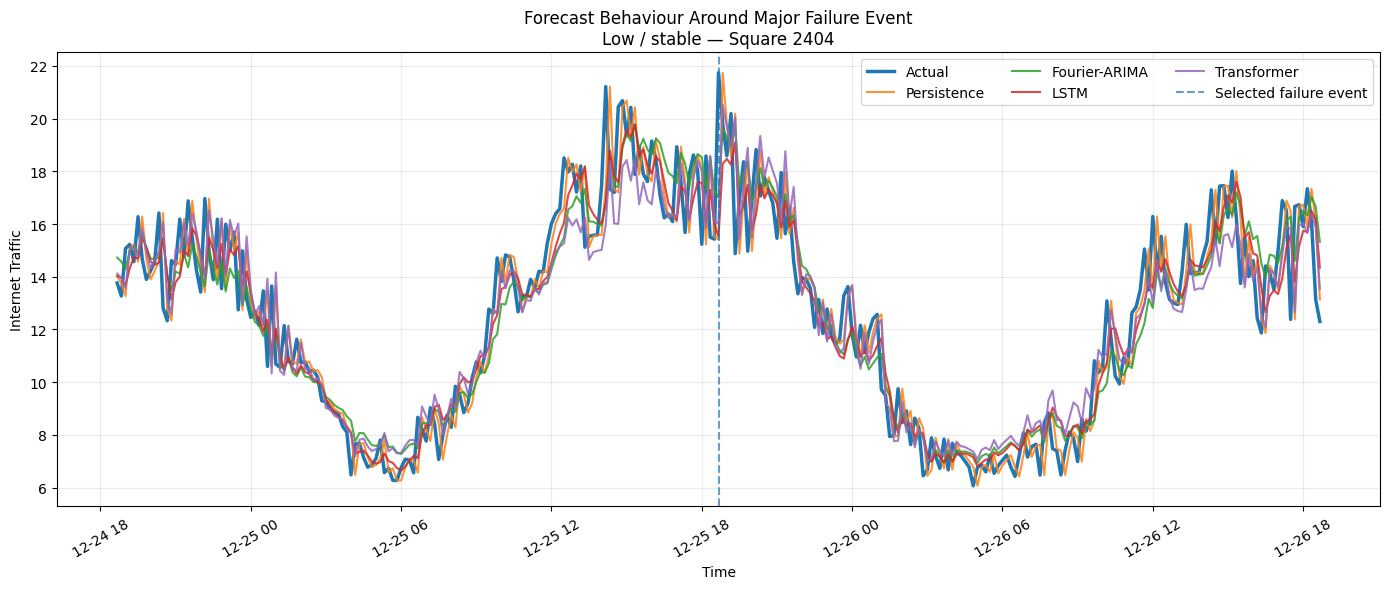

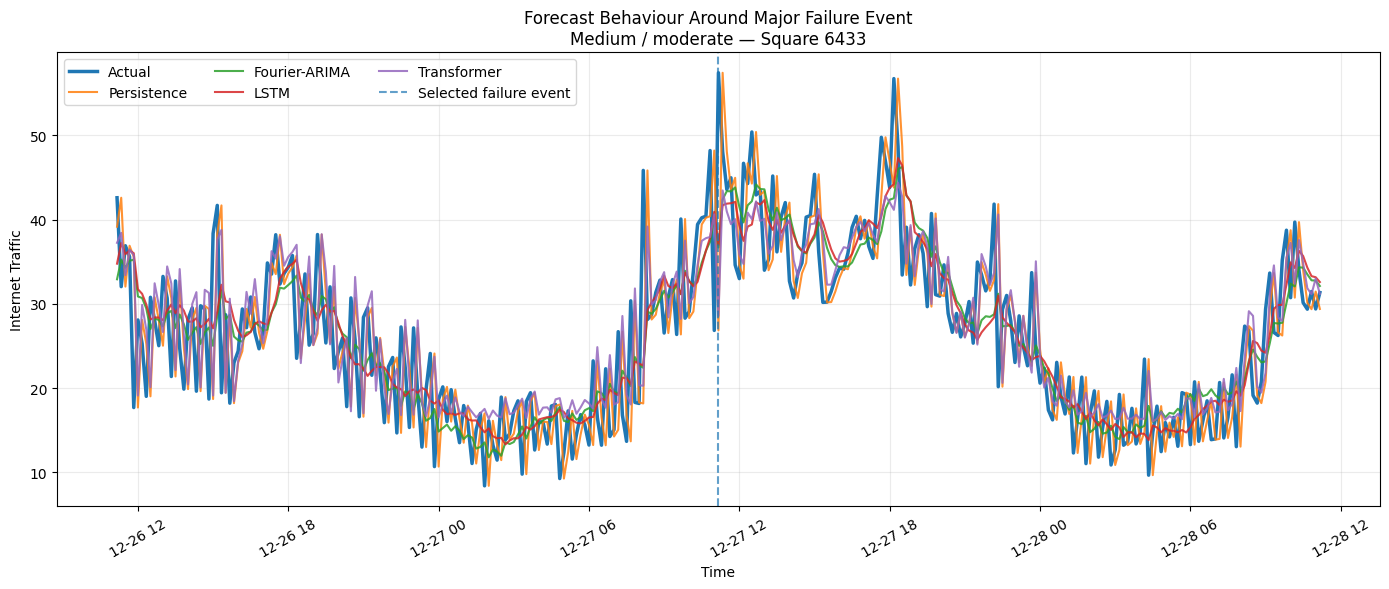

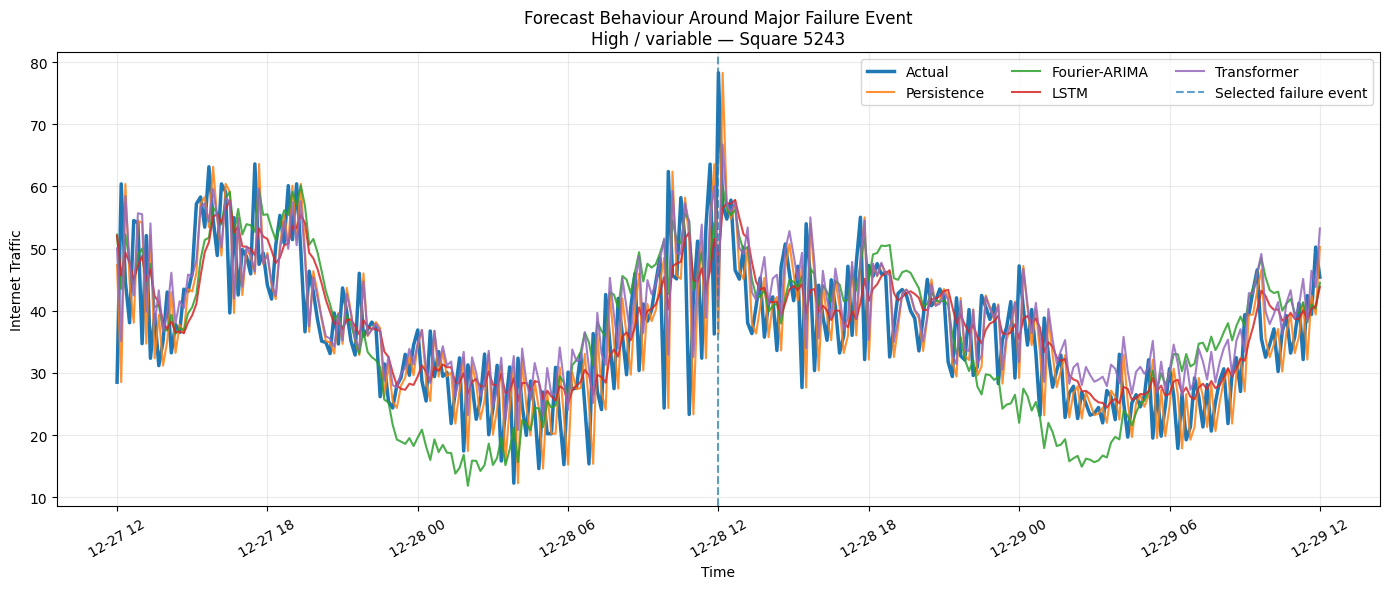

In [ ]:
# ============================================================
# 11.5 ACTUAL VS PREDICTED AROUND MAJOR FAILURE EVENTS
# ============================================================

failure_events = {
    2404: pd.Timestamp(
        "2013-12-25 18:40:00",
        tz="Europe/Rome"
    ),
    6433: pd.Timestamp(
        "2013-12-27 11:10:00",
        tz="Europe/Rome"
    ),
    5243: pd.Timestamp(
        "2013-12-28 12:00:00",
        tz="Europe/Rome"
    )
}

test_timestamps_array = pd.DatetimeIndex(
    test_timestamps
)

# 24 hours = 144 ten-minute observations
WINDOW = 144

for area_id, event_time in failure_events.items():

    data = final_predictions[area_id]
    profile = data["Profile"]

    # Exact position of failure event
    event_idx = test_timestamps_array.get_loc(
        event_time
    )

    start_idx = max(
        0,
        event_idx - WINDOW
    )

    end_idx = min(
        len(test_timestamps_array),
        event_idx + WINDOW + 1
    )

    times = test_timestamps_array[
        start_idx:end_idx
    ]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    plt.figure(
        figsize=(14, 6)
    )

    plt.plot(
        times,
        data["Actual"][start_idx:end_idx],
        label="Actual",
        linewidth=2.5
    )

    for model_name in models:

        plt.plot(
            times,
            data[model_name][start_idx:end_idx],
            label=model_name,
            alpha=0.85
        )

    # Mark major failure timestamp
    plt.axvline(
        event_time,
        linestyle="--",
        alpha=0.7,
        label="Selected failure event"
    )

    plt.title(
        f"Forecast Behaviour Around Major Failure Event\n"
        f"{profile} — Square {area_id}"
    )

    plt.xlabel(
        "Time"
    )

    plt.ylabel(
        "Internet Traffic"
    )

    plt.legend(
        ncol=3
    )

    plt.grid(
        alpha=0.25
    )

    plt.xticks(
        rotation=30
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 11.6 PERFORMANCE DURING ABRUPT TRAFFIC CHANGES
# ============================================================

abrupt_change_results = []

for area_id, data in final_predictions.items():

    profile = data["Profile"]

    actual = np.asarray(
        data["Actual"],
        dtype=np.float64
    )

    # Absolute 10-minute change
    absolute_change = np.abs(
        np.diff(
            actual,
            prepend=actual[0]
        )
    )

    # Top 10% largest changes
    change_threshold = np.quantile(
        absolute_change,
        0.90
    )

    abrupt_mask = (
        absolute_change >= change_threshold
    )

    print(
        f"{profile} — Square {area_id}: "
        f"change threshold = {change_threshold:.4f}, "
        f"observations = {abrupt_mask.sum()}"
    )

    for model_name in models:

        predicted = np.asarray(
            data[model_name],
            dtype=np.float64
        )

        abrupt_metrics = evaluate_forecast(
            actual[abrupt_mask],
            predicted[abrupt_mask]
        )

        residuals = (
            actual[abrupt_mask]
            - predicted[abrupt_mask]
        )

        abrupt_change_results.append({
            "Profile": profile,
            "Square": area_id,
            "Model": model_name,
            "Change Threshold":
                change_threshold,
            "N": abrupt_mask.sum(),
            "Abrupt MAE":
                abrupt_metrics["MAE"],
            "Abrupt RMSE":
                abrupt_metrics["RMSE"],
            "Abrupt sMAPE (%)":
                abrupt_metrics["sMAPE (%)"],
            "Mean Residual":
                np.mean(residuals)
        })


abrupt_change_analysis = pd.DataFrame(
    abrupt_change_results
)

abrupt_change_analysis["Profile"] = pd.Categorical(
    abrupt_change_analysis["Profile"],
    categories=profile_order_final,
    ordered=True
)

abrupt_change_analysis["Model"] = pd.Categorical(
    abrupt_change_analysis["Model"],
    categories=model_order,
    ordered=True
)

abrupt_change_analysis = (
    abrupt_change_analysis
    .sort_values(
        ["Profile", "Model"]
    )
    .reset_index(drop=True)
)


print(
    "\nPERFORMANCE DURING ABRUPT TRAFFIC CHANGES"
)

print("=" * 100)

display(
    abrupt_change_analysis.round(4)
)

Low / stable — Square 2404: change threshold = 2.0046, observations = 134
Medium / moderate — Square 6433: change threshold = 10.4907, observations = 134
High / variable — Square 5243: change threshold = 14.9822, observations = 134

PERFORMANCE DURING ABRUPT TRAFFIC CHANGES


,Profile,Square,Model,Change Threshold,N,Abrupt MAE,Abrupt RMSE,Abrupt sMAPE (%),Mean Residual
0,Low / stable,2404,Persistence,2.0046,134,2.6994,2.7901,21.7834,-0.0807
1,Low / stable,2404,Fourier-ARIMA,2.0046,134,1.9727,2.2198,15.8400,0.1807
2,Low / stable,2404,LSTM,2.0046,134,2.0860,2.2506,16.7376,-0.0347
3,Low / stable,2404,Transformer,2.0046,134,2.4347,2.6209,19.3784,-0.2568
4,Medium / moderate,6433,Persistence,10.4907,134,13.8514,14.2922,48.1635,-0.8569
5,Medium / moderate,6433,Fourier-ARIMA,10.4907,134,8.6702,9.7174,30.7657,0.8025
6,Medium / moderate,6433,LSTM,10.4907,134,8.5844,9.7061,30.0471,0.2424
7,Medium / moderate,6433,Transformer,10.4907,134,12.8592,13.3552,45.0275,-0.6249
8,High / variable,5243,Persistence,14.9822,134,19.8120,20.3075,44.0219,-0.3111
9,High / variable,5243,Fourier-ARIMA,14.9822,134,13.2482,14.9704,29.2746,-0.2613


### 10.1 Failure Analysis and Critical Reflection

Analysis of the largest forecast errors showed that many failures were shared across multiple models, suggesting that they were associated with difficult characteristics of the underlying traffic series rather than isolated failures of a particular architecture. For example, Square 5243 experienced a sharp increase to 78.27 on 28 December at 12:00. Persistence predicted 36.27, Fourier-ARIMA predicted 45.84, the LSTM predicted 48.01, and the Transformer predicted 41.92. All four approaches therefore substantially underestimated the same abrupt traffic spike.

The surrounding forecast window shows that the difficulty was not limited to high values. Rapid decreases and subsequent rebounds were also difficult to track. The models generally followed the broader temporal trajectory but produced smoother forecasts than the observed series during sudden short-term fluctuations.

This behaviour was quantified by separately evaluating the 10% of test observations associated with the largest absolute 10-minute traffic changes. Error increased substantially for every model. In the high/variable area, for example, the LSTM's RMSE increased from 7.34 over the complete test period to 13.58 during abrupt changes. Persistence deteriorated more severely, from 9.37 to 20.31. Fourier-ARIMA and the Transformer reached abrupt-change RMSE values of 14.97 and 17.92 respectively.

The relative performance of the models also depended on the traffic profile. In the low/stable area, Fourier-ARIMA achieved a slightly lower abrupt-change RMSE than the LSTM (2.22 versus 2.25), even though the LSTM had the lowest overall test RMSE. Their performance during abrupt changes was almost identical in the medium/moderate area (9.72 versus 9.71). In contrast, the LSTM had a clearer advantage in the high/variable area, with an abrupt-change RMSE of 13.58 compared with 14.97 for Fourier-ARIMA.

Peak-traffic analysis revealed a related failure mode. Although the learned models showed modest overprediction tendencies across the complete test set, all models had positive mean residuals during the highest 10% of traffic observations, indicating systematic underprediction of high-traffic periods. Thus, good average forecasting performance did not eliminate errors during operationally important peaks.

These findings highlight an important limitation of the one-step univariate forecasting setup. The models rely only on historical traffic from the same geographical area and therefore cannot directly anticipate externally driven events or sudden changes that are not sufficiently represented in the preceding sequence. Calendar variables, event information, neighbouring-cell traffic, weather, or other contextual variables could potentially help explain such changes, but their usefulness would need to be evaluated empirically in future work.

The results also demonstrate why aggregate metrics alone are insufficient for model evaluation. Although the LSTM produced the lowest overall MAE, RMSE, and sMAPE in all three areas, it was not the lowest-error model under every traffic condition. Evaluating peak periods, abrupt changes, residual bias, and individual failure cases provides a more complete account of model behaviour.

In [ ]:
# ============================================================
# VALIDATION VS TEST GENERALIZATION
# ============================================================

generalization_results = pd.DataFrame([

    # Low / stable
    {
        "Profile": "Low / stable",
        "Model": "LSTM",
        "Validation RMSE": 1.3177,
        "Test RMSE": 1.1264
    },

    {
        "Profile": "Low / stable",
        "Model": "Transformer",
        "Validation RMSE": 1.4554,
        "Test RMSE": 1.4794
    },

    # Medium
    {
        "Profile": "Medium / moderate",
        "Model": "LSTM",
        "Validation RMSE": 6.3334,
        "Test RMSE": 5.1868
    },

    {
        "Profile": "Medium / moderate",
        "Model": "Transformer",
        "Validation RMSE": 6.3334,
        "Test RMSE": 6.3359
    },

    # High
    {
        "Profile": "High / variable",
        "Model": "LSTM",
        "Validation RMSE": 10.4395,
        "Test RMSE": 7.3438
    },

    {
        "Profile": "High / variable",
        "Model": "Transformer",
        "Validation RMSE": 10.4395,
        "Test RMSE": 8.7723
    }

])

generalization_results["Difference"] = (
    generalization_results["Test RMSE"]
    - generalization_results["Validation RMSE"]
)

display(
    generalization_results.round(4)
)

,Profile,Model,Validation RMSE,Test RMSE,Difference
0,Low / stable,LSTM,1.3177,1.1264,-0.1913
1,Low / stable,Transformer,1.4554,1.4794,0.0240
2,Medium / moderate,LSTM,6.3334,5.1868,-1.1466
3,Medium / moderate,Transformer,6.3334,6.3359,0.0025
4,High / variable,LSTM,10.4395,7.3438,-3.0957
5,High / variable,Transformer,10.4395,8.7723,-1.6672


## 11. Validation-to-Test Generalization

The following comparison first reports the change in absolute RMSE between validation and test periods. These values should not be interpreted as a pure measure of generalization because the final models were refitted on the combined training and validation data before test evaluation, and the temporal periods themselves can differ in forecasting difficulty. The persistence baseline is therefore included as a reference, followed by a comparison of each model's relative RMSE improvement over persistence.

In [ ]:
# ============================================================
# 12.1 VALIDATION VS TEST GENERALIZATION
# ============================================================

generalization_results = pd.DataFrame([
    # Persistence
    ["Low / stable",      "Persistence",   1.4875, 1.2387],
    ["Medium / moderate", "Persistence",   7.0829, 6.6660],
    ["High / variable",   "Persistence",  11.1448, 9.3655],

    # Fourier-ARIMA
    ["Low / stable",      "Fourier-ARIMA", 9.5456, 1.1630],
    ["Medium / moderate", "Fourier-ARIMA", 5.6195, 5.2465],
    ["High / variable",   "Fourier-ARIMA",10.9141, 9.4290],

    # LSTM
    ["Low / stable",      "LSTM",           1.3177, 1.1264],
    ["Medium / moderate", "LSTM",           5.4583, 5.1868],
    ["High / variable",   "LSTM",           9.1777, 7.3438],

    # Transformer
    ["Low / stable",      "Transformer",    1.4554, 1.4794],
    ["Medium / moderate", "Transformer",    6.3334, 6.3359],
    ["High / variable",   "Transformer",   10.4395, 8.7723],
], columns=[
    "Profile",
    "Model",
    "Validation RMSE",
    "Test RMSE"
])

generalization_results["RMSE Difference"] = (
    generalization_results["Test RMSE"]
    - generalization_results["Validation RMSE"]
)

generalization_results["RMSE Change (%)"] = (
    100
    * generalization_results["RMSE Difference"]
    / generalization_results["Validation RMSE"]
)

display(generalization_results.round(4))

,Profile,Model,Validation RMSE,Test RMSE,RMSE Difference,RMSE Change (%)
0,Low / stable,Persistence,1.4875,1.2387,-0.2488,-16.7261
1,Medium / moderate,Persistence,7.0829,6.6660,-0.4169,-5.8860
2,High / variable,Persistence,11.1448,9.3655,-1.7793,-15.9653
3,Low / stable,Fourier-ARIMA,9.5456,1.1630,-8.3826,-87.8164
4,Medium / moderate,Fourier-ARIMA,5.6195,5.2465,-0.3730,-6.6376
5,High / variable,Fourier-ARIMA,10.9141,9.4290,-1.4851,-13.6072
6,Low / stable,LSTM,1.3177,1.1264,-0.1913,-14.5177
7,Medium / moderate,LSTM,5.4583,5.1868,-0.2715,-4.9741
8,High / variable,LSTM,9.1777,7.3438,-1.8339,-19.9821
9,Low / stable,Transformer,1.4554,1.4794,0.0240,1.6490


In [ ]:
# ============================================================
# 12.2 VALIDATION VS TEST — IMPROVEMENT OVER PERSISTENCE
# ============================================================

validation_rmse = {
    2404: {
        "Persistence": 1.4875,
        "Fourier-ARIMA": 9.5456,
        "LSTM": 1.3177,
        "Transformer": 1.4554
    },
    6433: {
        "Persistence": 7.0829,
        "Fourier-ARIMA": 5.6195,
        "LSTM": 5.4583,
        "Transformer": 6.3334
    },
    5243: {
        "Persistence": 11.1448,
        "Fourier-ARIMA": 10.9141,
        "LSTM": 9.1777,
        "Transformer": 10.4395
    }
}

test_rmse = {
    2404: {
        "Persistence": 1.2387,
        "Fourier-ARIMA": 1.1630,
        "LSTM": 1.1264,
        "Transformer": 1.4794
    },
    6433: {
        "Persistence": 6.6660,
        "Fourier-ARIMA": 5.2465,
        "LSTM": 5.1868,
        "Transformer": 6.3359
    },
    5243: {
        "Persistence": 9.3655,
        "Fourier-ARIMA": 9.4290,
        "LSTM": 7.3438,
        "Transformer": 8.7723
    }
}

generalization_relative = []

for profile, area_id in profile_area_map.items():

    val_baseline = validation_rmse[
        area_id
    ]["Persistence"]

    test_baseline = test_rmse[
        area_id
    ]["Persistence"]

    for model_name in [
        "Fourier-ARIMA",
        "LSTM",
        "Transformer"
    ]:

        val_model = validation_rmse[
            area_id
        ][model_name]

        test_model = test_rmse[
            area_id
        ][model_name]

        val_improvement = (
            100
            * (val_baseline - val_model)
            / val_baseline
        )

        test_improvement = (
            100
            * (test_baseline - test_model)
            / test_baseline
        )

        generalization_relative.append({
            "Profile": profile,
            "Square": area_id,
            "Model": model_name,
            "Validation Improvement vs Persistence (%)":
                val_improvement,
            "Test Improvement vs Persistence (%)":
                test_improvement,
            "Change in Relative Improvement (pp)":
                test_improvement - val_improvement
        })


generalization_relative = pd.DataFrame(
    generalization_relative
)

display(
    generalization_relative.round(4)
)

,Profile,Square,Model,Validation Improvement vs Persistence (%),Test Improvement vs Persistence (%),Change in Relative Improvement (pp)
0,Low / stable,2404,Fourier-ARIMA,-541.7210,6.1112,547.8323
1,Low / stable,2404,LSTM,11.4151,9.0660,-2.3492
2,Low / stable,2404,Transformer,2.1580,-19.4317,-21.5896
3,Medium / moderate,6433,Fourier-ARIMA,20.6610,21.2946,0.6336
4,Medium / moderate,6433,LSTM,22.9369,22.1902,-0.7467
5,Medium / moderate,6433,Transformer,10.5818,4.9520,-5.6298
6,High / variable,5243,Fourier-ARIMA,2.0700,-0.6780,-2.7480
7,High / variable,5243,LSTM,17.6504,21.5867,3.9363
8,High / variable,5243,Transformer,6.3285,6.3339,0.0054


### 11.1 Relative Performance Across Validation and Test Periods

Absolute validation and test errors were not interpreted in isolation because the two periods differed in forecasting difficulty. This is evident from the persistence baseline itself: its RMSE decreased from validation to test in all three areas. In addition, the final models were refitted using the combined training and validation data before test evaluation. Consequently, relative improvement over persistence provides a more informative indication of whether model behaviour remained consistent across the two temporal periods.

The LSTM showed the most consistent relative performance. In the low/stable area, its RMSE improvement over persistence changed from 11.4% during validation to 9.1% on the held-out test set. In the medium/moderate area, the improvement remained similarly stable at 22.9% during validation and 22.2% during testing. In the high/variable area, the improvement increased from 17.7% to 21.6%. Thus, the LSTM maintained a reduction in RMSE relative to persistence across every area and both evaluation periods.

The Transformer showed less consistent generalization. Its improvement over persistence in the low/stable area changed from a 2.2% reduction in validation RMSE to a 19.4% increase in test RMSE. In the medium/moderate area, its improvement decreased from 10.6% to 5.0%. In contrast, the high/variable area was highly consistent, with improvements of approximately 6.3% in both validation and testing. These results indicate that the selected Transformer configuration was more sensitive to the evaluated traffic profile and temporal period.

Fourier-ARIMA also exhibited strong profile dependence. Its relative improvement remained highly consistent in the medium/moderate area, changing only from 20.7% during validation to 21.3% during testing. In the high/variable area, however, it changed from a small 2.1% improvement to a 0.7% deterioration relative to persistence.

The low/stable Fourier-ARIMA result was an important exception. Its validation RMSE was substantially higher than persistence, whereas after refitting on the complete pre-test development period it achieved a 6.1% improvement over persistence on the test set. Because both the available fitting data and the evaluated temporal period changed between these evaluations, this large difference should not be interpreted as evidence of exceptional generalization. Instead, it demonstrates temporal sensitivity in the statistical model and represents a limitation of drawing conclusions from a single chronological validation and test split.

Overall, the comparison shows that model performance was dependent not only on model architecture but also on geographical traffic characteristics and evaluation period. Among the evaluated configurations, the LSTM exhibited the most stable relative improvement over the persistence benchmark across the three traffic profiles.

## 12. Summary of Key Findings

The study compared persistence, Fourier-seasonal ARIMA, LSTM, and Transformer forecasts across low/stable, medium/moderate, and high/variable traffic profiles.

- The LSTM achieved the lowest held-out test MAE, RMSE, and sMAPE in all three selected areas.
- Relative to persistence, LSTM test RMSE improved by approximately 9.1% in the low/stable area, 22.2% in the medium/moderate area, and 21.6% in the high/variable area.
- Fourier-seasonal ARIMA was competitive in the low/stable and medium/moderate areas but slightly underperformed persistence in the high/variable area.
- Transformer performance was more profile-sensitive: it underperformed persistence in the low/stable test area but improved on persistence in the medium/moderate and high/variable areas.
- Errors increased substantially during abrupt 10-minute traffic changes, and all models tended to underpredict the highest 10% of observed traffic values.
- Condition-specific analysis showed that the model with the lowest overall error was not necessarily the lowest-error model in every operating condition, reinforcing the value of failure analysis beyond aggregate metrics.

## 13. Limitations and Future Work

Several limitations should be considered when interpreting the results.

First, detailed forecasting experiments were conducted on three complete geographical areas selected to represent contrasting traffic profiles. This makes controlled cross-profile analysis computationally feasible, but the results should not be assumed to represent all 10,000 Milan grid cells. In addition, the profile-selection statistics were computed over the complete observation period before the chronological forecasting split. Although test targets were not used for model fitting or hyperparameter selection, a stricter future design would define traffic profiles using training-period statistics only and then evaluate a larger sample of cells.

Second, the forecasting task is univariate: each model uses only historical Internet traffic from the target area. The failure analysis shows that abrupt changes and high-traffic periods remain difficult to predict. Future work could test calendar variables, event information, weather, or neighbouring-cell traffic to determine whether contextual and spatial signals improve forecasts during sudden changes.

Third, the study uses a single chronological training-validation-test split. This preserves temporal ordering, but the large validation-to-test shift observed for Fourier-seasonal ARIMA in the low/stable area demonstrates sensitivity to the fitting and evaluation window. Rolling-origin evaluation across multiple temporal windows would provide stronger evidence about temporal stability.

Fourth, a full seasonal SARIMA model with a 144-step daily period could not be fitted within the available runtime memory at the original 10-minute resolution. The study therefore retained the original forecasting task and represented daily seasonality with Fourier terms combined with low-order ARIMA errors. The final statistical model should consequently be interpreted as Fourier-seasonal ARIMA rather than full SARIMA.

Fifth, computational constraints limited neural-network hyperparameter exploration to controlled sequential experiments rather than an exhaustive search over all combinations. For the high/variable area, the selected LSTM training duration was close to the maximum validation epoch budget. This was retained without post-test retuning to preserve the independence of the held-out test evaluation.

Finally, the study evaluates one-step-ahead forecasting only. Because each forecast can use the most recently observed traffic value, performance at longer recursive or direct multi-step horizons may differ substantially. Future work should therefore extend the comparison to multiple forecasting horizons.

## 14. Conclusion

This study investigated one-step-ahead mobile Internet traffic forecasting at 10-minute resolution across three Milan geographical areas with contrasting traffic characteristics. A persistence baseline, Fourier-seasonal ARIMA model, LSTM, and Transformer were evaluated using a common chronological forecasting protocol and the same held-out test period.

The results demonstrate that forecasting performance varied across geographical traffic profiles. The LSTM produced the lowest MAE, RMSE, and sMAPE among the evaluated approaches in each of the three held-out test areas. Relative to persistence, its RMSE was reduced by approximately 9.1% in the low/stable area, 22.2% in the medium/moderate area, and 21.6% in the high/variable area. Fourier-ARIMA was competitive in the low/stable and medium/moderate areas but slightly underperformed persistence in the high/variable area. The Transformer produced mixed results, underperforming persistence in the low/stable area while providing smaller improvements in the medium/moderate and high/variable areas.

The analysis also showed that aggregate forecasting metrics do not fully describe model behaviour. All models experienced substantially larger errors during abrupt 10-minute traffic changes and tended to underestimate the highest traffic observations. Although the LSTM provided the most consistent overall performance, it did not have the lowest error under every specific traffic condition.

The findings therefore answer the research question by showing that the relative effectiveness of sequential forecasting approaches depends on the characteristics of the geographical traffic series. Within the models and areas evaluated in this study, the LSTM provided the most consistent improvement over a persistence benchmark, while the statistical and attention-based approaches showed greater sensitivity to traffic profile and evaluation period.

Future work should extend the evaluation to more geographical areas, multiple temporal test windows and longer forecasting horizons, and investigate whether spatial and contextual information can improve forecasting during abrupt or unusually high traffic conditions.